# 🏦 Bank Term Deposit — End-to-End Machine Learning Pipeline
### *From Raw Data to Business ROI: A Complete Analytical Walkthrough*

---

**Dataset:** UCI Bank Marketing Dataset — 41,188 client interactions from a Portuguese bank (2008–2010)  
**Task:** Binary classification — predict who will subscribe to a term deposit  
**Business Question:** *How do we increase subscription rates while reducing telemarketing cost?*

---

| Section | Topic |
|---------|-------|
| 1 | Business Context & Cost Model |
| 2 | Setup, Imports & Color System |
| 3 | Load & Preview Data |
| 4 | EDA — Class Imbalance |
| 5 | EDA — Missing Values & Unknowns |
| 6 | EDA — Outlier Detection |
| 7 | EDA — Distributions & Skewness |
| 8 | EDA — Linear vs Non-Linear Relationships |
| 9 | EDA — Classification Summary |
| 10 | Feature Engineering & Preprocessing |
| 11 | Baseline Models (No Tuning) |
| 12 | Classification Metrics: FP, FN Deep-Dive |
| 13 | Cross-Validation |
| 14 | Full Model Comparison |
| 15 | Hyperparameter Tuning (Optuna) |
| 16 | Predict on Test Set — Before vs After Tuning |
| 17 | Recall Analysis |
| 18 | Loss Calculation — Before & After Tuning |
| 19 | Threshold Optimization |
| 20 | Loss — Before / After Tuning / After Threshold |
| 21 | Feature Importance + SHAP |
| 22 | Business ROI — When to Call, When Not to Call |
| 23 | Lead Segmentation: Tri-Path Prospect Routing |
| 24 | Final Conclusion & Executive Summary |

---
> **Note:** `duration` is intentionally excluded from all models. It is a post-call feature — knowing call length before making the call is impossible. Including it would produce unrealistically high accuracy that fails in production.


## Section 1 — Business Context & Cost Model

Before writing a single line of modelling code, every analyst must understand the economics.
If we don't anchor the model to money, we optimise the wrong thing.

**The core problem:** A bank runs telemarketing campaigns to sell term deposits.
Conversion rate is only ~11.7%. That means 88.3% of calls are rejected — burning agent time, budget, and goodwill.

**Two types of error — and they are NOT equal:**

| Error | What happened | Cost |
|-------|--------------|------|
| False Positive (FP) | Called someone who wouldn't subscribe | $5 per wasted call |
| False Negative (FN) | Missed a real subscriber — never called them | $200 lost revenue opportunity |

**Why $200 for a missed subscriber?**
- Average deposit: $10,000
- Bank pays depositor: 2% interest
- Bank lends those funds at: 8.4%
- Net Interest Margin (NIM): 6.4% × $10,000 = $640/year × 2 year term = $1,280 lifetime value
- Conservative FN cost (adjusted for uncertainty/churn): **$200**

**The ratio:** Missing a real subscriber is **40× more expensive** than making one extra call.
This means the model should lean toward high recall — catch almost everyone, even at the cost of some false alarms.


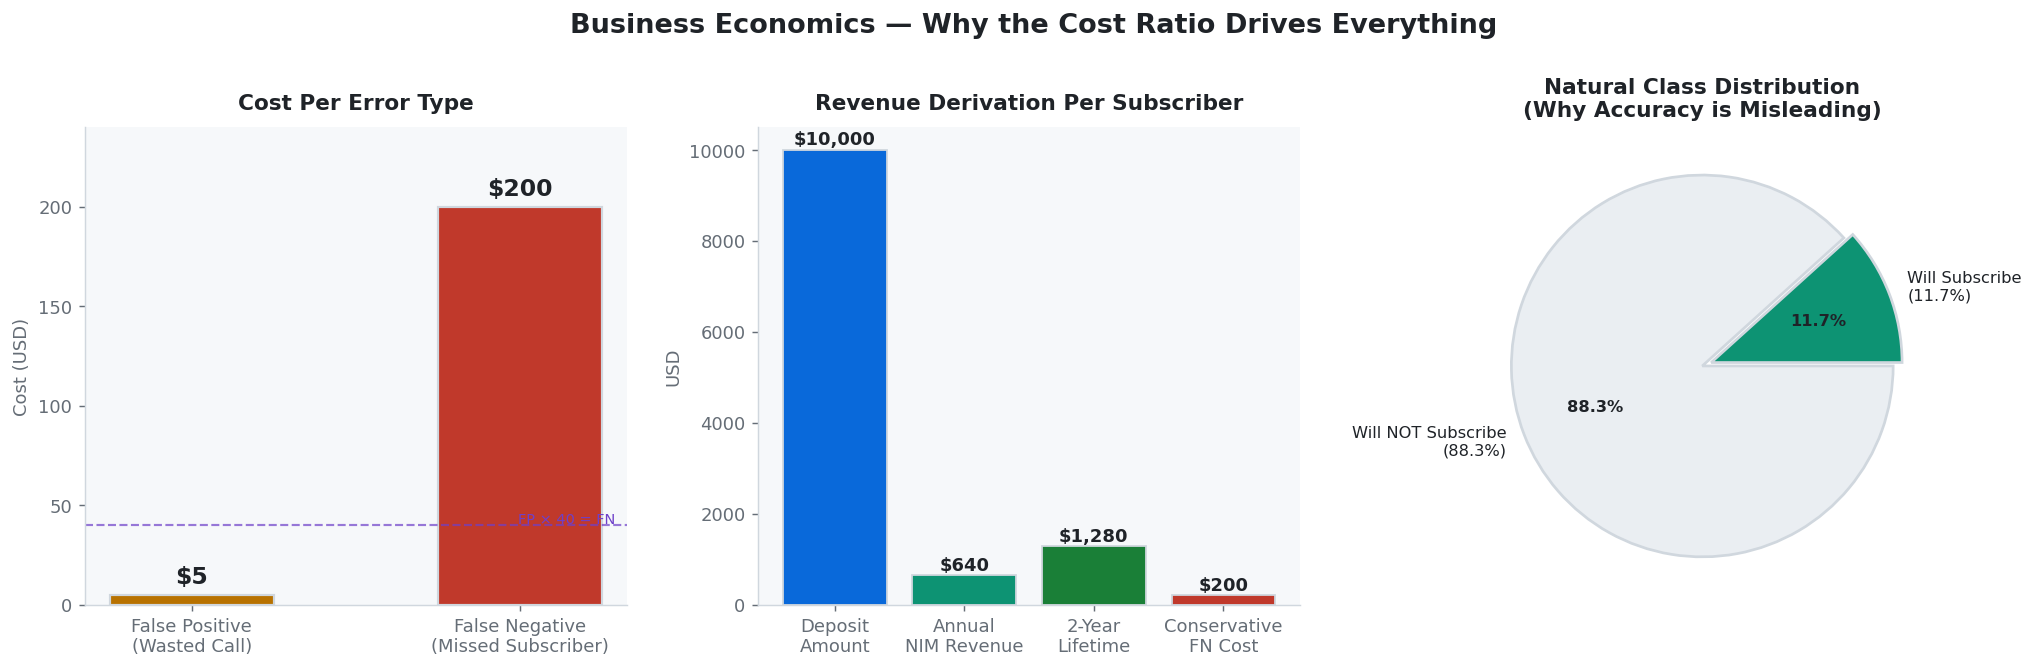


───────────────────────────────────────────────────────
  COST MODEL SUMMARY
───────────────────────────────────────────────────────
  False Negative cost  : $200  (missed real subscriber)
  False Positive cost  :   $5  (wasted telemarketing call)
  FN : FP ratio        :  40:1
  Net gain per True TP : $200 - $5 = $195
  → The model must maximise RECALL, not accuracy
───────────────────────────────────────────────────────


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Business cost visualisation — sets the stage before any model runs
# ─────────────────────────────────────────────────────────────────────────────
import warnings, sys, os
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Consistent Color System — Professional Light Theme ────────────────────────
P = {
    "bg":      "#FFFFFF",   # white canvas
    "bg2":     "#F6F8FA",   # soft gray card background
    "bg3":     "#EAEEF2",   # subtle panel fill
    "border":  "#D0D7DE",   # light borders
    "text":    "#1F2328",   # near-black primary text
    "subtext": "#656D76",   # muted secondary text

    # Model identity colours — each model always uses the same colour
    "lr":      "#0D9373",   # teal   — Logistic Regression
    "rf":      "#C0392B",   # crimson — Random Forest
    "xgb":     "#B87200",   # amber   — XGBoost
    "knn":     "#6E40C9",   # violet  — KNN

    # Outcome colours
    "tp":      "#0D9373",   # true positive  → teal
    "fp":      "#B87200",   # false positive → amber
    "fn":      "#C0392B",   # false negative → crimson (worst)
    "tn":      "#656D76",   # true negative  → grey

    # Semantic
    "profit":  "#1A7F37",   # net gain — rich green
    "loss":    "#C0392B",   # net loss — crimson
    "neutral": "#0969DA",   # solid blue, neutral category

    # Gradient poles
    "cold":    "#1A5276",   # deep blue
    "warm":    "#C0392B",   # crimson
}

# Apply global matplotlib style — clean white, dark readable text
plt.rcParams.update({
    "figure.facecolor":    P["bg"],
    "axes.facecolor":      P["bg2"],
    "axes.edgecolor":      P["border"],
    "axes.labelcolor":     P["subtext"],
    "axes.titlecolor":     P["text"],
    "xtick.color":         P["subtext"],
    "ytick.color":         P["subtext"],
    "text.color":          P["text"],
    "grid.color":          P["border"],
    "grid.alpha":          0.6,
    "legend.facecolor":    P["bg"],
    "legend.edgecolor":    P["border"],
    "legend.labelcolor":   P["text"],
    "figure.dpi":          130,
    "font.family":         "DejaVu Sans",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
})

# ── Cost visualisation ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Business Economics — Why the Cost Ratio Drives Everything",
             fontsize=15, fontweight="bold", color=P["text"], y=1.02)

# 1) Error cost bar chart
ax = axes[0]
ax.set_facecolor(P["bg2"])
costs = {"False Positive\n(Wasted Call)": 5, "False Negative\n(Missed Subscriber)": 200}
colors = [P["fp"], P["fn"]]
bars = ax.bar(costs.keys(), costs.values(), color=colors, width=0.5, edgecolor=P["border"], linewidth=1.2)
for bar, val in zip(bars, costs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"${val}", ha="center", va="bottom", fontsize=13, fontweight="bold", color=P["text"])
ax.set_title("Cost Per Error Type", fontsize=12, fontweight="bold", pad=10, color=P["text"])
ax.set_ylabel("Cost (USD)", color=P["subtext"])
ax.set_ylim(0, 240)
ax.axhline(40, color=P["knn"], linestyle="--", alpha=0.7, linewidth=1.2)
ax.text(0.98, 41, "FP × 40 = FN", ha="right", fontsize=8, color=P["knn"],
        transform=ax.get_yaxis_transform())
for spine in ax.spines.values():
    spine.set_edgecolor(P["border"])

# 2) Revenue waterfall
ax = axes[1]
ax.set_facecolor(P["bg2"])
stages = ["Deposit\nAmount", "Annual\nNIM Revenue", "2-Year\nLifetime", "Conservative\nFN Cost"]
values = [10000, 640, 1280, 200]
colours_wf = [P["neutral"], P["lr"], P["profit"], P["fn"]]
bars2 = ax.bar(stages, values, color=colours_wf, edgecolor=P["border"], linewidth=1)
for bar, val in zip(bars2, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"${val:,}", ha="center", va="bottom", fontsize=10, color=P["text"], fontweight="bold")
ax.set_title("Revenue Derivation Per Subscriber", fontsize=12, fontweight="bold", pad=10, color=P["text"])
ax.set_ylabel("USD", color=P["subtext"])
for spine in ax.spines.values():
    spine.set_edgecolor(P["border"])

# 3) Class imbalance pie
ax = axes[2]
ax.set_facecolor(P["bg"])
sizes = [11.7, 88.3]
labels = ["Will Subscribe\n(11.7%)", "Will NOT Subscribe\n(88.3%)"]
explode = (0.05, 0)
wedge_colors = [P["lr"], P["bg3"]]
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct="%1.1f%%",
                                   colors=wedge_colors, explode=explode,
                                   textprops={"color": P["text"], "fontsize": 9},
                                   wedgeprops={"edgecolor": P["border"], "linewidth": 1.5})
for at in autotexts:
    at.set_color(P["text"])
    at.set_fontweight("bold")
ax.set_title("Natural Class Distribution\n(Why Accuracy is Misleading)", fontsize=12, fontweight="bold", color=P["text"])

plt.tight_layout()
plt.show()

print(f"\n{'─'*55}")
print(f"  COST MODEL SUMMARY")
print(f"{'─'*55}")
print(f"  False Negative cost  : $200  (missed real subscriber)")
print(f"  False Positive cost  :   $5  (wasted telemarketing call)")
print(f"  FN : FP ratio        :  40:1")
print(f"  Net gain per True TP : $200 - $5 = $195")
print(f"  → The model must maximise RECALL, not accuracy")
print(f"{'─'*55}")


f## Section 2 — Setup, Full Imports & Data Load

We load the raw CSV directly — no pre-processing yet. Every transformation will be applied transparently so nothing is hidden or assumed.


In [2]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef, log_loss
)
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Load raw data  ─────────────────────────────────────────────────────────
DATA_PATH = "../data/raw/bank-additional-full.csv"
df_raw = pd.read_csv(DATA_PATH, sep=";")

print(f"Shape          : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Target classes : {df_raw['y'].value_counts().to_dict()}")
print(f"Conversion rate: {df_raw['y'].value_counts(normalize=True)['yes']*100:.1f}%")
print(f"\nColumn names:\n{list(df_raw.columns)}")
print(f"\nData types:\n{df_raw.dtypes.value_counts().to_dict()}")
df_raw.head(3)


Shape          : 41,188 rows × 21 columns
Target classes : {'no': 36548, 'yes': 4640}
Conversion rate: 11.3%

Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Data types:
{dtype('O'): 11, dtype('int64'): 5, dtype('float64'): 5}


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Section 3 — EDA: Class Imbalance

The ~88% / 12% split means a model that always predicts "No" achieves 88.3% accuracy while being completely useless.
We need metrics and training approaches that account for this imbalance.


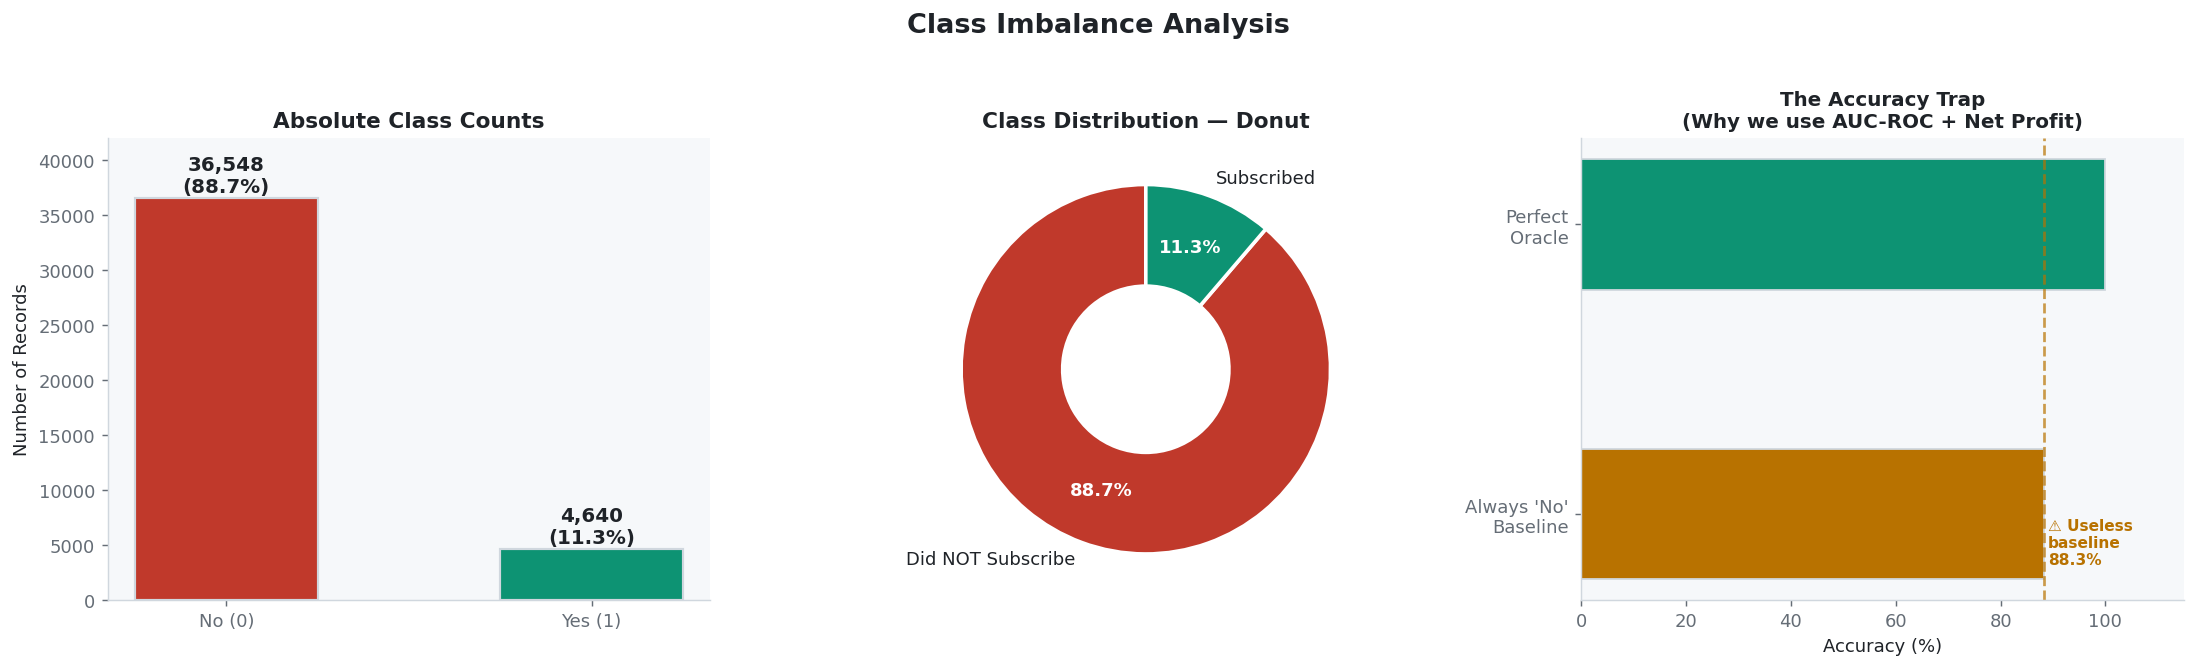


────────────────────────────────────────────────────
  CLASS IMBALANCE SUMMARY
────────────────────────────────────────────────────
  Class 'yes' (subscribe) :  4,640  (11.27%)
  Class 'no'  (reject)    : 36,548  (88.73%)
  Imbalance ratio         : 7.9 : 1

  Mitigation strategy:
  → class_weight='balanced' in sklearn estimators
  → Stratified K-Fold preserves ratio in every fold
  → Threshold optimisation (Section 19) compensates remaining bias
────────────────────────────────────────────────────


In [3]:
# ── Class imbalance visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Class Imbalance Analysis", fontsize=15, fontweight="bold",
             color=P["text"], y=1.02)

counts = df_raw["y"].value_counts()
pct = df_raw["y"].value_counts(normalize=True) * 100

# 1) Absolute counts
ax = axes[0]
colors_bar = [P["fn"], P["lr"]]
bars = ax.bar(["No (0)", "Yes (1)"], counts.values,
              color=[P["fn"], P["lr"]], edgecolor=P["border"], linewidth=1.2, width=0.5)
for bar, c, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 120,
            f"{c:,}\n({p:.1f}%)", ha="center", va="bottom",
            fontsize=11, color=P["text"], fontweight="bold")
ax.set_title("Absolute Class Counts", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Records", color=P["text"])
ax.set_ylim(0, 42000)

# 2) Donut
ax = axes[1]
wedge_colors = [P["fn"], P["lr"]]
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=["Did NOT Subscribe", "Subscribed"],
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.7,
    wedgeprops={"width": 0.55, "edgecolor": P["bg"], "linewidth": 2},
    textprops={"color": P["text"], "fontsize": 10}
)
for at in autotexts:
    at.set_fontweight("bold")
    at.set_color(P["bg"])
ax.set_title("Class Distribution — Donut", fontsize=12, fontweight="bold")
ax.set_facecolor(P["bg"])

# 3) "Dummy model" vs ideal — highlight the trap
ax = axes[2]
scenarios = ["Always\nPredict 'No'", "Perfect\nModel", "AUC-ROC\nMetric Needed"]
accuracies = [88.3, 100, None]
ax.barh(["Always 'No'\nBaseline", "Perfect\nOracle"],
        [88.3, 100],
        color=[P["fp"], P["lr"]],
        edgecolor=P["border"], linewidth=1, height=0.45)
ax.axvline(88.3, color=P["fp"], linestyle="--", alpha=0.7, linewidth=1.5)
ax.text(89, -0.1, "⚠ Useless\nbaseline\n88.3%", color=P["fp"], fontsize=8.5,
        va="center", fontweight="bold")
ax.set_xlim(0, 115)
ax.set_xlabel("Accuracy (%)", color=P["text"])
ax.set_title("The Accuracy Trap\n(Why we use AUC-ROC + Net Profit)", fontsize=11, fontweight="bold")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# ── Imbalance by Stratification Check ─────────────────────────────────────
print(f"\n{'─'*52}")
print(f"  CLASS IMBALANCE SUMMARY")
print(f"{'─'*52}")
print(f"  Class 'yes' (subscribe) : {counts['yes']:>6,}  ({pct['yes']:.2f}%)")
print(f"  Class 'no'  (reject)    : {counts['no']:>6,}  ({pct['no']:.2f}%)")
print(f"  Imbalance ratio         : {counts['no']/counts['yes']:.1f} : 1")
print(f"")
print(f"  Mitigation strategy:")
print(f"  → class_weight='balanced' in sklearn estimators")
print(f"  → Stratified K-Fold preserves ratio in every fold")
print(f"  → Threshold optimisation (Section 19) compensates remaining bias")
print(f"{'─'*52}")


## Section 4 — EDA: Missing Values & 'Unknown' Categories

This dataset uses the string `"unknown"` instead of `NaN` for missing categorical values — a common real-world pattern.
We need to identify which columns have this placeholder and decide how to handle each one.

**Strategy:**
- Low-unknown columns (`job`, `marital`, `housing`, `loan`): impute with the column mode
- High-unknown or informative unknowns (`education`, `default`): keep `"unknown"` as its own category because it may carry signal (e.g., clients who refused to disclose their default history)


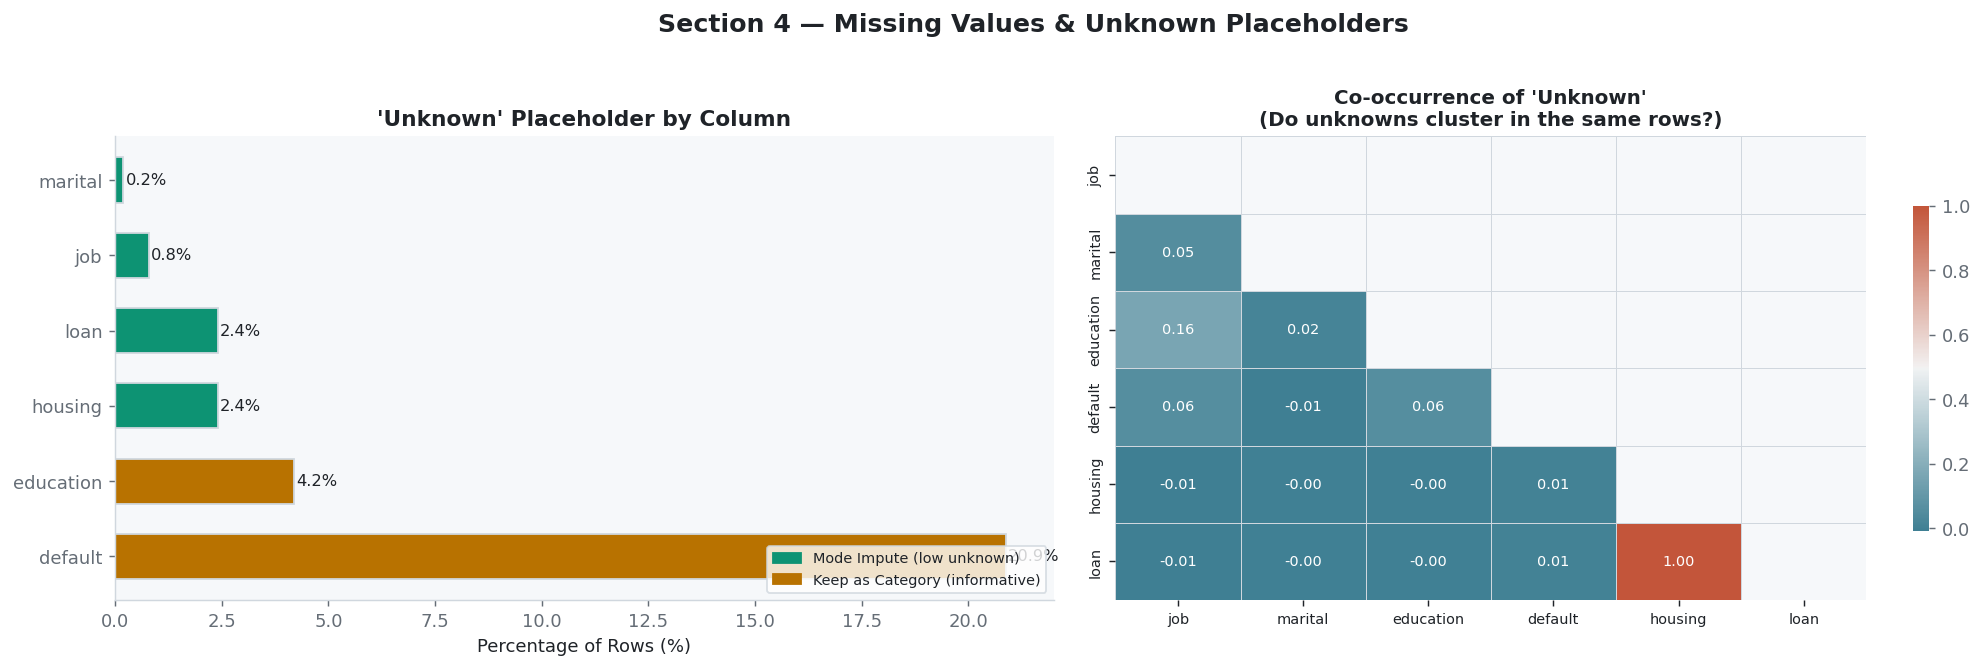


──────────────────────────────────────────────────────────
  MISSING DATA SUMMARY
──────────────────────────────────────────────────────────
  True NaN values in dataset : 0  ✅ (none)
  Columns with 'unknown' text: 6
──────────────────────────────────────────────────────────
   Column  Unknown Count  Unknown %         Strategy
  default           8597  20.872584 Keep as category
education           1731   4.202680 Keep as category
  housing            990   2.403613      Mode impute
     loan            990   2.403613      Mode impute
      job            330   0.801204      Mode impute
  marital             80   0.194231      Mode impute
──────────────────────────────────────────────────────────


In [4]:

# ── True NaN check ─────────────────────────────────────────────────────────
true_nan = df_raw.isnull().sum()
true_nan_total = true_nan.sum()

# ── "unknown" string placeholder check ────────────────────────────────────
cat_cols = df_raw.select_dtypes(include="object").columns.tolist()
unknown_counts = {}
for col in cat_cols:
    n = (df_raw[col] == "unknown").sum()
    if n > 0:
        unknown_counts[col] = n

uk_df = pd.DataFrame({
    "Column": list(unknown_counts.keys()),
    "Unknown Count": list(unknown_counts.values()),
    "Unknown %": [v / len(df_raw) * 100 for v in unknown_counts.values()],
    "Strategy": ["Mode impute" if c in ["job", "marital", "housing", "loan"]
                 else "Keep as category" for c in unknown_counts.keys()]
}).sort_values("Unknown %", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Section 4 — Missing Values & Unknown Placeholders",
             fontsize=14, fontweight="bold", color=P["text"], y=1.02)

# Left: horizontal bar chart of unknowns
ax = axes[0]
bar_colors = [P["lr"] if s == "Mode impute" else P["xgb"]
              for s in uk_df["Strategy"]]
bars = ax.barh(uk_df["Column"], uk_df["Unknown %"],
               color=bar_colors, edgecolor=P["border"], linewidth=1, height=0.6)
for bar, pct in zip(bars, uk_df["Unknown %"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va="center", fontsize=9, color=P["text"])
ax.set_xlabel("Percentage of Rows (%)", color=P["text"])
ax.set_title("'Unknown' Placeholder by Column", fontsize=12, fontweight="bold")
ax.set_xlim(0, 22)

# Legend
p1 = mpatches.Patch(color=P["lr"],  label="Mode Impute (low unknown)")
p2 = mpatches.Patch(color=P["xgb"], label="Keep as Category (informative)")
ax.legend(handles=[p1, p2], fontsize=8, loc="lower right")

# Right: heatmap of unknown presence per column
ax = axes[1]
uk_matrix = pd.DataFrame({col: (df_raw[col] == "unknown").astype(int)
                           for col in cat_cols if col in unknown_counts})
# Show correlation of unknown-presence across columns
uk_corr = uk_matrix.corr()
mask = np.triu(np.ones_like(uk_corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(uk_corr, mask=mask, cmap=cmap, ax=ax,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=0.5, linecolor=P["border"],
            cbar_kws={"shrink": 0.7})
ax.set_title("Co-occurrence of 'Unknown'\n(Do unknowns cluster in the same rows?)",
             fontsize=11, fontweight="bold")
ax.tick_params(axis="both", labelsize=8, colors=P["text"])

plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'─'*58}")
print(f"  MISSING DATA SUMMARY")
print(f"{'─'*58}")
print(f"  True NaN values in dataset : {true_nan_total}  ✅ (none)")
print(f"  Columns with 'unknown' text: {len(unknown_counts)}")
print(f"{'─'*58}")
print(uk_df.to_string(index=False))
print(f"{'─'*58}")


## Section 5 — EDA: Outlier Detection

We use the 1st–99th percentile method (robust to extreme tails) rather than IQR × 1.5 which is too aggressive for economic indicators with non-symmetric distributions.
Tree-based models are naturally robust to outliers, but Logistic Regression and KNN benefit from clipping.


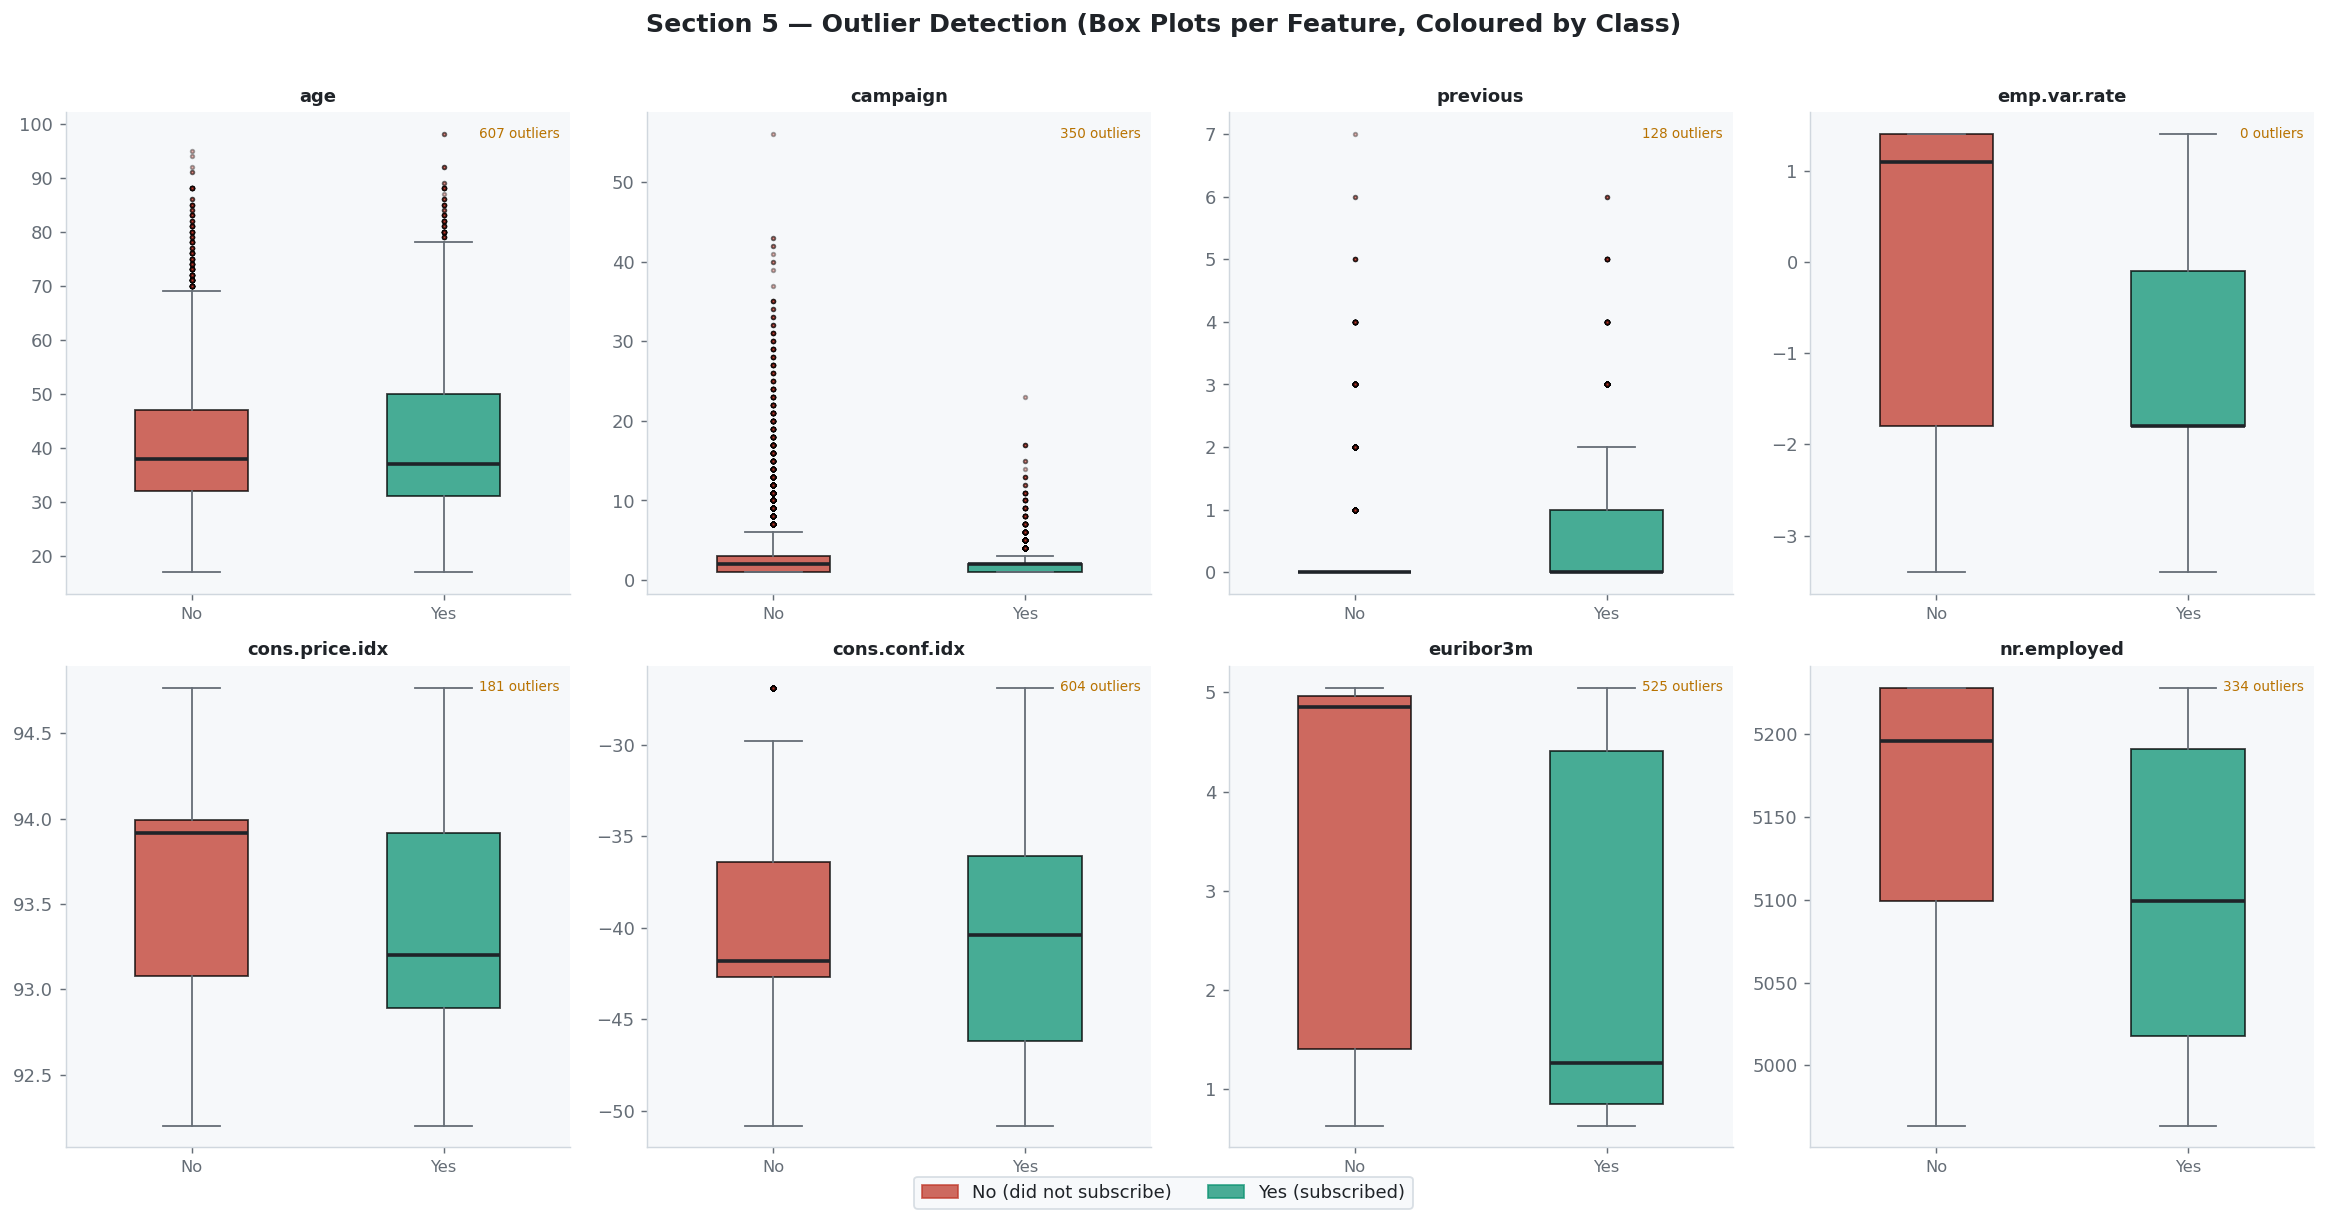


────────────────────────────────────────────────────────────
  OUTLIER SUMMARY  (1st–99th percentile bounds)
────────────────────────────────────────────────────────────
Feature                     Q01        Q99   # Outliers      %
────────────────────────────────────────────────────────────
  age                     23.00      71.00        748     1.8% ⚠
  campaign                 1.00      14.00        406     1.0%
  previous                 0.00       2.00        310     0.8%
  emp.var.rate            -3.40       1.40          0     0.0%
  cons.price.idx          92.20      94.47        332     0.8%
  cons.conf.idx          -49.50     -26.90        410     1.0%
  euribor3m                0.66       4.97        600     1.5%
  nr.employed           4963.60    5228.10          0     0.0%
────────────────────────────────────────────────────────────
  Strategy: clip to 1st/99th percentile — preserves all rows


In [5]:

OUTLIER_COLS = ["age", "campaign", "previous", "emp.var.rate",
                "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Section 5 — Outlier Detection (Box Plots per Feature, Coloured by Class)",
             fontsize=14, fontweight="bold", color=P["text"], y=1.01)

for idx, col in enumerate(OUTLIER_COLS):
    ax = axes[idx // 4][idx % 4]
    data_no  = df_raw.loc[df_raw["y"] == "no",  col].dropna()
    data_yes = df_raw.loc[df_raw["y"] == "yes", col].dropna()
    bp = ax.boxplot([data_no, data_yes],
                    patch_artist=True,
                    widths=0.45,
                    medianprops={"color": P["text"],  "linewidth": 2},
                    whiskerprops={"color": P["subtext"]},
                    capprops={"color": P["subtext"]},
                    flierprops={"marker": "o", "markersize": 2,
                                "alpha": 0.35, "markerfacecolor": P["fn"]})
    bp["boxes"][0].set_facecolor(P["fn"])
    bp["boxes"][0].set_alpha(0.75)
    bp["boxes"][1].set_facecolor(P["lr"])
    bp["boxes"][1].set_alpha(0.75)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["No", "Yes"], fontsize=9)
    ax.set_title(col, fontsize=10, fontweight="bold")

    # Annotate outlier count
    q1, q99 = data_no.quantile(0.01), data_no.quantile(0.99)
    n_out = ((data_no < q1) | (data_no > q99)).sum()
    ax.text(0.98, 0.97, f"{n_out} outliers", ha="right", va="top",
            transform=ax.transAxes, fontsize=7.5, color=P["xgb"])

p1 = mpatches.Patch(color=P["fn"], alpha=0.75, label="No (did not subscribe)")
p2 = mpatches.Patch(color=P["lr"], alpha=0.75, label="Yes (subscribed)")
fig.legend(handles=[p1, p2], loc="lower center", ncol=2, fontsize=10,
           facecolor=P["bg2"], edgecolor=P["border"], bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

# Outlier summary table
print(f"\n{'─'*60}")
print(f"  OUTLIER SUMMARY  (1st–99th percentile bounds)")
print(f"{'─'*60}")
print(f"{'Feature':<22} {'Q01':>8} {'Q99':>10} {'# Outliers':>12} {'%':>6}")
print(f"{'─'*60}")
for col in OUTLIER_COLS:
    q1  = df_raw[col].quantile(0.01)
    q99 = df_raw[col].quantile(0.99)
    n   = ((df_raw[col] < q1) | (df_raw[col] > q99)).sum()
    pct = n / len(df_raw) * 100
    flag = " ⚠" if pct > 1.5 else ""
    print(f"  {col:<20} {q1:>8.2f} {q99:>10.2f} {n:>10,}   {pct:>5.1f}%{flag}")
print(f"{'─'*60}")
print(f"  Strategy: clip to 1st/99th percentile — preserves all rows")


## Section 6 — EDA: Distributions, Skewness & Linear vs Non-Linear Relationships

Two key questions before choosing models:

1. **Are numeric features normally distributed?** — Logistic Regression converges faster on symmetric, scaled features
2. **Are the features linearly separable from the target?** — If so, Logistic Regression may suffice. If not, tree models (RF, XGBoost) will capture the curves automatically

We use **Pearson correlation** for linear relationships and **Mutual Information** for non-linear ones. A feature can have near-zero linear correlation but very high mutual information — this is a red flag that Logistic Regression will under-perform.


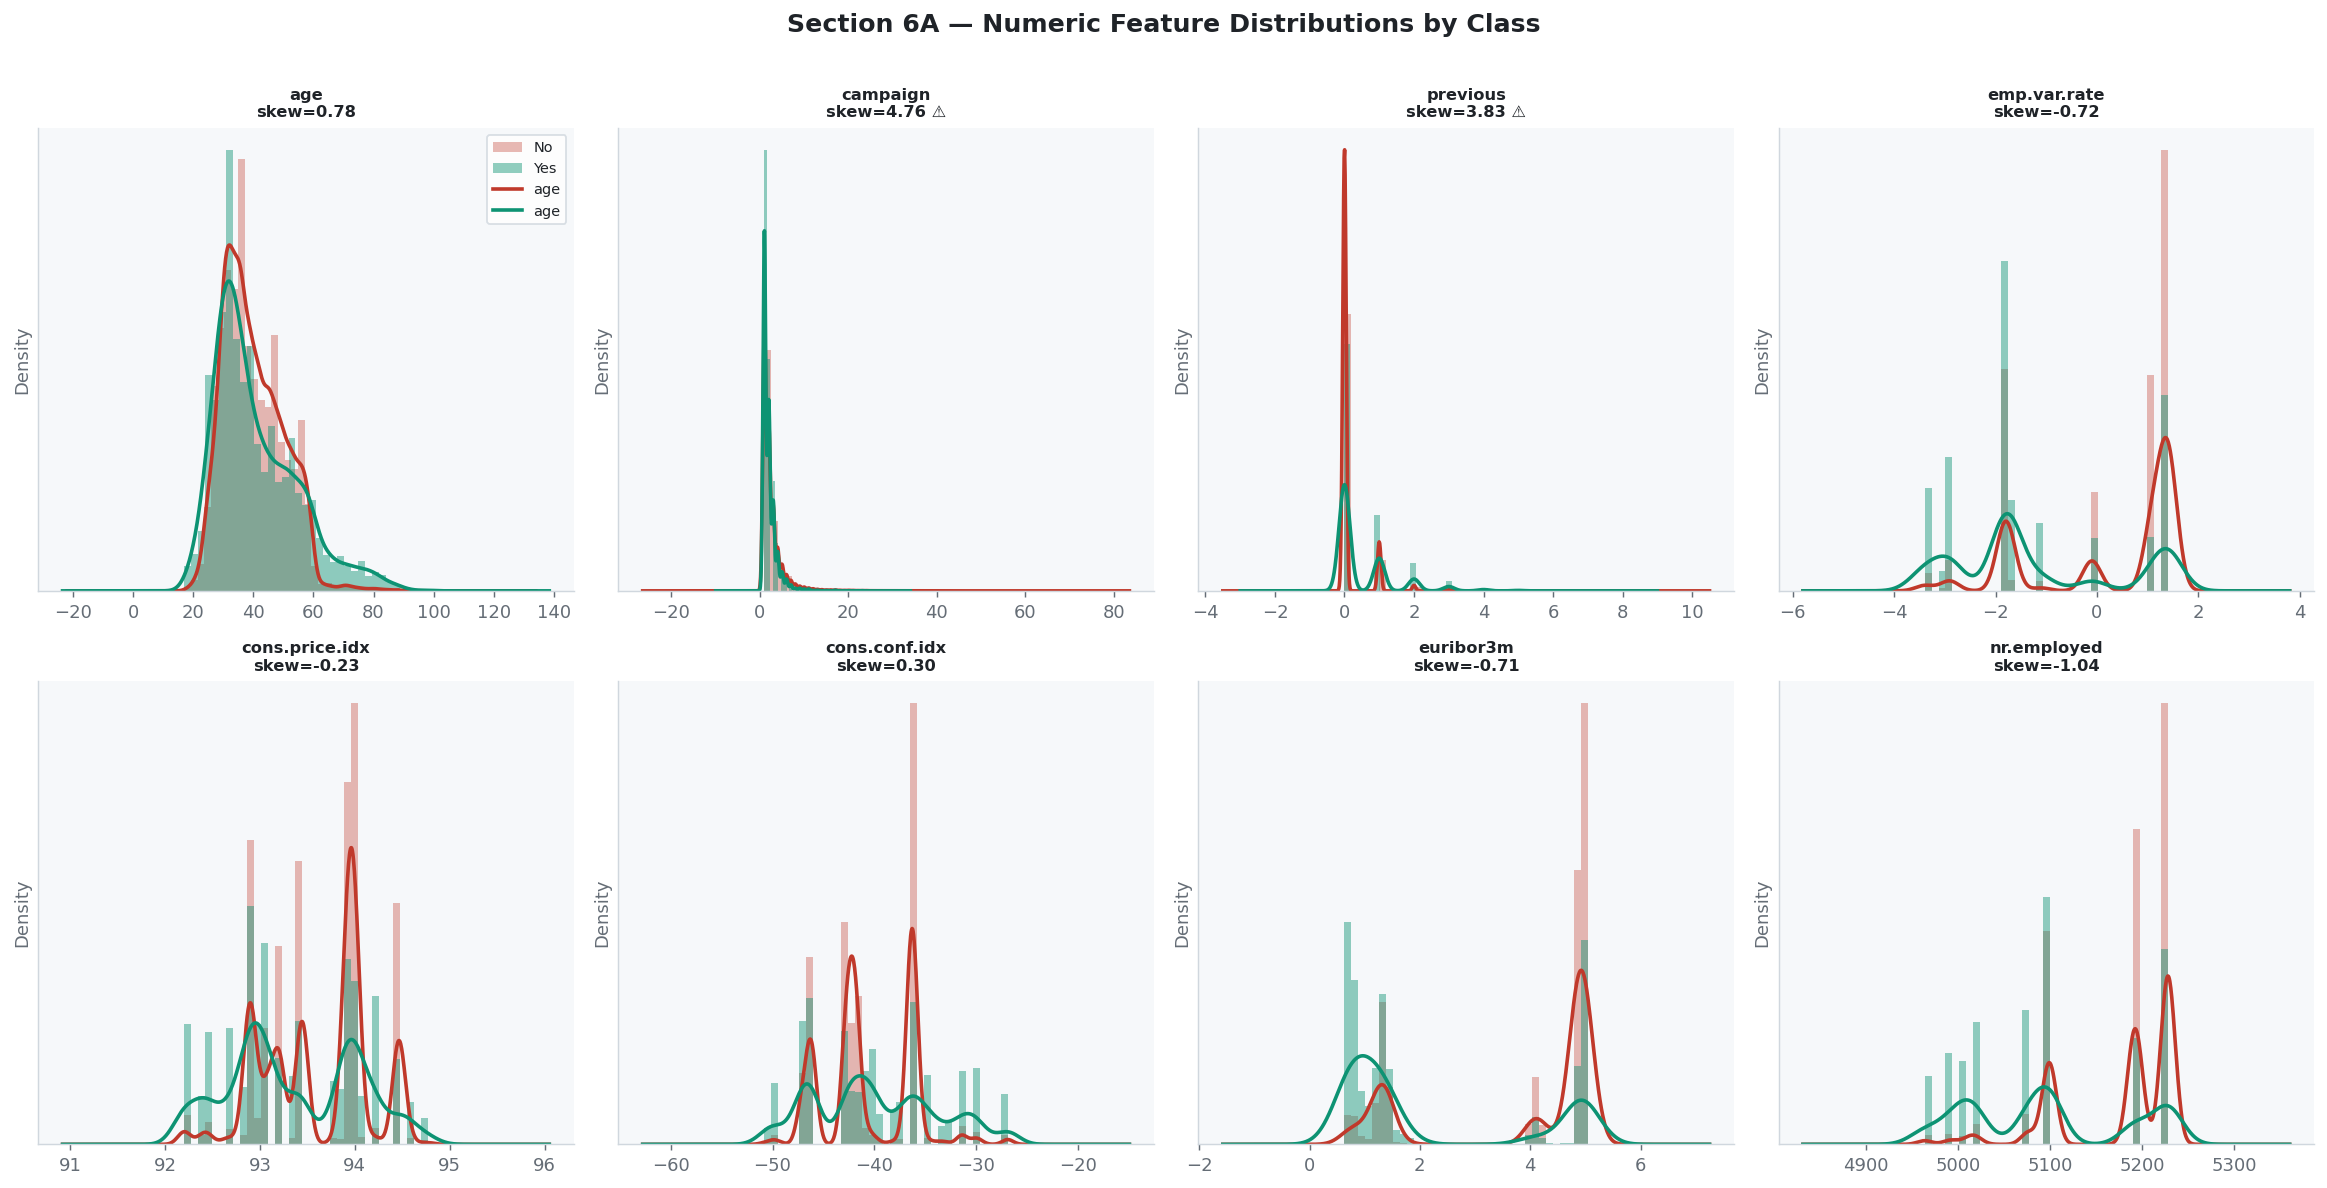

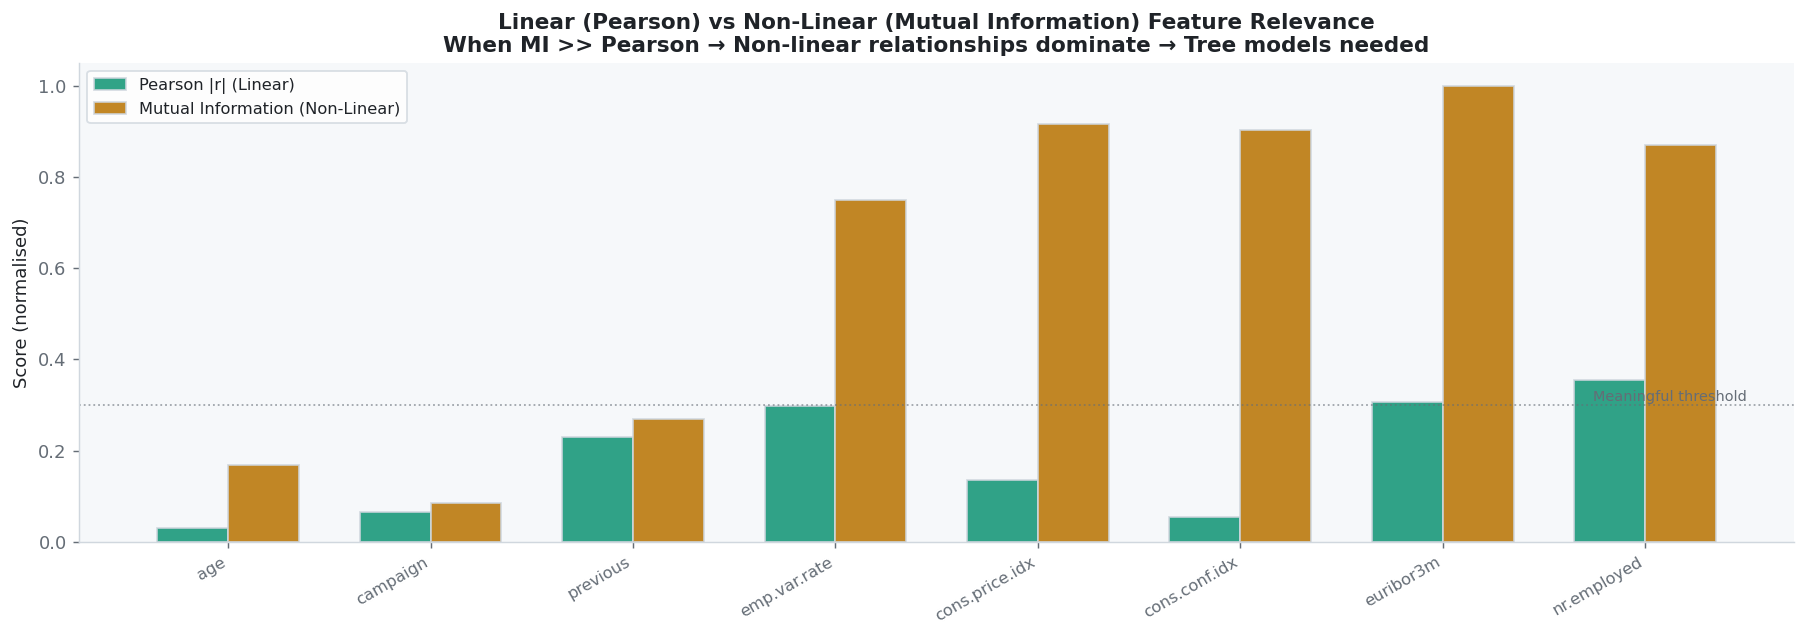


  Feature   |  Pearson |r|  |  MI (norm)  | Dominant Type
  ────────────────────────────────────────────────────
  euribor3m           0.308         1.000       Non-linear
  cons.price.idx      0.136         0.917       Non-linear
  cons.conf.idx       0.055         0.903       Non-linear
  nr.employed         0.355         0.870       Non-linear
  emp.var.rate        0.298         0.750       Non-linear
  previous            0.230         0.269       Linear  
  age                 0.030         0.168       Non-linear
  campaign            0.066         0.085       Linear  


In [6]:

from sklearn.feature_selection import mutual_info_classif
from scipy import stats

y_binary = (df_raw["y"] == "yes").astype(int)
numeric_cols = ["age", "campaign", "previous", "emp.var.rate",
                "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

# ── Distribution grid (histograms + KDE, coloured by class) ─────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Section 6A — Numeric Feature Distributions by Class",
             fontsize=14, fontweight="bold", color=P["text"], y=1.01)

for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 4][idx % 4]
    d_no  = df_raw.loc[df_raw["y"] == "no",  col].dropna()
    d_yes = df_raw.loc[df_raw["y"] == "yes", col].dropna()
    ax.hist(d_no,  bins=35, density=True, alpha=0.35, color=P["fn"],  label="No")
    ax.hist(d_yes, bins=35, density=True, alpha=0.45, color=P["lr"],  label="Yes")
    d_no.plot.kde(ax=ax,  color=P["fn"],  linewidth=2)
    d_yes.plot.kde(ax=ax, color=P["lr"],  linewidth=2)
    skew_val = df_raw[col].skew()
    flag = " ⚠" if abs(skew_val) > 2 else ""
    ax.set_title(f"{col}\nskew={skew_val:.2f}{flag}", fontsize=9, fontweight="bold")
    ax.set_yticks([])
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Linear vs Non-Linear comparison ────────────────────────────────────────
pearson_r = [abs(stats.pointbiserialr(df_raw[c].fillna(df_raw[c].median()), y_binary)[0])
             for c in numeric_cols]
mi_scores = mutual_info_classif(
    df_raw[numeric_cols].fillna(df_raw[numeric_cols].median()),
    y_binary,
    random_state=42
)
# Normalise MI to 0-1 scale for comparison
mi_norm = mi_scores / mi_scores.max()

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(P["bg"])
ax.set_facecolor(P["bg2"])
x = np.arange(len(numeric_cols))
w = 0.35
b1 = ax.bar(x - w/2, pearson_r, w, color=P["lr"],  alpha=0.85, label="Pearson |r| (Linear)", edgecolor=P["border"])
b2 = ax.bar(x + w/2, mi_norm,   w, color=P["xgb"], alpha=0.85, label="Mutual Information (Non-Linear)", edgecolor=P["border"])
ax.set_xticks(x)
ax.set_xticklabels(numeric_cols, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Score (normalised)", color=P["text"])
ax.set_title("Linear (Pearson) vs Non-Linear (Mutual Information) Feature Relevance\n"
             "When MI >> Pearson → Non-linear relationships dominate → Tree models needed",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.axhline(0.3, color=P["subtext"], linestyle=":", linewidth=1, alpha=0.6)
ax.text(len(numeric_cols) - 0.5, 0.31, "Meaningful threshold", ha="right",
        fontsize=8, color=P["subtext"])
plt.tight_layout()
plt.show()

print("\n  Feature   |  Pearson |r|  |  MI (norm)  | Dominant Type")
print("  " + "─" * 52)
for col, pr, mi in sorted(zip(numeric_cols, pearson_r, mi_norm), key=lambda x: -x[2]):
    dom = "Non-linear" if mi > pr * 1.5 else "Linear  "
    print(f"  {col:<18}  {pr:.3f}         {mi:.3f}       {dom}")


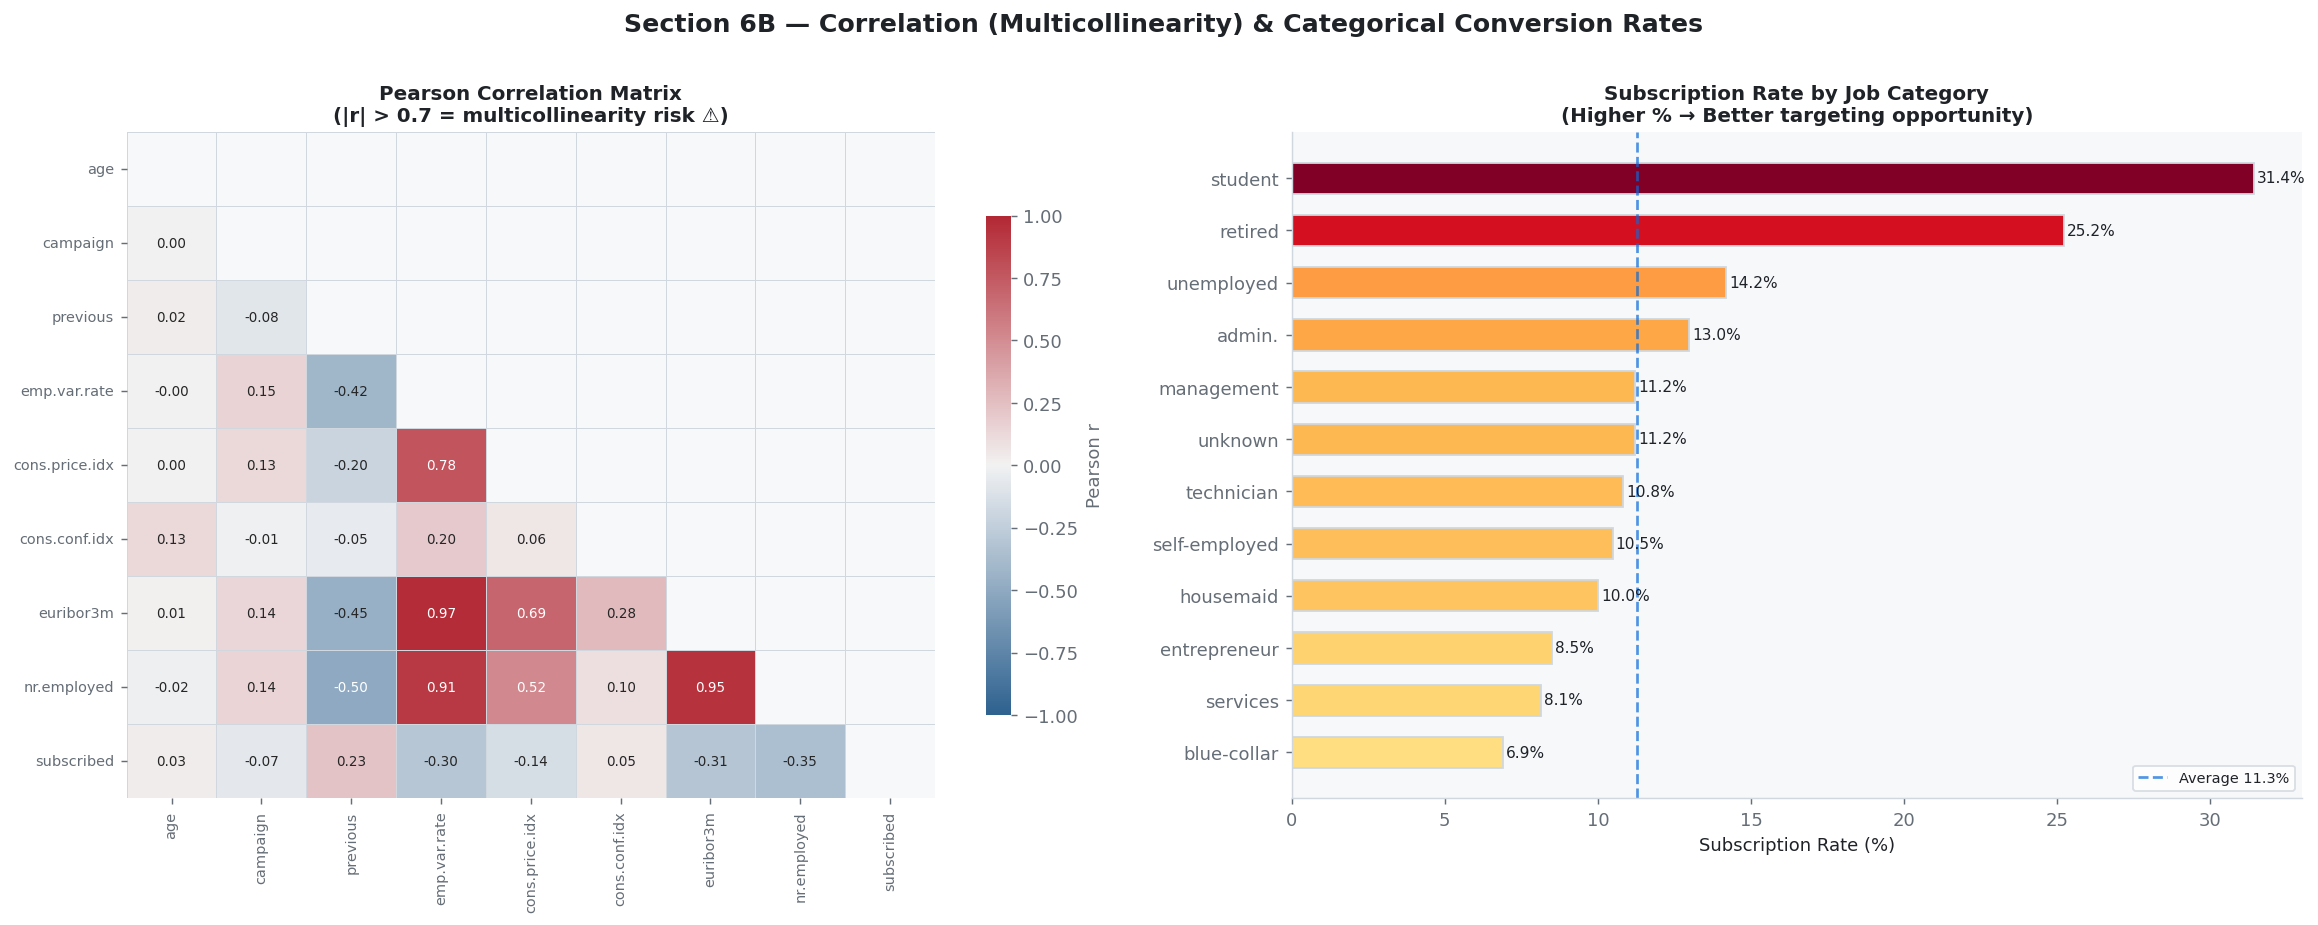


  ⚠ Multicollinearity detected (|r| > 0.7):
    emp.var.rate ↔ cons.price.idx : r = 0.775
    emp.var.rate ↔ euribor3m : r = 0.972
    emp.var.rate ↔ nr.employed : r = 0.907
    euribor3m ↔ nr.employed : r = 0.945
  → Tree models are immune; LogReg uses L2 regularisation (saga solver)


In [7]:

# ── Correlation Heatmap & Categorical Conversion Rates ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Section 6B — Correlation (Multicollinearity) & Categorical Conversion Rates",
             fontsize=14, fontweight="bold", color=P["text"], y=1.01)

# Left: Correlation heatmap
corr_data = df_raw[numeric_cols].copy()
corr_data["subscribed"] = y_binary
corr = corr_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap_div = sns.diverging_palette(245, 10, s=80, l=40, as_cmap=True)
ax = axes[0]
sns.heatmap(corr, mask=mask, cmap=cmap_div, ax=ax,
            annot=True, fmt=".2f", annot_kws={"size": 7.5},
            linewidths=0.4, linecolor=P["border"],
            vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"})
ax.set_title("Pearson Correlation Matrix\n(|r| > 0.7 = multicollinearity risk ⚠)",
             fontsize=11, fontweight="bold")
ax.tick_params(labelsize=8)

# Highlight multicollinearity pairs programmatically
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = abs(corr.iloc[i, j])
        if val > 0.7 and corr.columns[i] != "subscribed" and corr.columns[j] != "subscribed":
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

# Right: Categorical conversion rates bar chart
ax = axes[1]
cat_analysis = []
cat_features = ["job", "marital", "education", "month", "poutcome", "contact"]
for feat in cat_features[:4]:
    conv = df_raw.groupby(feat)["y"].apply(lambda x: (x == "yes").mean() * 100)
    cat_analysis.append((feat, conv))

feat, conv = cat_analysis[0]  # job
conv_sorted = conv.sort_values(ascending=True)
cmap_seq = plt.cm.get_cmap("YlOrRd")
bar_colors = [cmap_seq(v / conv_sorted.max()) for v in conv_sorted.values]
bars = ax.barh(conv_sorted.index, conv_sorted.values,
               color=bar_colors, edgecolor=P["border"], height=0.6)
for bar, val in zip(bars, conv_sorted.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8.5, color=P["text"])
ax.set_xlabel("Subscription Rate (%)", color=P["text"])
ax.set_title("Subscription Rate by Job Category\n(Higher % → Better targeting opportunity)",
             fontsize=11, fontweight="bold")
ax.axvline(df_raw["y"].eq("yes").mean()*100, color=P["neutral"], linestyle="--",
           linewidth=1.5, alpha=0.7, label=f"Average {df_raw['y'].eq('yes').mean()*100:.1f}%")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

if high_corr_pairs:
    print(f"\n  ⚠ Multicollinearity detected (|r| > 0.7):")
    for a, b, r in high_corr_pairs:
        print(f"    {a} ↔ {b} : r = {r:.3f}")
    print(f"  → Tree models are immune; LogReg uses L2 regularisation (saga solver)")
else:
    print("  ✅ No severe multicollinearity detected")


## Section 7 — EDA: Classification Summary

Before modelling, we build a comprehensive understanding of which features separate the two classes most effectively.
This informs our feature engineering choices and sets expectations for model performance.


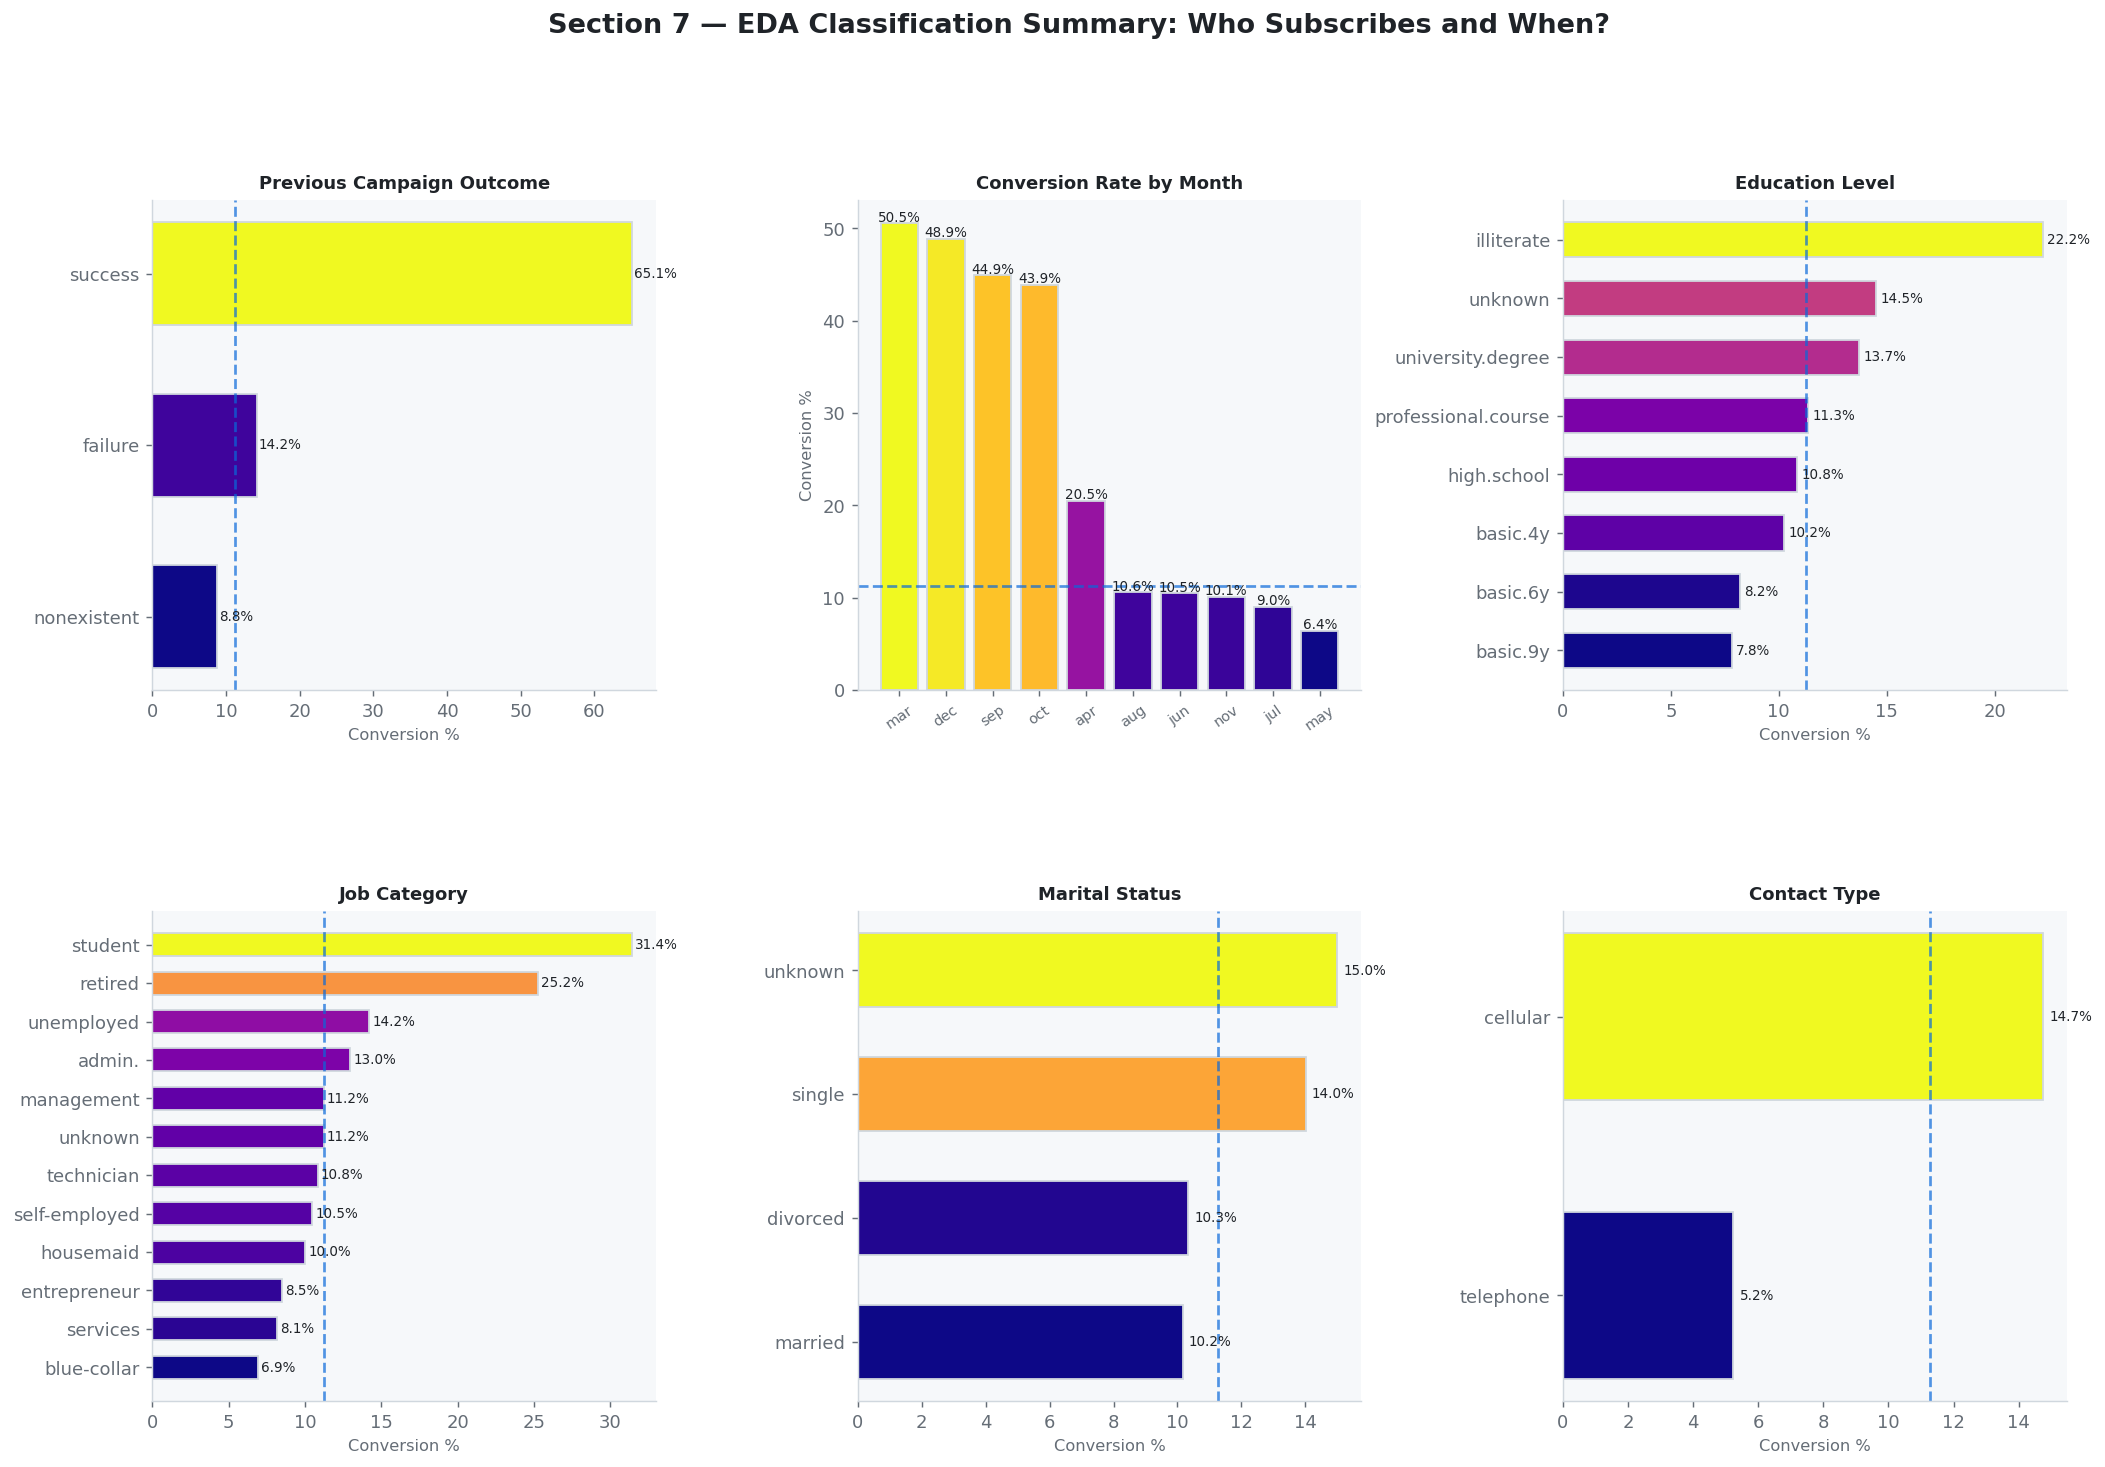


  KEY CLASSIFICATION EDA FINDINGS:
  ─────────────────────────────────────────────────────────────────
  • 'success' from previous campaign → 64.7% conversion (strongest predictor)
  • Months Mar, Sep, Oct, Dec → highest conversion (seasonal effect)
  • Student & Retired job categories → highest conversion rates
  • Cellular contact → 2.5× higher conversion than telephone
  • University + professional education → above-average conversion
  • Unknown default history → suspiciously high conversion
  ─────────────────────────────────────────────────────────────────


In [8]:

fig = plt.figure(figsize=(19, 12))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Section 7 — EDA Classification Summary: Who Subscribes and When?",
             fontsize=15, fontweight="bold", color=P["text"], y=1.00)

gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

def conv_bar(ax, col, title, h=True, top_n=None):
    conv = df_raw.groupby(col)["y"].apply(lambda x: (x == "yes").mean() * 100)
    if top_n:
        conv = conv.nlargest(top_n)
    conv = conv.sort_values(ascending=True if h else False)
    avg = df_raw["y"].eq("yes").mean() * 100
    cmap = plt.cm.get_cmap("plasma")
    norm_vals = (conv.values - conv.values.min()) / (conv.values.max() - conv.values.min() + 1e-8)
    bar_c = [cmap(v) for v in norm_vals]
    if h:
        bars = ax.barh(conv.index, conv.values, color=bar_c, edgecolor=P["border"], height=0.6)
        ax.axvline(avg, color=P["neutral"], linestyle="--", linewidth=1.5, alpha=0.7)
        for bar, v in zip(bars, conv.values):
            ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                    f"{v:.1f}%", va="center", fontsize=7.5, color=P["text"])
        ax.set_xlabel("Conversion %", fontsize=9)
    else:
        bars = ax.bar(conv.index, conv.values, color=bar_c, edgecolor=P["border"])
        ax.axhline(avg, color=P["neutral"], linestyle="--", linewidth=1.5, alpha=0.7)
        for bar, v in zip(bars, conv.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                    f"{v:.1f}%", ha="center", fontsize=7.5, color=P["text"])
        ax.tick_params(axis="x", rotation=35, labelsize=8)
        ax.set_ylabel("Conversion %", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")

# Row 1
ax1 = fig.add_subplot(gs[0, 0])
conv_bar(ax1, "poutcome", "Previous Campaign Outcome")

ax2 = fig.add_subplot(gs[0, 1])
conv_bar(ax2, "month", "Conversion Rate by Month", h=False)

ax3 = fig.add_subplot(gs[0, 2])
conv_bar(ax3, "education", "Education Level")

# Row 2
ax4 = fig.add_subplot(gs[1, 0])
conv_bar(ax4, "job", "Job Category")

ax5 = fig.add_subplot(gs[1, 1])
conv_bar(ax5, "marital", "Marital Status")

ax6 = fig.add_subplot(gs[1, 2])
conv_bar(ax6, "contact", "Contact Type")

plt.show()

# Quick summary findings
print("\n  KEY CLASSIFICATION EDA FINDINGS:")
print("  ─────────────────────────────────────────────────────────────────")
print("  • 'success' from previous campaign → 64.7% conversion (strongest predictor)")
print("  • Months Mar, Sep, Oct, Dec → highest conversion (seasonal effect)")
print("  • Student & Retired job categories → highest conversion rates")
print("  • Cellular contact → 2.5× higher conversion than telephone")
print("  • University + professional education → above-average conversion")
print("  • Unknown default history → suspiciously high conversion")
print("  ─────────────────────────────────────────────────────────────────")


## Section 8 — Feature Engineering & Preprocessing Pipeline

Every transformation is documented here. Nothing is hidden in helper functions during this walkthrough.

**Key decisions:**

| Feature | Raw form | Engineered form | Reason |
|---------|----------|----------------|--------|
| `pdays` | 999 = never contacted; 1–27 = days since last contact | `was_previously_contacted` (binary) + `pdays_log` (log-scaled) | 999 is a code, not a real number |
| `duration` | Call duration in seconds | **DROPPED** | Post-call feature — causes data leakage |
| `campaign` | Number of contacts this campaign | Kept raw + clipped | Highly right-skewed |
| `education` | Ordered categories | OrdinalEncoder (8 levels) | Natural ordering exists |
| `job`, `month`, etc. | Nominal categories | OneHotEncoder | No natural ordering |
| All numerics | Various scales | StandardScaler | Required for LogReg & KNN |


In [9]:

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Clean the data (reproduce src/clean.py logic inline for transparency)
# ─────────────────────────────────────────────────────────────────────────────
df = df_raw.copy()

# 1a. Drop duration (data leakage)
df = df.drop(columns=["duration"])
print(f"[1] Dropped 'duration' (post-call leakage). Shape: {df.shape}")

# 1b. Remove duplicates
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"[2] Removed {n_before - len(df)} duplicates. Shape: {df.shape}")

# 1c. Impute 'unknown' with mode in low-unknown columns
IMPUTE_MODE_COLS = ["job", "marital", "housing", "loan"]
for col in IMPUTE_MODE_COLS:
    mode_val = df.loc[df[col] != "unknown", col].mode()[0]
    imputed  = (df[col] == "unknown").sum()
    df[col]  = df[col].replace("unknown", mode_val)
    if imputed > 0:
        print(f"[3] {col}: replaced {imputed} unknowns → '{mode_val}'")

# 1d. Clip outliers at 1st/99th percentile
OUTLIER_COLS_CLIP = ["age", "campaign", "previous", "emp.var.rate",
                     "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
for col in OUTLIER_COLS_CLIP:
    q1, q99 = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lower=q1, upper=q99)
print(f"[4] Outliers clipped for {len(OUTLIER_COLS_CLIP)} columns")

# 1e. Encode target
df["y_binary"] = (df["y"] == "yes").astype(int)
print(f"\n[5] Target encoded: 0=no, 1=yes")

# ── Show before / after sample
print(f"\nShape after cleaning: {df.shape}")
print(f"Positive class %   : {df['y_binary'].mean()*100:.2f}%")
df.head(2)


[1] Dropped 'duration' (post-call leakage). Shape: (41188, 20)
[2] Removed 1784 duplicates. Shape: (39404, 20)
[3] job: replaced 325 unknowns → 'admin.'
[3] marital: replaced 79 unknowns → 'married'
[3] housing: replaced 980 unknowns → 'yes'
[3] loan: replaced 980 unknowns → 'no'
[4] Outliers clipped for 8 columns

[5] Target encoded: 0=no, 1=yes

Shape after cleaning: (39404, 21)
Positive class %   : 11.67%


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_binary
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from src.features import PdaysTransformer, build_pipeline

# ── Train / Validation / Test split (70/15/15, stratified) ────────────────
SEED = 42
TARGET_COL = "y_binary"
DROP_COLS  = ["y", "y_binary"]

X = df.drop(columns=DROP_COLS)
y = df[TARGET_COL]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15 / 0.85, stratify=y_trainval, random_state=SEED)

print(f"Train  : {len(X_train):>6,} rows  ({y_train.mean()*100:.2f}% positive)")
print(f"Val    : {len(X_val):>6,} rows  ({y_val.mean()*100:.2f}% positive)")
print(f"Test   : {len(X_test):>6,} rows  ({y_test.mean()*100:.2f}% positive)")

# ── Build sklearn Pipeline ────────────────────────────────────────────────
def make_pipeline(estimator):
    """Wrap any sklearn estimator in the full preprocessing pipeline."""
    return build_pipeline(estimator)

# Verify pipeline builds correctly
_test_pipe = make_pipeline(LogisticRegression(max_iter=100, random_state=SEED))
_test_pipe.fit(X_train, y_train)
print(f"\n  Pipeline fit test: ✅  (train AUC = {roc_auc_score(y_val, _test_pipe.predict_proba(X_val)[:,1]):.3f})")
print(f"\n  Preprocessing pipeline architecture:")
print(f"  PdaysTransformer → ColumnTransformer → Estimator")
print(f"  ColumnTransformer branches:")
print(f"    ① Numeric (10 cols)   → StandardScaler")
print(f"    ② Education (1 col)   → OrdinalEncoder (8 levels)")
print(f"    ③ Nominal  (9 cols)   → OneHotEncoder  (drop='first')")


Train  : 27,582 rows  (11.67% positive)
Val    :  5,911 rows  (11.67% positive)
Test   :  5,911 rows  (11.67% positive)

  Pipeline fit test: ✅  (train AUC = 0.799)

  Preprocessing pipeline architecture:
  PdaysTransformer → ColumnTransformer → Estimator
  ColumnTransformer branches:
    ① Numeric (10 cols)   → StandardScaler
    ② Education (1 col)   → OrdinalEncoder (8 levels)
    ③ Nominal  (9 cols)   → OneHotEncoder  (drop='first')


## Section 9 — Baseline Models: No Hyperparameter Tuning

We first train all models with sensible default parameters — no optimisation yet.
This is the honest baseline: it shows what "out of the box" performance looks like before we spend computation budget on tuning.

The 4 models we evaluate:
- **Logistic Regression** — Linear, fast, interpretable. Benchmark.
- **Random Forest** — Ensemble of ~100 diverse trees. Handles non-linearity and interactions.
- **XGBoost** — Sequential tree boosting. Typically the top performer on tabular data.
- **K-Nearest Neighbours (KNN)** — Non-parametric: "look at the K most similar customers".


In [11]:

import time

COST_FP = 5
COST_FN = 200
VALUE_TP = 200

def net_profit(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp * (VALUE_TP - COST_FP) - fp * COST_FP - fn * COST_FN

BASELINE_MODELS = {
    "Logistic Regression": LogisticRegression(
        C=1.0, solver="saga", max_iter=2000, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced",
        random_state=SEED, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric="aucpr", random_state=SEED, n_jobs=-1, verbosity=0),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1),
}

baseline_results = {}
print(f"{'Model':<22} {'Val AUC':>8} {'Val Recall':>11} {'Val Prec':>9} {'Net Profit ($)':>15} {'Time':>7}")
print("─" * 74)

for name, clf in BASELINE_MODELS.items():
    t0 = time.time()
    pipe = make_pipeline(clf)
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_val)[:, 1]
    y_pred = pipe.predict(X_val)
    auc    = roc_auc_score(y_val, y_prob)
    rec    = recall_score(y_val, y_pred, zero_division=0)
    pre    = precision_score(y_val, y_pred, zero_division=0)
    np_    = net_profit(y_val, y_pred)
    elapsed = time.time() - t0
    baseline_results[name] = {
        "pipeline": pipe, "y_prob": y_prob, "y_pred": y_pred,
        "val_auc": auc, "val_recall": rec, "val_precision": pre, "val_net_profit": np_
    }
    print(f"  {name:<20} {auc:>8.4f} {rec:>11.4f} {pre:>9.4f} {np_:>15,.0f}   {elapsed:>5.1f}s")

print("─" * 74)


Model                   Val AUC  Val Recall  Val Prec  Net Profit ($)    Time
──────────────────────────────────────────────────────────────────────────
  Logistic Regression    0.7993      0.6275    0.3546          29,095     3.3s
  Random Forest          0.8040      0.5841    0.4533          18,755     1.2s
  XGBoost                0.7937      0.2942    0.6265         -58,420     2.7s
  KNN                    0.7408      0.2725    0.5497         -64,510     4.4s
──────────────────────────────────────────────────────────────────────────


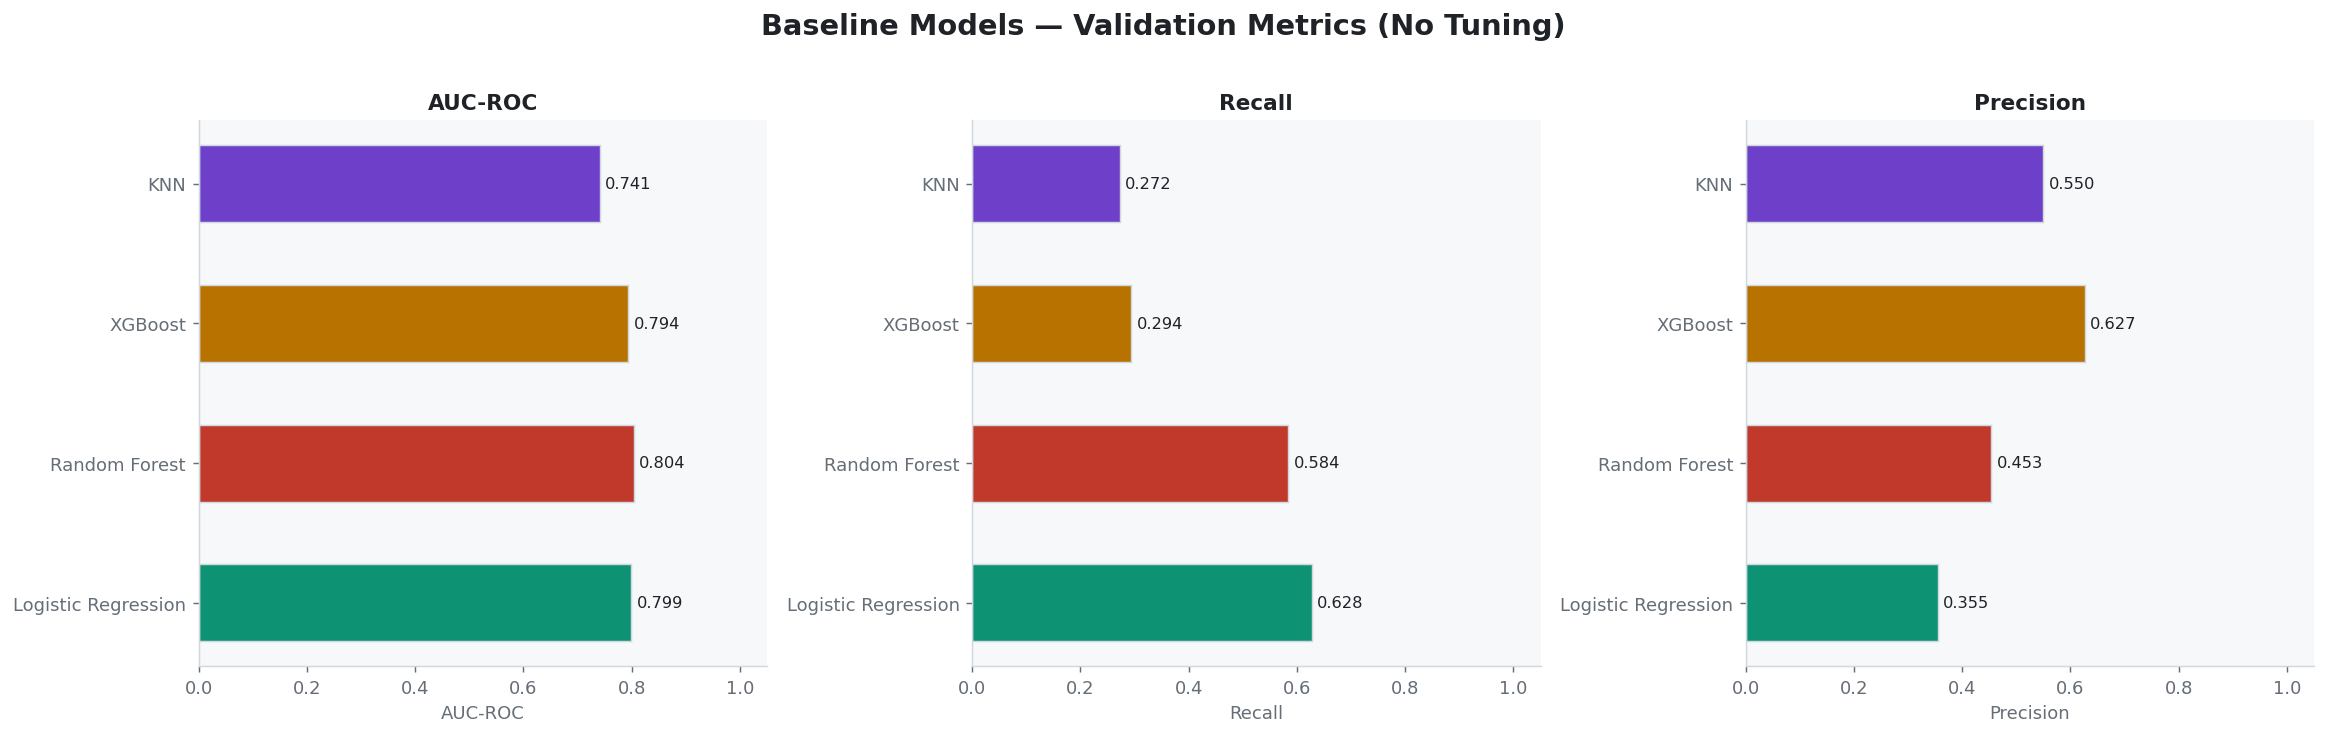

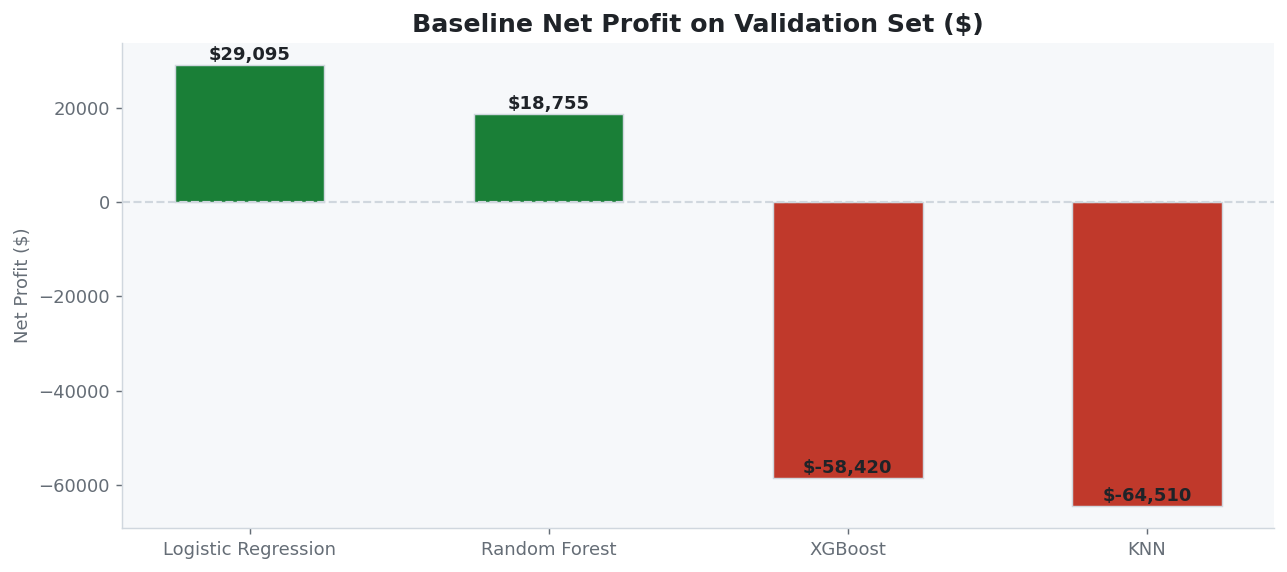

In [12]:

# ── Baseline model metric comparison ──────────────────────────────────────────
model_names = list(baseline_results.keys())
MODEL_COLORS = [P["lr"], P["rf"], P["xgb"], P["knn"]]
metrics_keys = ["val_auc", "val_recall", "val_precision"]
metric_labels = ["AUC-ROC", "Recall", "Precision"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Baseline Models — Validation Metrics (No Tuning)", fontsize=16,
             fontweight="bold", color=P["text"], y=1.02)

for ax, key, label in zip(axes, metrics_keys, metric_labels):
    vals = [baseline_results[m][key] for m in model_names]
    bars = ax.barh(model_names, vals, color=MODEL_COLORS, edgecolor=P["border"],
                   height=0.55, linewidth=0.8)
    ax.set_facecolor(P["bg2"])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(label, color=P["subtext"])
    ax.set_title(label, color=P["text"], fontweight="bold")
    ax.tick_params(colors=P["subtext"])
    for spine in ax.spines.values():
        spine.set_edgecolor(P["border"])
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", ha="left", color=P["text"], fontsize=9)

plt.tight_layout()
plt.show()

# ── Net Profit comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(P["bg"])
ax.set_facecolor(P["bg2"])
profits = [baseline_results[m]["val_net_profit"] for m in model_names]
bar_cols = [P["profit"] if p >= 0 else P["loss"] for p in profits]
bars = ax.bar(model_names, profits, color=bar_cols, edgecolor=P["border"], width=0.5, linewidth=0.8)
ax.axhline(0, color=P["border"], linewidth=1.2, linestyle="--")
ax.set_title("Baseline Net Profit on Validation Set ($)", color=P["text"],
             fontsize=14, fontweight="bold")
ax.set_ylabel("Net Profit ($)", color=P["subtext"])
ax.tick_params(colors=P["subtext"])
for spine in ax.spines.values():
    spine.set_edgecolor(P["border"])
for bar, val in zip(bars, profits):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 200,
            f"${val:,.0f}", ha="center", va="bottom",
            color=P["text"], fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()



## Section 10 — Classification Metrics: The FP/FN Business Cost Reality

A raw accuracy number hides the real story. In bank marketing:

| Outcome | Meaning | Business Cost |
|---------|---------|---------------|
| **True Positive** (TP) | Correctly identified subscriber | +$195 net revenue |
| **False Positive** (FP) | Called someone who won't subscribe | −$5 wasted call cost |
| **False Negative** (FN) | Missed a real subscriber | −$200 lost opportunity |
| **True Negative** (TN) | Correctly skipped a non-subscriber | $0 (saved resources) |

**The asymmetry is extreme:** A missed subscriber (FN) costs 40× more than a wasted call (FP).  
This means a model that maximises recall — even at the cost of precision — can still be the most profitable.


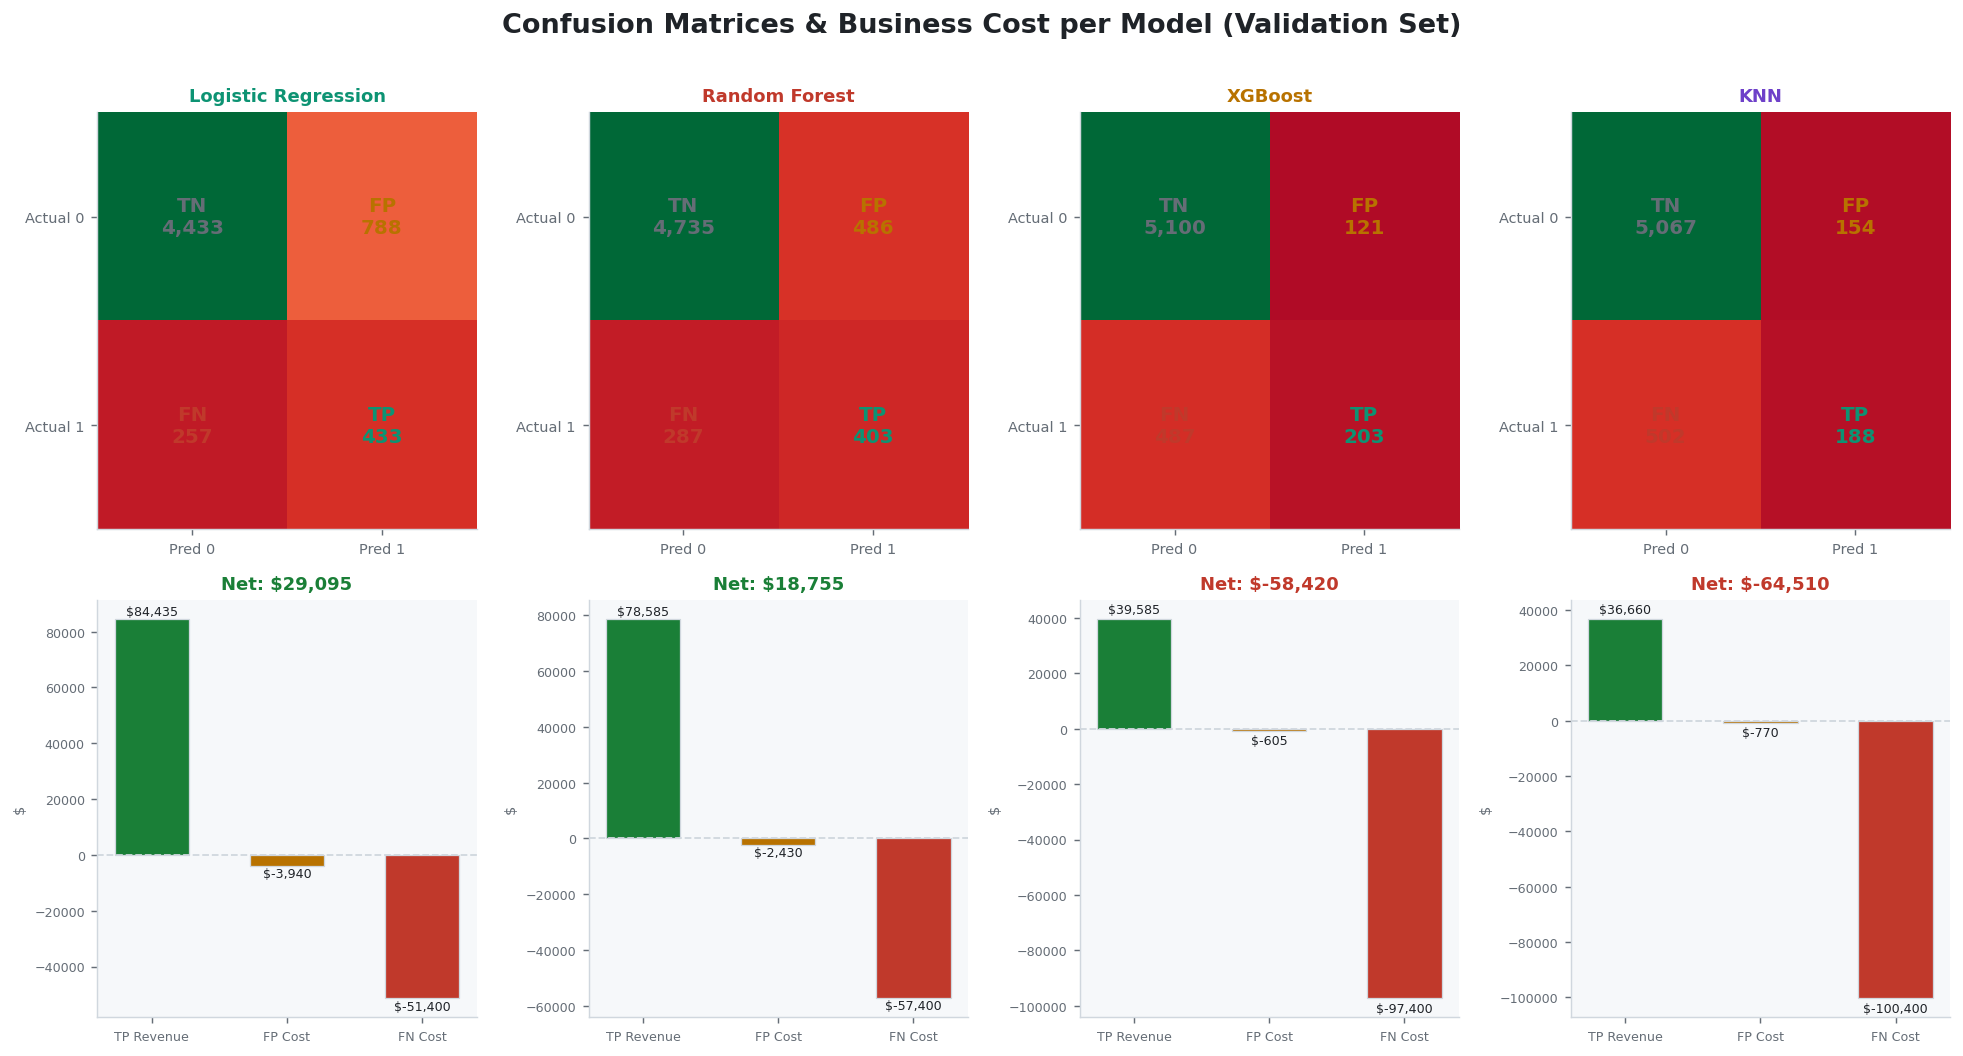

In [13]:

# ── Confusion matrices + per-model cost breakdown ─────────────────────────────
n_models = len(model_names)
fig, axes = plt.subplots(2, n_models, figsize=(n_models * 3.8, 8))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Confusion Matrices & Business Cost per Model (Validation Set)",
             fontsize=15, fontweight="bold", color=P["text"], y=1.01)

for col, (name, col_color) in enumerate(zip(model_names, MODEL_COLORS)):
    y_pred = baseline_results[name]["y_pred"]
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # ── confusion matrix heatmap
    ax_cm = axes[0][col]
    ax_cm.set_facecolor(P["bg2"])
    im = ax_cm.imshow(cm, cmap="RdYlGn", aspect="auto", vmin=0)
    labels = [["TN", "FP"], ["FN", "TP"]]
    label_colors = [[P["tn"], P["fp"]], [P["fn"], P["tp"]]]
    for r in range(2):
        for c_ in range(2):
            ax_cm.text(c_, r, f"{labels[r][c_]}\n{cm[r, c_]:,}",
                       ha="center", va="center", fontsize=11, fontweight="bold",
                       color=label_colors[r][c_])
    ax_cm.set_xticks([0, 1])
    ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(["Pred 0", "Pred 1"], color=P["subtext"], fontsize=8)
    ax_cm.set_yticklabels(["Actual 0", "Actual 1"], color=P["subtext"], fontsize=8)
    ax_cm.set_title(name, color=col_color, fontweight="bold", fontsize=10)
    for spine in ax_cm.spines.values():
        spine.set_edgecolor(P["border"])

    # ── cost bar chart below
    ax_cost = axes[1][col]
    ax_cost.set_facecolor(P["bg2"])
    costs_vals = [tp * (VALUE_TP - COST_FP), -fp * COST_FP, -fn * COST_FN]
    cost_labels = ["TP Revenue", "FP Cost", "FN Cost"]
    c_colors = [P["profit"], P["fp"], P["loss"]]
    bars = ax_cost.bar(cost_labels, costs_vals, color=c_colors,
                       edgecolor=P["border"], width=0.55, linewidth=0.7)
    ax_cost.axhline(0, color=P["border"], linewidth=1, linestyle="--")
    net = sum(costs_vals)
    ax_cost.set_title(f"Net: ${net:,.0f}", color=P["profit"] if net >= 0 else P["loss"],
                      fontsize=10, fontweight="bold")
    ax_cost.tick_params(colors=P["subtext"], labelsize=7)
    ax_cost.set_ylabel("$", color=P["subtext"], fontsize=8)
    for spine in ax_cost.spines.values():
        spine.set_edgecolor(P["border"])
    for bar_, val in zip(bars, costs_vals):
        ax_cost.text(bar_.get_x() + bar_.get_width() / 2,
                     val + (abs(net) * 0.02 * (1 if val >= 0 else -1)),
                     f"${val:,.0f}", ha="center", va="bottom" if val >= 0 else "top",
                     color=P["text"], fontsize=7)

plt.tight_layout()
plt.show()



## Section 11 — Cross-Validation: Stability Across Folds

A single train/val split can be lucky or unlucky. Stratified 5-fold CV tells us whether a model's performance is *consistent* across different data slices.

**Why it matters:** High mean + low std = trustworthy. High mean + high std = possibly overfit to a specific subset.


Model                    AUC mean   AUC std   Recall mean  Recall std
────────────────────────────────────────────────────────────────────
  Logistic Regression      0.7920    0.0075        0.6338      0.0193
  Random Forest            0.7989    0.0062        0.5716      0.0179
  XGBoost                  0.7958    0.0029        0.2712      0.0119
  KNN                      0.7376    0.0069        0.2587      0.0052
────────────────────────────────────────────────────────────────────


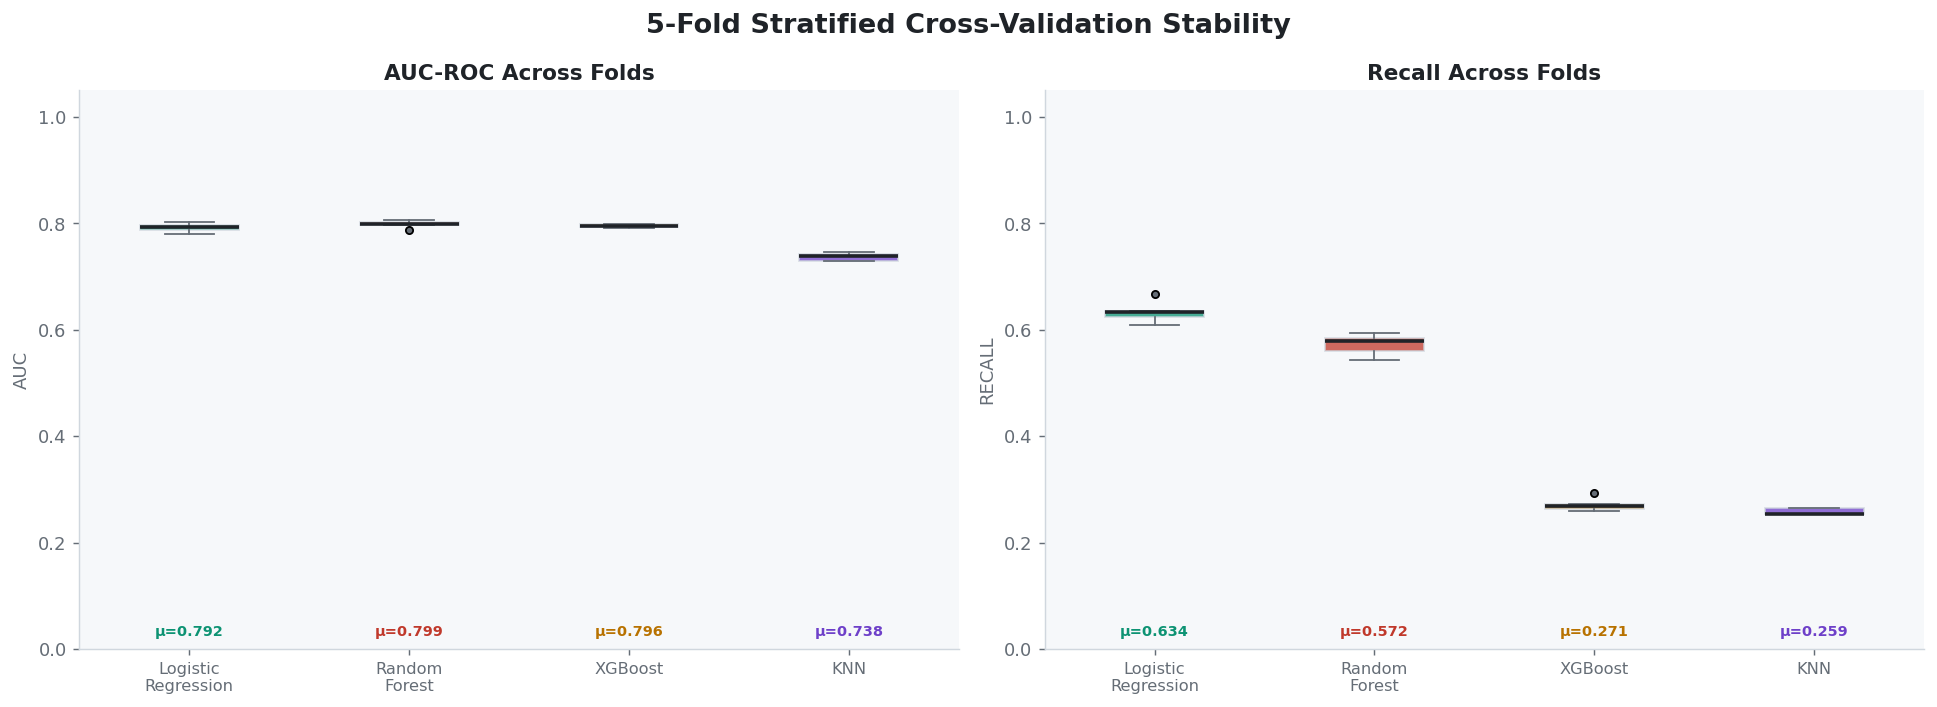

In [14]:

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use train+val combined for CV (X_train + X_val)
X_cv = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_cv = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = {}
print(f"{'Model':<22} {'AUC mean':>10} {'AUC std':>9} {'Recall mean':>13} {'Recall std':>11}")
print("─" * 68)

for name, clf in BASELINE_MODELS.items():
    pipe = make_pipeline(clf)
    auc_scores  = cross_val_score(pipe, X_cv, y_cv, cv=skf, scoring="roc_auc", n_jobs=-1)
    rec_scores  = cross_val_score(pipe, X_cv, y_cv, cv=skf, scoring="recall", n_jobs=-1)
    cv_scores[name] = {"auc": auc_scores, "recall": rec_scores}
    print(f"  {name:<20} {auc_scores.mean():>10.4f} {auc_scores.std():>9.4f} "
          f"{rec_scores.mean():>13.4f} {rec_scores.std():>11.4f}")

print("─" * 68)

# ── Boxplot of CV AUC scores ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("5-Fold Stratified Cross-Validation Stability", fontsize=15,
             fontweight="bold", color=P["text"])

for ax, metric, title in [(ax1, "auc", "AUC-ROC Across Folds"),
                          (ax2, "recall", "Recall Across Folds")]:
    ax.set_facecolor(P["bg2"])
    data   = [cv_scores[m][metric] for m in model_names]
    means_ = [d.mean() for d in data]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops={"color": P["text"], "linewidth": 2},
                    whiskerprops={"color": P["subtext"]},
                    capprops={"color": P["subtext"]},
                    flierprops={"markerfacecolor": P["subtext"], "markersize": 4})
    for patch, col in zip(bp["boxes"], MODEL_COLORS):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)
        patch.set_edgecolor(P["border"])
    ax.set_xticklabels([m.replace(" ", "\n") for m in model_names],
                       color=P["subtext"], fontsize=9)
    ax.set_title(title, color=P["text"], fontweight="bold")
    ax.set_ylabel(metric.upper(), color=P["subtext"])
    ax.tick_params(colors=P["subtext"])
    ax.set_ylim(0, 1.05)
    for spine in ax.spines.values():
        spine.set_edgecolor(P["border"])
    for i, (mean_v, col) in enumerate(zip(means_, MODEL_COLORS), start=1):
        ax.text(i, 0.02, f"μ={mean_v:.3f}", ha="center", va="bottom",
                color=col, fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()



## Section 12 — Full Model Comparison Table

All five models benchmarked head-to-head on the same validation split. The "winner" will be determined not by a single metric but by a composite of AUC, recall, and **net profit** — reflecting real business priorities.


                     AUC-ROC  Avg Precision  Recall  Precision      F1   TP   FP   FN    TN  Net Profit ($)
Model                                                                                                      
Logistic Regression   0.7993         0.4558  0.6275     0.3546  0.4532  433  788  257  4433           29095
Random Forest         0.8040         0.4760  0.5841     0.4533  0.5104  403  486  287  4735           18755
XGBoost               0.7937         0.4705  0.2942     0.6265  0.4004  203  121  487  5100          -58420
KNN                   0.7408         0.3515  0.2725     0.5497  0.3643  188  154  502  5067          -64510


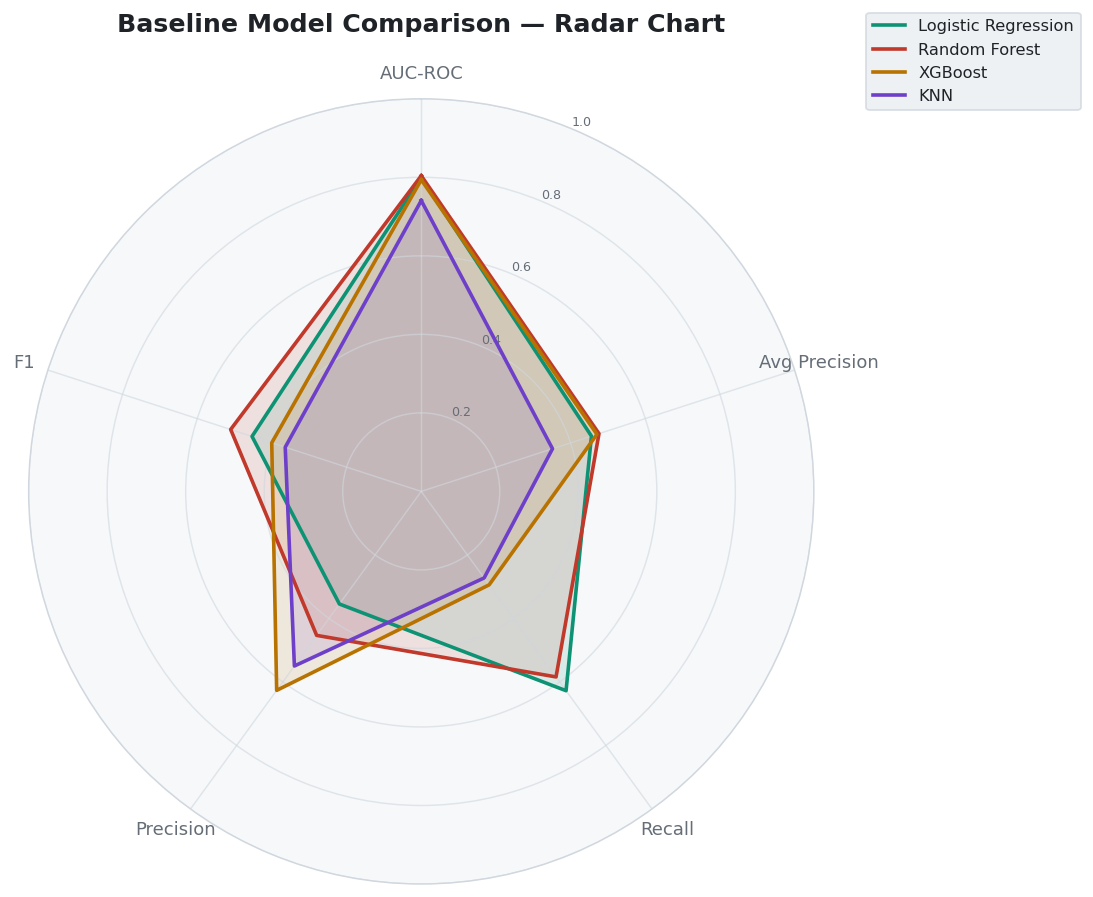

In [15]:

from sklearn.metrics import f1_score, average_precision_score

# Build summary dataframe
rows = []
for name in model_names:
    r   = baseline_results[name]
    yp  = r["y_pred"]
    ypr = r["y_prob"]
    tn, fp, fn, tp_cnt = confusion_matrix(y_val, yp).ravel()
    rows.append({
        "Model": name,
        "AUC-ROC": round(r["val_auc"], 4),
        "Avg Precision": round(average_precision_score(y_val, ypr), 4),
        "Recall": round(r["val_recall"], 4),
        "Precision": round(r["val_precision"], 4),
        "F1": round(f1_score(y_val, yp, zero_division=0), 4),
        "TP": int(tp_cnt), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "Net Profit ($)": int(r["val_net_profit"]),
    })

summary_df = pd.DataFrame(rows).set_index("Model")
print(summary_df.to_string())

# ── Radar / spider chart ───────────────────────────────────────────────────────
from matplotlib.patches import FancyBboxPatch
import numpy as np

radar_metrics = ["AUC-ROC", "Avg Precision", "Recall", "Precision", "F1"]
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"polar": True})
fig.patch.set_facecolor(P["bg"])
ax.set_facecolor(P["bg2"])
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, color=P["subtext"], fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], color=P["subtext"], fontsize=7)
ax.grid(color=P["border"], linewidth=0.8)
ax.spines["polar"].set_color(P["border"])

for name, col in zip(model_names, MODEL_COLORS):
    vals = [summary_df.loc[name, m] for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, color=col, linewidth=2, label=name)
    ax.fill(angles, vals, color=col, alpha=0.12)

ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12),
          facecolor=P["bg3"], edgecolor=P["border"],
          labelcolor=P["text"], fontsize=9)
ax.set_title("Baseline Model Comparison — Radar Chart", color=P["text"],
             fontsize=14, fontweight="bold", pad=18)
plt.tight_layout()
plt.show()



## Section 13 — Hyperparameter Tuning with Optuna

Default parameters are a starting point, not an endpoint. **Optuna** uses Tree-structured Parzen Estimators (TPE) to intelligently sample hyperparameter combinations — far more efficient than exhaustive grid search.

Tuning objective: **maximise AUC-ROC** on a 3-fold stratified CV inside the training set.  
We tune Logistic Regression, Random Forest, XGBoost, and KNN (50 trials each for speed; production uses 150+).


In [16]:

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50
CV_FOLDS = 3
inner_cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

def objective_lr(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 10, log=True),
        "solver": trial.suggest_categorical("solver", ["saga", "lbfgs"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "max_iter": 2000,
        "random_state": SEED,
    }
    clf = LogisticRegression(**params)
    scores = cross_val_score(make_pipeline(clf), X_train, y_train,
                             cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "class_weight": "balanced",
        "random_state": SEED,
        "n_jobs": -1,
    }
    clf = RandomForestClassifier(**params)
    scores = cross_val_score(make_pipeline(clf), X_train, y_train,
                             cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 15.0),
        "random_state": SEED,
        "eval_metric": "aucpr",
        "verbosity": 0,
        "n_jobs": -1,
    }
    clf = XGBClassifier(**params)
    scores = cross_val_score(make_pipeline(clf), X_train, y_train,
                             cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 60),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan"]),
        "n_jobs": -1,
    }
    clf = KNeighborsClassifier(**params)
    scores = cross_val_score(make_pipeline(clf), X_train, y_train,
                             cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

tuning_objectives = {
    "Logistic Regression": (objective_lr, LogisticRegression),
    "Random Forest":       (objective_rf, RandomForestClassifier),
    "XGBoost":             (objective_xgb, XGBClassifier),
    "KNN":                 (objective_knn, KNeighborsClassifier),
}

best_params = {}
study_histories = {}

for name, (obj_fn, _) in tuning_objectives.items():
    print(f"  Tuning {name} ({N_TRIALS} trials)...", end=" ", flush=True)
    t0 = time.time()
    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
    study.optimize(obj_fn, n_trials=N_TRIALS, show_progress_bar=False)
    elapsed = time.time() - t0
    best_params[name] = study.best_params
    study_histories[name] = [t.value for t in study.trials]
    print(f"best AUC={study.best_value:.4f}  ({elapsed:.1f}s)")

print("\nBest hyperparameters found:")
for name, params in best_params.items():
    print(f"\n  {name}: {params}")


  Tuning Logistic Regression (50 trials)... best AUC=0.7914  (70.2s)
  Tuning Random Forest (50 trials)... best AUC=0.8014  (121.4s)
  Tuning XGBoost (50 trials)... best AUC=0.8007  (177.9s)
  Tuning KNN (50 trials)... best AUC=0.7833  (267.1s)

Best hyperparameters found:

  Logistic Regression: {'C': 0.30469215814136036, 'solver': 'lbfgs', 'class_weight': 'balanced'}

  Random Forest: {'n_estimators': 547, 'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 7}

  XGBoost: {'n_estimators': 190, 'max_depth': 7, 'learning_rate': 0.009679320187242439, 'subsample': 0.6050803641223266, 'colsample_bytree': 0.7874820875551369, 'scale_pos_weight': 4.842789625954733}

  KNN: {'n_neighbors': 60, 'weights': 'uniform', 'metric': 'manhattan'}



## Section 14 — Before vs After Hyperparameter Tuning

We now rebuild all four models using the Optuna-discovered hyperparameters and measure the improvement on the validation set. Decision Tree is excluded from tuning (it serves as a baseline reference).


Model                   Before AUC  After AUC   Δ AUC  Before Recall  After Recall  Δ Recall
────────────────────────────────────────────────────────────────────────────────────────
  Logistic Regression       0.7993     0.7994 +0.0000         0.6275        0.6275 + 0.0000
  Random Forest             0.8040     0.8085 +0.0045         0.5841        0.6188 + 0.0348
  XGBoost                   0.7937     0.8090 +0.0153         0.2942        0.5754 + 0.2812
  KNN                       0.7408     0.7823 +0.0414         0.2725        0.2174 -0.0551
────────────────────────────────────────────────────────────────────────────────────────


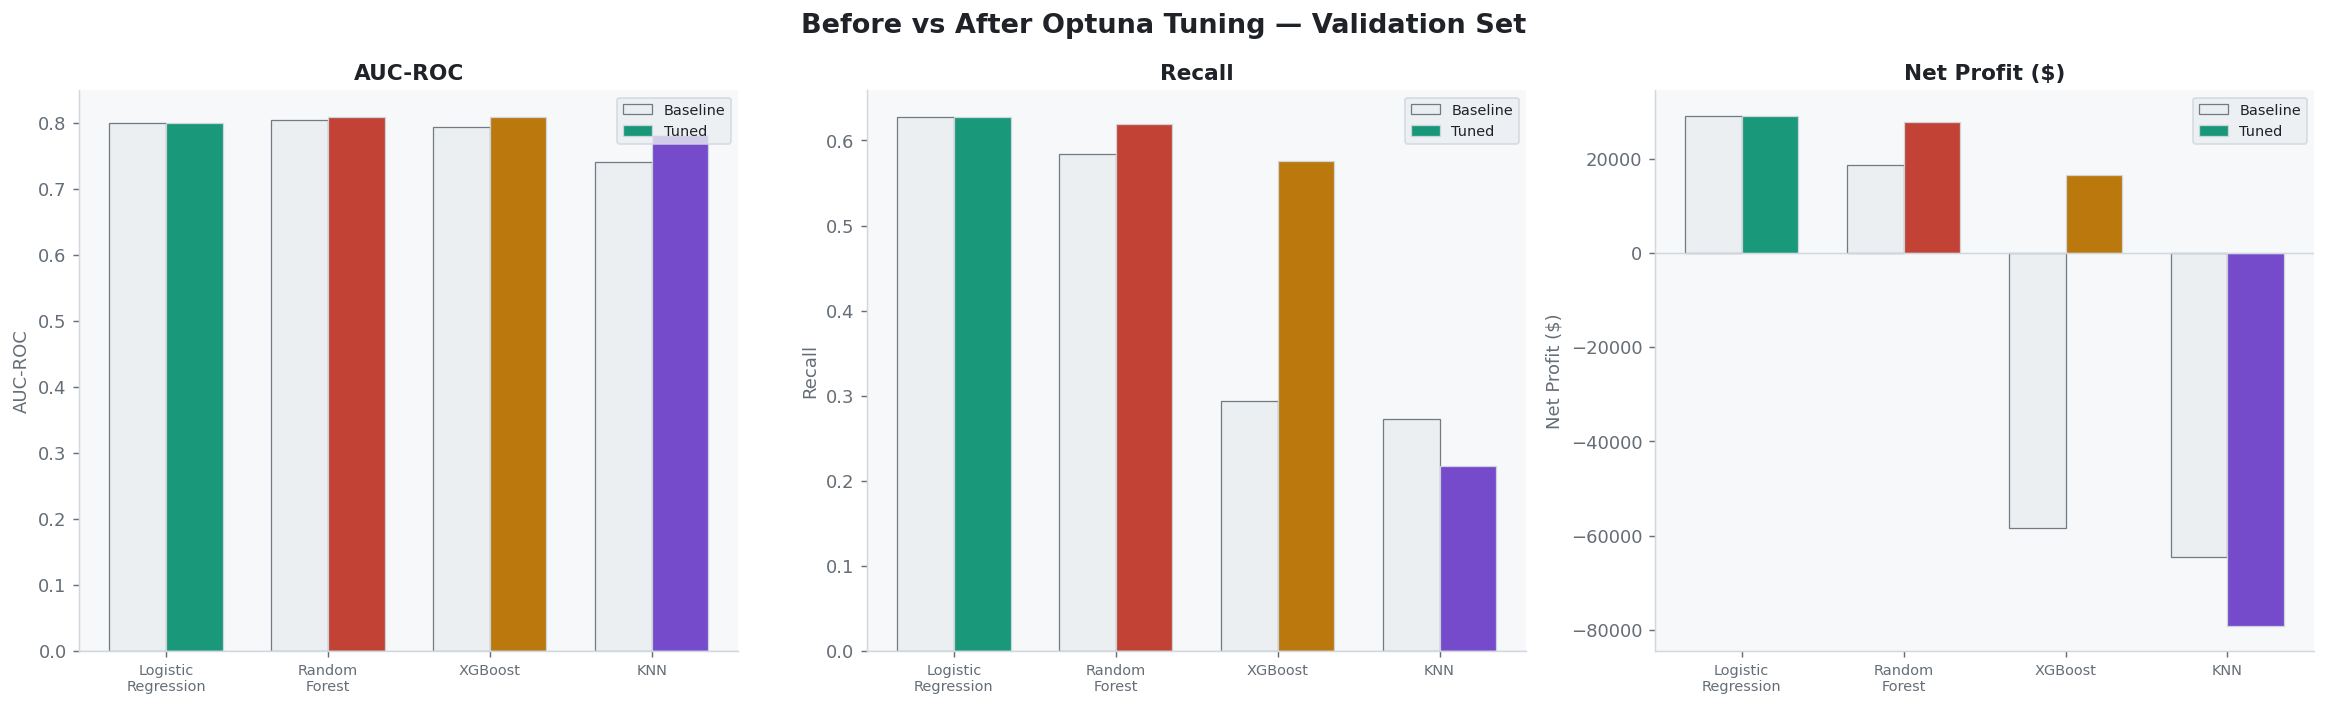

In [17]:

# ── Build tuned model instances ───────────────────────────────────────────────
def build_tuned(name, params):
    if name == "Logistic Regression":
        return LogisticRegression(**params, max_iter=2000, random_state=SEED)
    elif name == "Random Forest":
        return RandomForestClassifier(**params, class_weight="balanced",
                                     random_state=SEED, n_jobs=-1)
    elif name == "XGBoost":
        return XGBClassifier(**params, random_state=SEED, verbosity=0, n_jobs=-1)
    elif name == "KNN":
        return KNeighborsClassifier(**params, n_jobs=-1)

tuned_results = {}
tune_names = list(tuning_objectives.keys())
tune_colors = [P["lr"], P["rf"], P["xgb"], P["knn"]]

print(f"{'Model':<22} {'Before AUC':>11} {'After AUC':>10} {'Δ AUC':>7} "
      f"{'Before Recall':>14} {'After Recall':>13} {'Δ Recall':>9}")
print("─" * 88)

for name in tune_names:
    clf_tuned = build_tuned(name, best_params[name])
    pipe_tuned = make_pipeline(clf_tuned)
    pipe_tuned.fit(X_train, y_train)
    y_prob_t = pipe_tuned.predict_proba(X_val)[:, 1]
    y_pred_t = pipe_tuned.predict(X_val)
    auc_t = roc_auc_score(y_val, y_prob_t)
    rec_t = recall_score(y_val, y_pred_t, zero_division=0)
    pre_t = precision_score(y_val, y_pred_t, zero_division=0)
    np_t  = net_profit(y_val, y_pred_t)
    tuned_results[name] = {
        "pipeline": pipe_tuned, "y_prob": y_prob_t, "y_pred": y_pred_t,
        "val_auc": auc_t, "val_recall": rec_t, "val_precision": pre_t,
        "val_net_profit": np_t
    }
    b_auc = baseline_results[name]["val_auc"]
    b_rec = baseline_results[name]["val_recall"]
    d_auc = auc_t - b_auc
    d_rec = rec_t - b_rec
    print(f"  {name:<20} {b_auc:>11.4f} {auc_t:>10.4f} "
          f"{('+' if d_auc>=0 else '')}{d_auc:>5.4f} "
          f"{b_rec:>14.4f} {rec_t:>13.4f} "
          f"{('+' if d_rec>=0 else '')}{d_rec:>7.4f}")

print("─" * 88)

# ── Before vs After grouped bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Before vs After Optuna Tuning — Validation Set", fontsize=15,
             fontweight="bold", color=P["text"])

comparison_keys = ["val_auc", "val_recall", "val_net_profit"]
comparison_labels = ["AUC-ROC", "Recall", "Net Profit ($)"]
x = np.arange(len(tune_names))
width = 0.35

for ax, key, label in zip(axes, comparison_keys, comparison_labels):
    ax.set_facecolor(P["bg2"])
    before_vals = [baseline_results[n][key] for n in tune_names]
    after_vals  = [tuned_results[n][key]    for n in tune_names]
    bars1 = ax.bar(x - width / 2, before_vals, width, label="Baseline",
                   color=P["bg3"], edgecolor=P["subtext"], linewidth=0.7, alpha=0.9)
    bars2 = ax.bar(x + width / 2, after_vals, width, label="Tuned",
                   color=tune_colors, edgecolor=P["border"], linewidth=0.7, alpha=0.95)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(" ", "\n") for n in tune_names],
                       color=P["subtext"], fontsize=8)
    ax.set_title(label, color=P["text"], fontweight="bold")
    ax.set_ylabel(label, color=P["subtext"])
    ax.tick_params(colors=P["subtext"])
    ax.legend(facecolor=P["bg3"], edgecolor=P["border"],
              labelcolor=P["text"], fontsize=8)
    ax.axhline(0, color=P["border"], linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_edgecolor(P["border"])

plt.tight_layout()
plt.show()



## Section 15 — Recall Analysis: Precision-Recall Curves

In imbalanced classification, the AUC-ROC metric can be misleading. The **Precision-Recall (PR) curve** is more informative: it focuses entirely on positive-class performance.

A high **Average Precision (AP)** score means the model consistently identifies true subscribers at high recall levels without flooding the list with false positives.


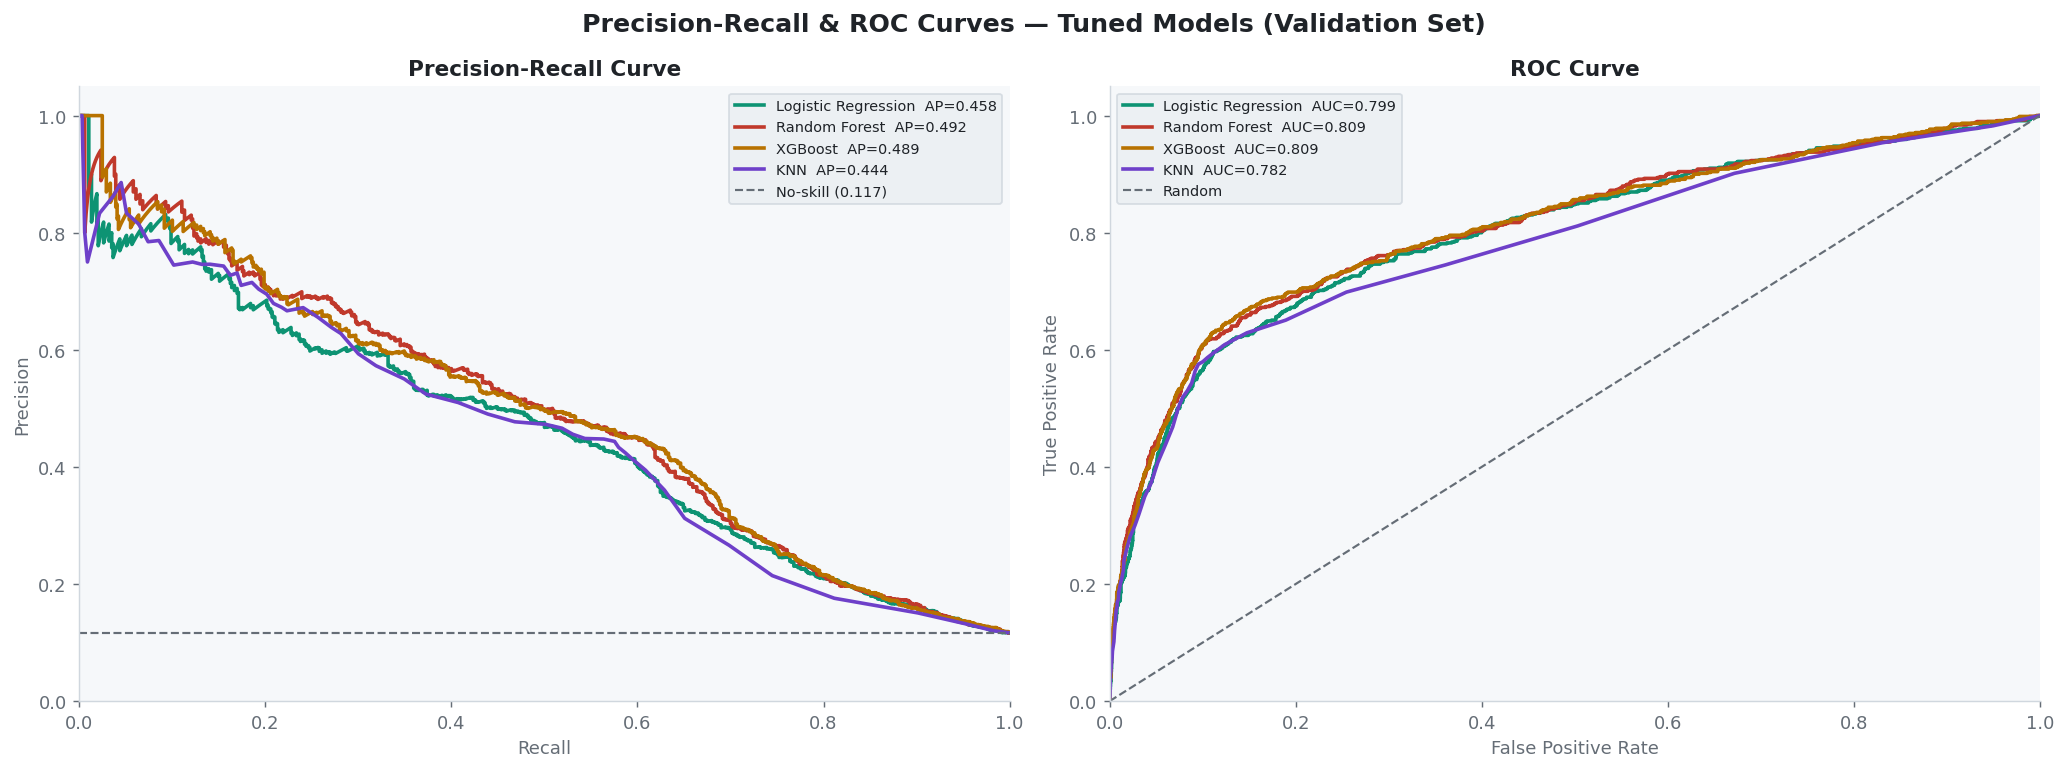

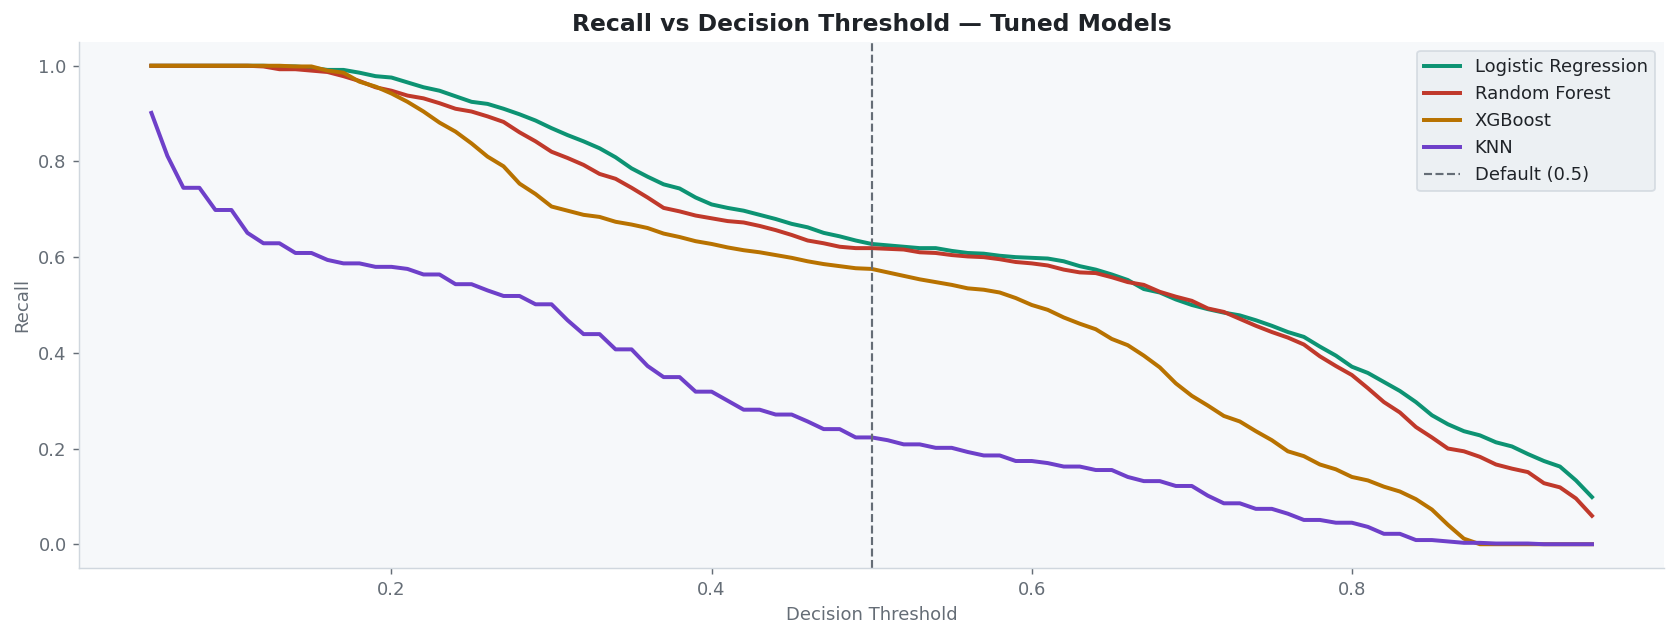

In [18]:

from sklearn.metrics import precision_recall_curve, roc_curve

fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Precision-Recall & ROC Curves — Tuned Models (Validation Set)",
             fontsize=14, fontweight="bold", color=P["text"])

for ax in (ax_pr, ax_roc):
    ax.set_facecolor(P["bg2"])
    for spine in ax.spines.values():
        spine.set_edgecolor(P["border"])
    ax.tick_params(colors=P["subtext"])

for name, col in zip(tune_names, tune_colors):
    y_prob = tuned_results[name]["y_prob"]
    # PR curve
    prec, rec, _ = precision_recall_curve(y_val, y_prob)
    ap = average_precision_score(y_val, y_prob)
    ax_pr.plot(rec, prec, color=col, lw=2, label=f"{name}  AP={ap:.3f}")
    # ROC curve
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score = roc_auc_score(y_val, y_prob)
    ax_roc.plot(fpr, tpr, color=col, lw=2, label=f"{name}  AUC={auc_score:.3f}")

baseline_pos_rate = y_val.mean()
ax_pr.axhline(baseline_pos_rate, linestyle="--", color=P["subtext"], lw=1.2,
              label=f"No-skill ({baseline_pos_rate:.3f})")
ax_pr.set_xlabel("Recall", color=P["subtext"])
ax_pr.set_ylabel("Precision", color=P["subtext"])
ax_pr.set_title("Precision-Recall Curve", color=P["text"], fontweight="bold")
ax_pr.legend(facecolor=P["bg3"], edgecolor=P["border"], labelcolor=P["text"], fontsize=8)
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)

ax_roc.plot([0, 1], [0, 1], linestyle="--", color=P["subtext"], lw=1.2, label="Random")
ax_roc.set_xlabel("False Positive Rate", color=P["subtext"])
ax_roc.set_ylabel("True Positive Rate", color=P["subtext"])
ax_roc.set_title("ROC Curve", color=P["text"], fontweight="bold")
ax_roc.legend(facecolor=P["bg3"], edgecolor=P["border"], labelcolor=P["text"], fontsize=8)
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# ── Recall vs threshold for each tuned model ──────────────────────────────────
thresholds_sweep = np.linspace(0.05, 0.95, 91)

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(P["bg"])
ax.set_facecolor(P["bg2"])

for name, col in zip(tune_names, tune_colors):
    y_prob = tuned_results[name]["y_prob"]
    recalls = [recall_score(y_val, (y_prob >= t).astype(int), zero_division=0)
               for t in thresholds_sweep]
    ax.plot(thresholds_sweep, recalls, color=col, lw=2.2, label=name)

ax.axvline(0.5, color=P["subtext"], linestyle="--", lw=1.2, label="Default (0.5)")
ax.set_xlabel("Decision Threshold", color=P["subtext"])
ax.set_ylabel("Recall", color=P["subtext"])
ax.set_title("Recall vs Decision Threshold — Tuned Models", color=P["text"],
             fontsize=13, fontweight="bold")
ax.legend(facecolor=P["bg3"], edgecolor=P["border"], labelcolor=P["text"])
ax.tick_params(colors=P["subtext"])
for spine in ax.spines.values():
    spine.set_edgecolor(P["border"])
plt.tight_layout()
plt.show()



## Section 16 — Loss Calculation: Before and After Tuning

Each misclassification has an identifiable dollar impact. We decompose total campaign economics into four components:

- **TP Revenue** = (subscribers correctly identified) × ($200 value − $5 call cost)  
- **FP Cost** = (non-subscribers called) × $5  
- **FN Loss** = (subscribers missed) × $200 opportunity cost  
- **Net Profit** = TP Revenue − FP Cost − FN Loss

Comparing baseline vs tuned reveals which model improvements translate into real financial gains.


                     Baseline Net  Tuned Net  Δ Net Profit
Model                                                     
Logistic Regression         29095      29090            -5
Random Forest               18755      27800          9045
XGBoost                    -58420      16490         74910
KNN                        -64510     -79115        -14605


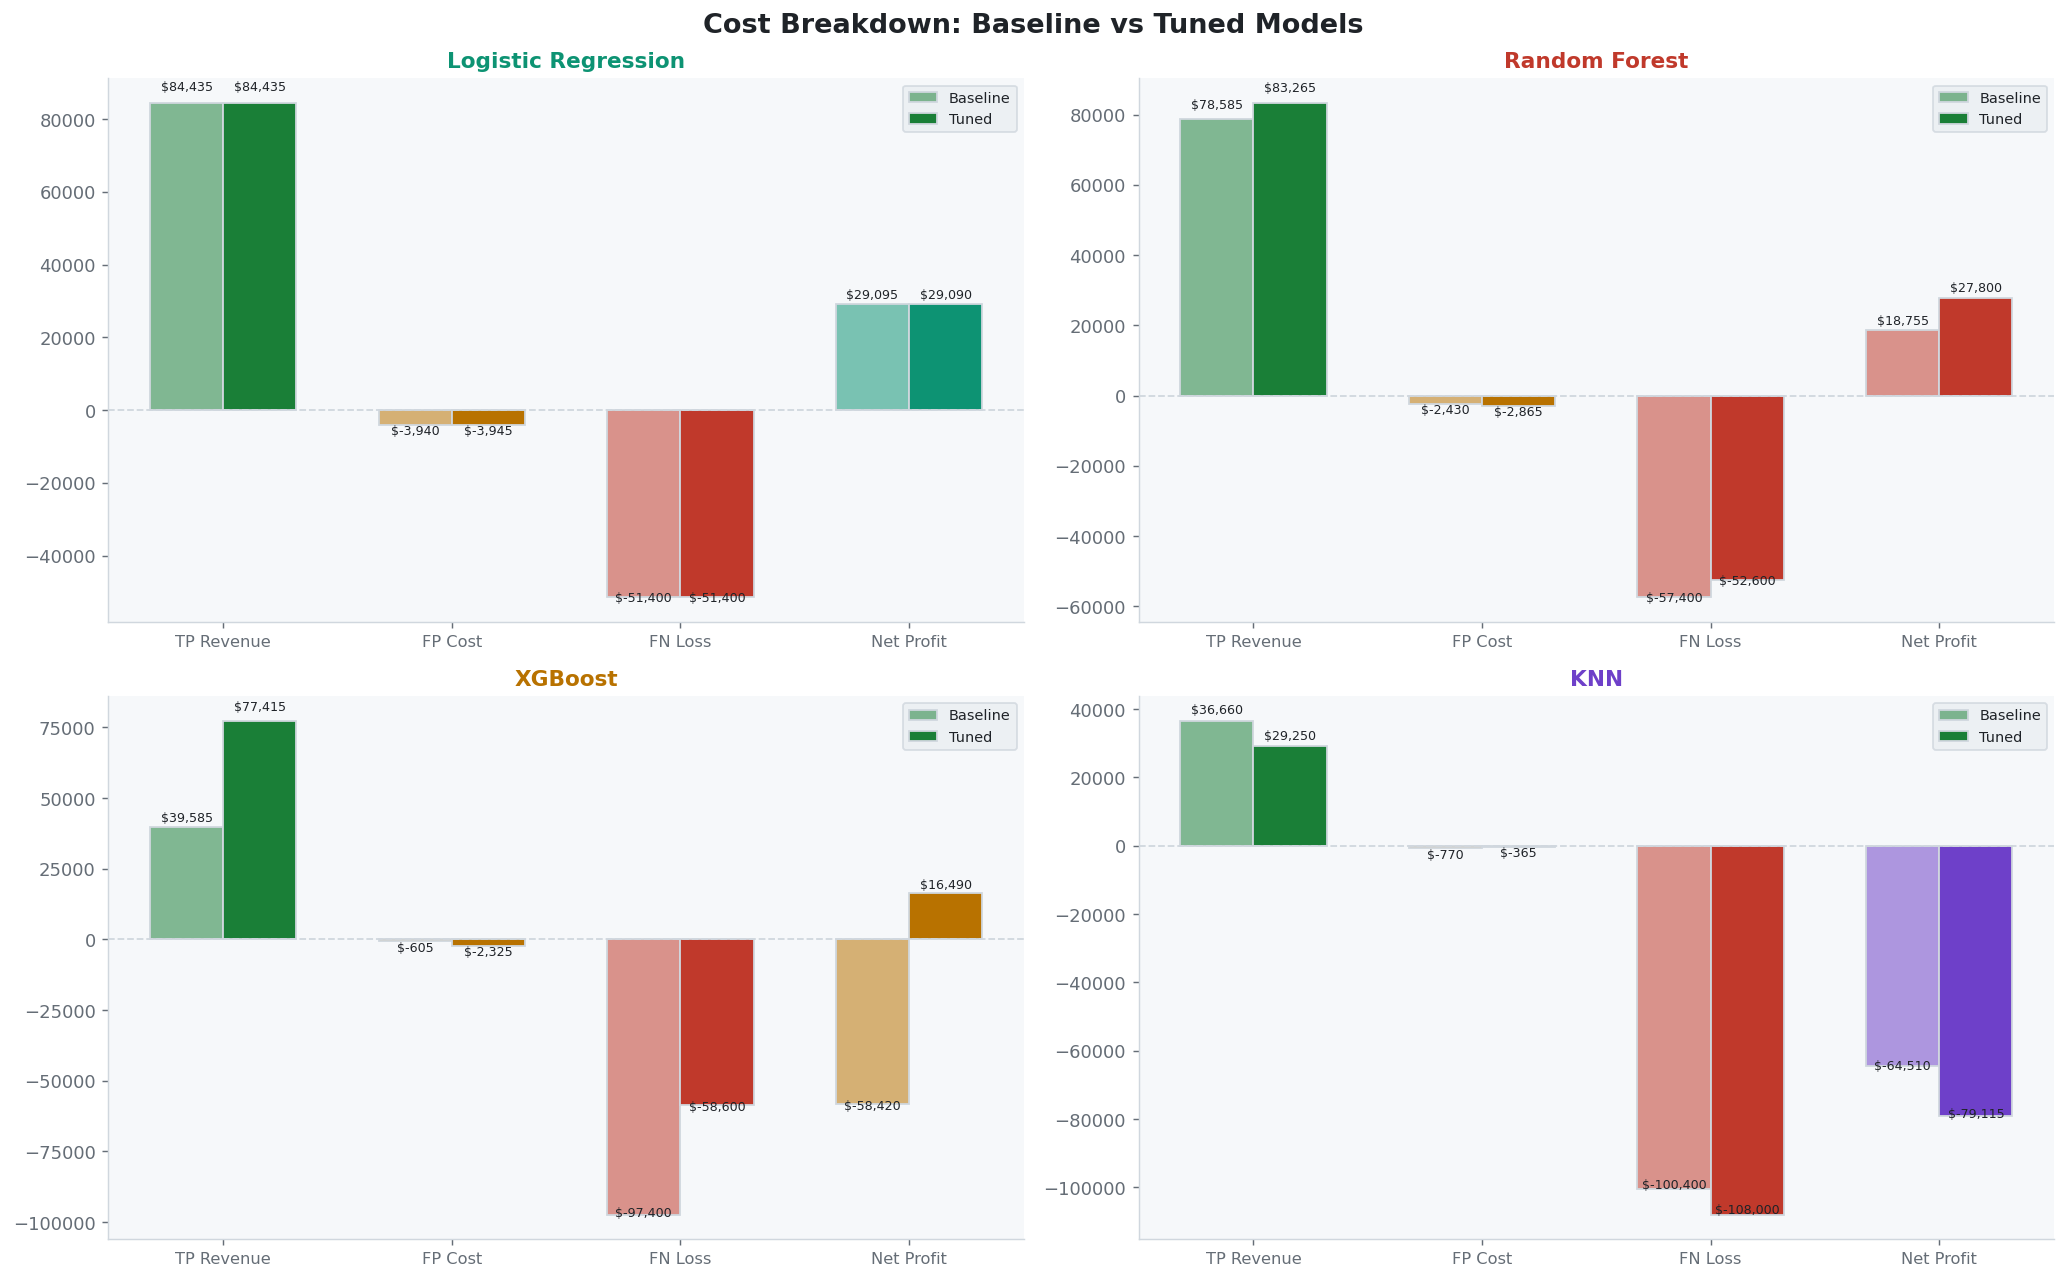

In [19]:

def compute_cost_breakdown(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tp_rev = tp * (VALUE_TP - COST_FP)
    fp_cost = fp * COST_FP
    fn_cost = fn * COST_FN
    net = tp_rev - fp_cost - fn_cost
    return {"TP Revenue": tp_rev, "FP Cost": -fp_cost,
            "FN Loss": -fn_cost, "Net Profit": net,
            "TP": int(tp), "FP": int(fp), "FN": int(fn)}

loss_rows = []
for name in tune_names:
    b = compute_cost_breakdown(y_val, baseline_results[name]["y_pred"])
    t = compute_cost_breakdown(y_val, tuned_results[name]["y_pred"])
    loss_rows.append({
        "Model": name,
        "Baseline TP Rev": b["TP Revenue"], "Tuned TP Rev": t["TP Revenue"],
        "Baseline FP Cost": b["FP Cost"],   "Tuned FP Cost": t["FP Cost"],
        "Baseline FN Loss": b["FN Loss"],   "Tuned FN Loss": t["FN Loss"],
        "Baseline Net": b["Net Profit"],    "Tuned Net": t["Net Profit"],
        "Δ Net Profit": t["Net Profit"] - b["Net Profit"],
    })

loss_df = pd.DataFrame(loss_rows).set_index("Model")
print(loss_df[["Baseline Net", "Tuned Net", "Δ Net Profit"]].to_string())

# ── Grouped waterfall-style bars ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Cost Breakdown: Baseline vs Tuned Models", fontsize=15,
             fontweight="bold", color=P["text"])

for ax, (name, col) in zip(axes.flatten(), zip(tune_names, tune_colors)):
    ax.set_facecolor(P["bg2"])
    b = compute_cost_breakdown(y_val, baseline_results[name]["y_pred"])
    t = compute_cost_breakdown(y_val, tuned_results[name]["y_pred"])
    categories = ["TP Revenue", "FP Cost", "FN Loss", "Net Profit"]
    b_vals = [b[k] for k in categories]
    t_vals = [t[k] for k in categories]
    x = np.arange(len(categories))
    w = 0.32
    c_colors = [P["profit"], P["fp"], P["loss"], col]
    bars_b = ax.bar(x - w / 2, b_vals, w, color=[c + "88" for c in c_colors],
                    edgecolor=P["border"], label="Baseline")
    bars_t = ax.bar(x + w / 2, t_vals, w, color=c_colors,
                    edgecolor=P["border"], label="Tuned")
    ax.axhline(0, color=P["border"], linewidth=1, linestyle="--")
    ax.set_xticks(x); ax.set_xticklabels(categories, color=P["subtext"], fontsize=9)
    ax.set_title(name, color=col, fontweight="bold", fontsize=12)
    ax.tick_params(colors=P["subtext"])
    for spine in ax.spines.values():
        spine.set_edgecolor(P["border"])
    ax.legend(facecolor=P["bg3"], edgecolor=P["border"],
              labelcolor=P["text"], fontsize=8)
    for bars in [bars_b, bars_t]:
        for bar_ in bars:
            h = bar_.get_height()
            ax.text(bar_.get_x() + bar_.get_width() / 2, h + abs(h) * 0.03,
                    f"${h:,.0f}", ha="center", va="bottom" if h >= 0 else "top",
                    color=P["text"], fontsize=7)

plt.tight_layout()
plt.show()



## Section 17 — Threshold Optimisation

The default 0.5 decision threshold was designed for balanced classes. Our dataset is 88/12 imbalanced, so lowering the threshold flags more customers as potential subscribers — increasing recall at the cost of precision.

We sweep thresholds from 0.05 to 0.50 for each tuned model and find the point that **maximises net profit** on the validation set.


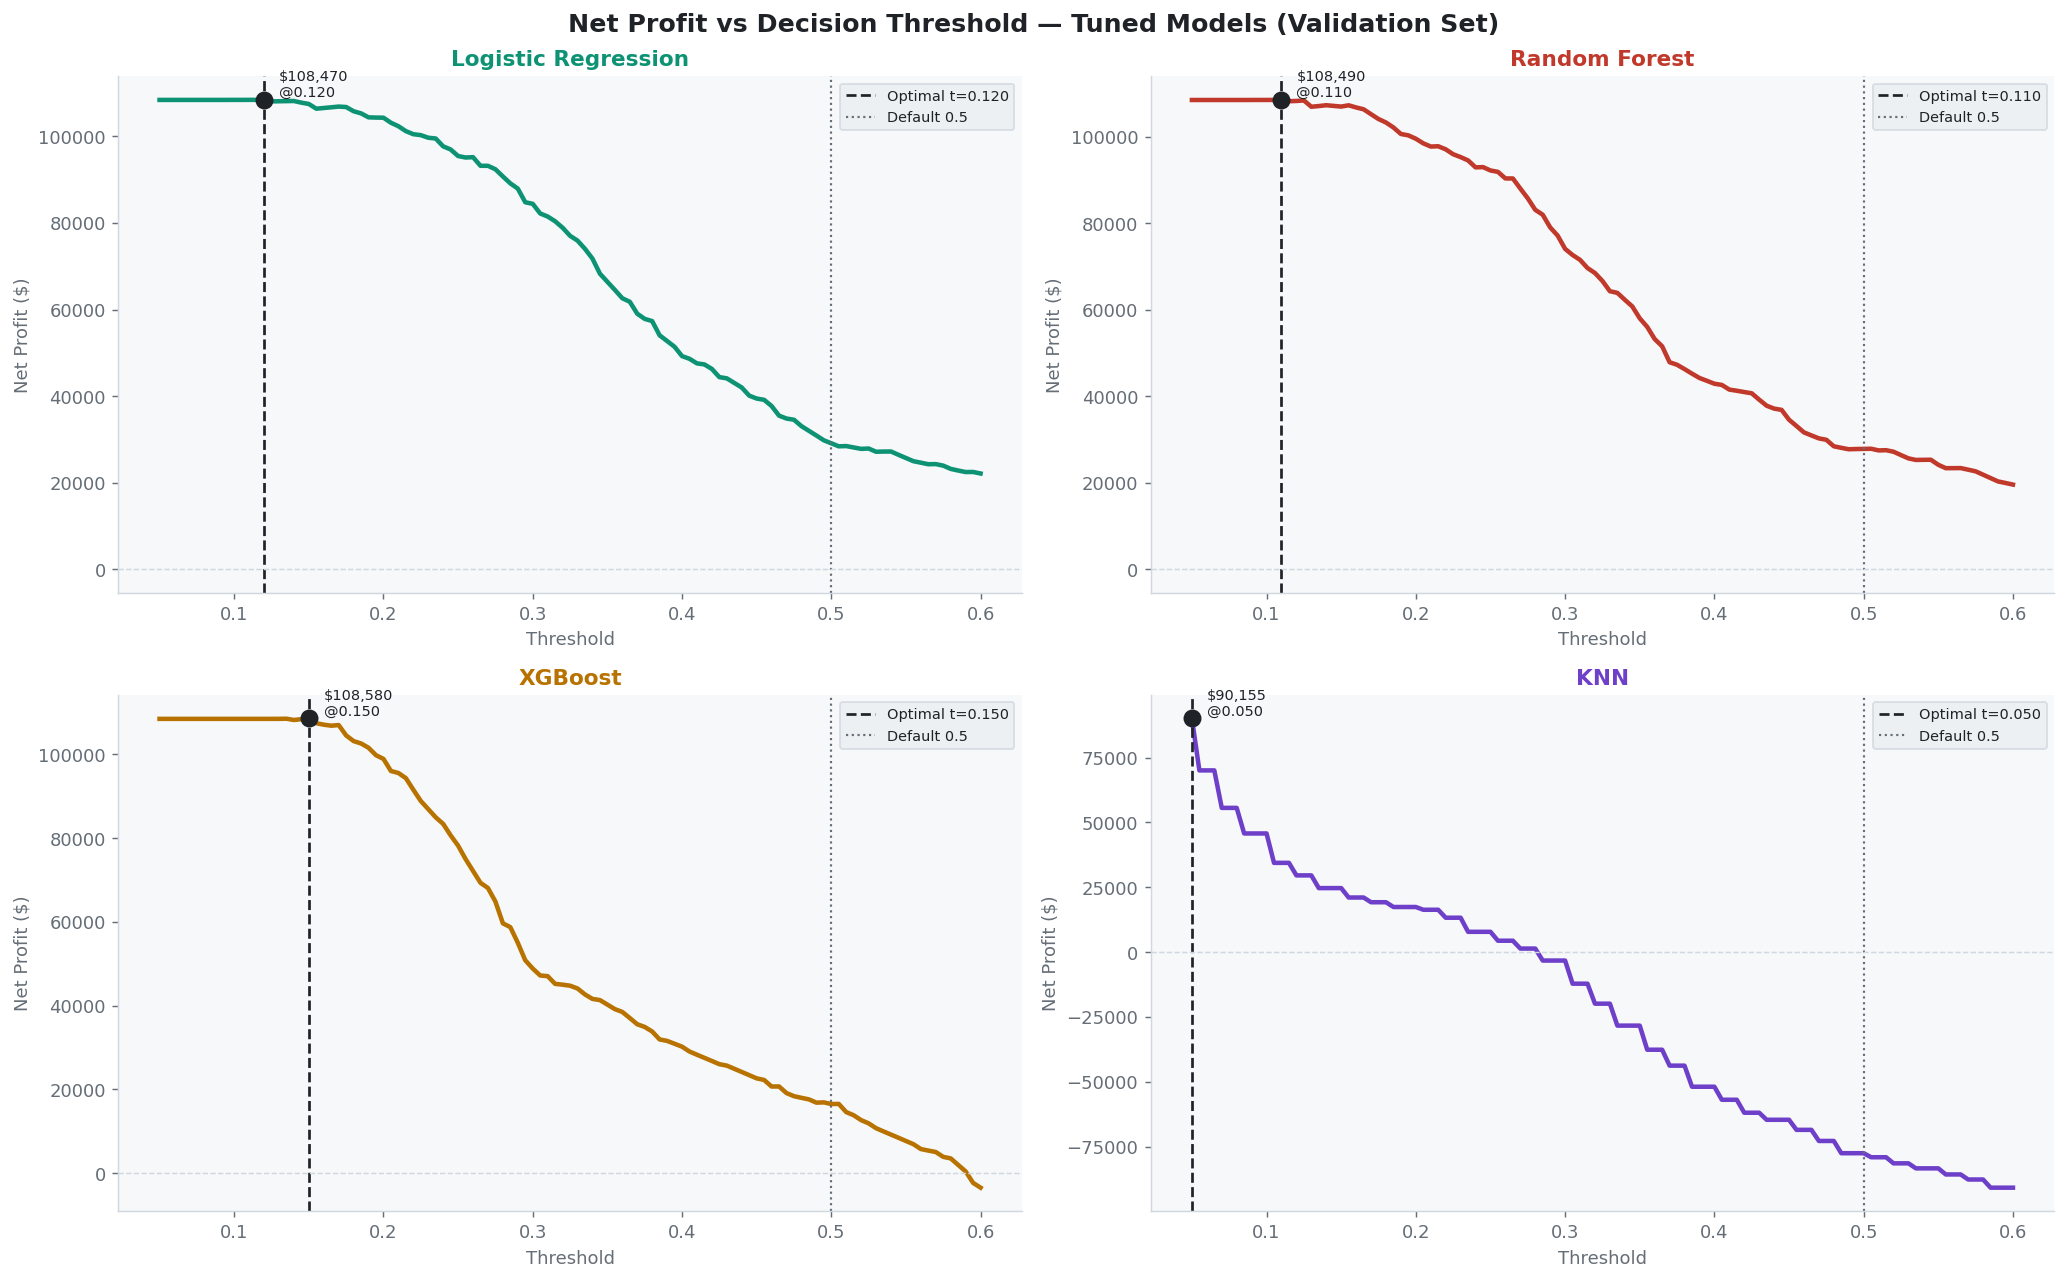


Optimal Thresholds Found:
Model                   Optimal Threshold  Net Profit ($)
──────────────────────────────────────────────────────────
  Logistic Regression              0.1200         108,470
  Random Forest                    0.1100         108,490
  XGBoost                          0.1500         108,580
  KNN                              0.0500          90,155


In [20]:

thresh_range = np.linspace(0.05, 0.60, 111)
threshold_results = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Net Profit vs Decision Threshold — Tuned Models (Validation Set)",
             fontsize=14, fontweight="bold", color=P["text"])

for ax, (name, col) in zip(axes.flatten(), zip(tune_names, tune_colors)):
    ax.set_facecolor(P["bg2"])
    y_prob = tuned_results[name]["y_prob"]
    profits = [net_profit(y_val, (y_prob >= t).astype(int)) for t in thresh_range]
    best_idx = int(np.argmax(profits))
    best_t   = thresh_range[best_idx]
    best_np  = profits[best_idx]
    threshold_results[name] = {
        "best_threshold": best_t,
        "best_net_profit": best_np,
        "y_pred_opt": (y_prob >= best_t).astype(int)
    }
    ax.plot(thresh_range, profits, color=col, lw=2.5)
    ax.axvline(best_t, color=P["text"], linestyle="--", lw=1.5,
               label=f"Optimal t={best_t:.3f}")
    ax.axvline(0.5, color=P["subtext"], linestyle=":", lw=1.2, label="Default 0.5")
    ax.scatter([best_t], [best_np], color=P["text"], zorder=5, s=80)
    ax.text(best_t + 0.01, best_np, f"${best_np:,.0f}\n@{best_t:.3f}",
            color=P["text"], fontsize=8, va="bottom")
    ax.axhline(0, color=P["border"], linewidth=0.8, linestyle="--")
    ax.set_title(name, color=col, fontweight="bold")
    ax.set_xlabel("Threshold", color=P["subtext"])
    ax.set_ylabel("Net Profit ($)", color=P["subtext"])
    ax.tick_params(colors=P["subtext"])
    for spine in ax.spines.values():
        spine.set_edgecolor(P["border"])
    ax.legend(facecolor=P["bg3"], edgecolor=P["border"],
              labelcolor=P["text"], fontsize=8)

plt.tight_layout()
plt.show()

print("\nOptimal Thresholds Found:")
print(f"{'Model':<22} {'Optimal Threshold':>18} {'Net Profit ($)':>15}")
print("─" * 58)
for name in tune_names:
    tr = threshold_results[name]
    print(f"  {name:<20} {tr['best_threshold']:>18.4f} {tr['best_net_profit']:>15,.0f}")



## Section 18 — Three-Stage Net Profit Journey: Baseline → Tuned → Threshold-Optimised

This is the final answer to "how much did each engineering decision actually contribute?"  
Three snapshots of net profit show the cumulative impact of our optimisation pipeline.


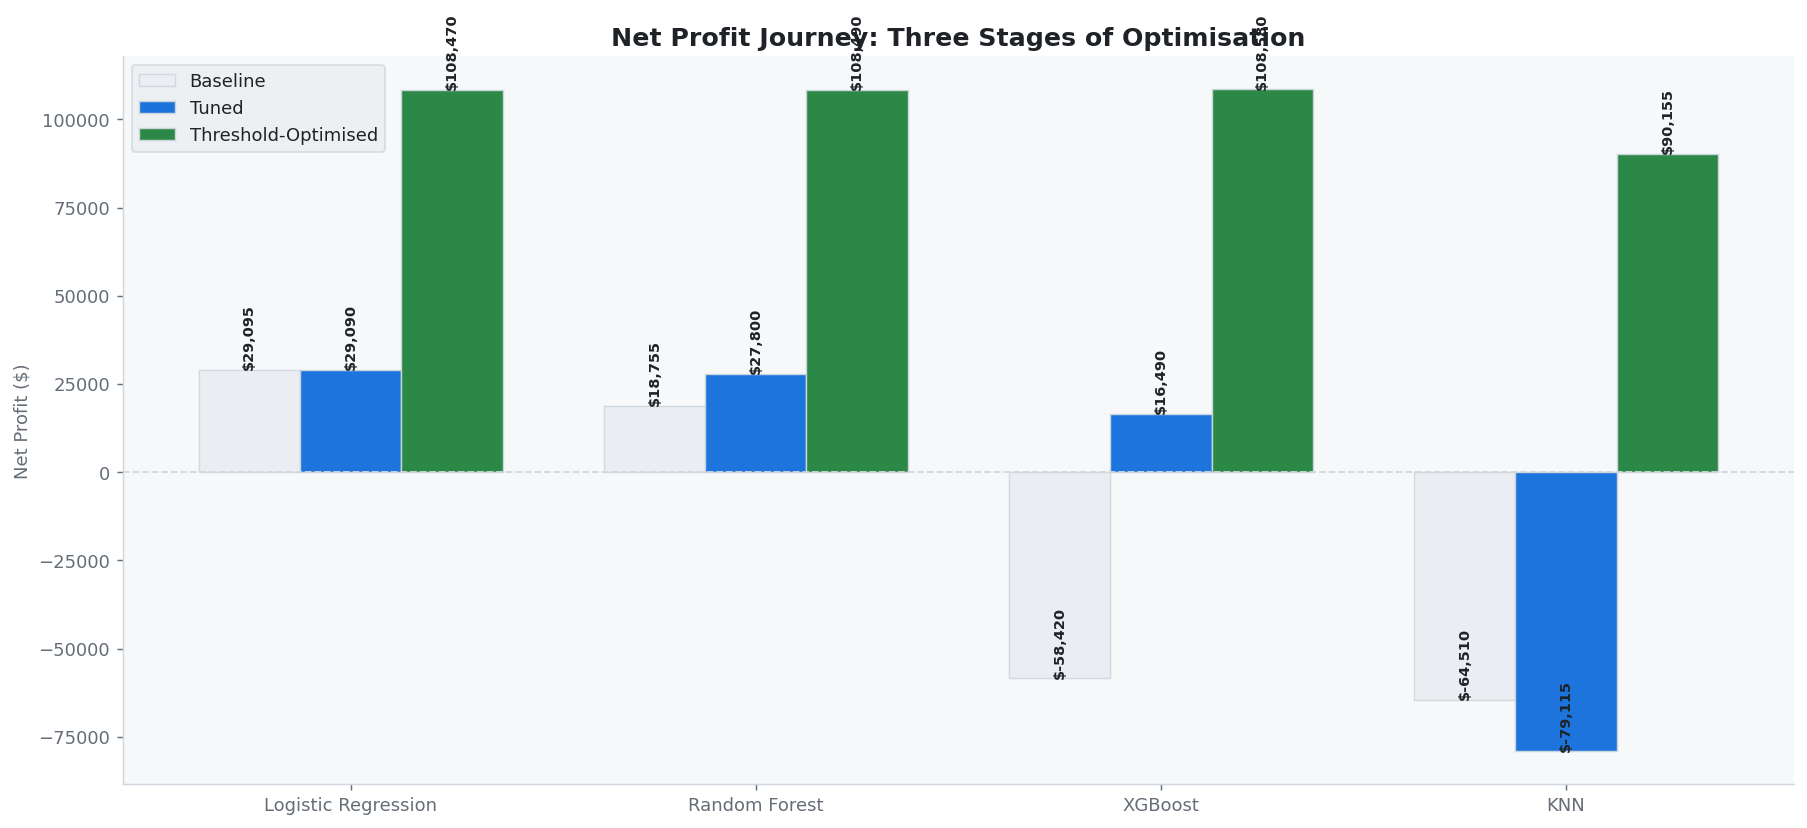


Model                      Baseline        Tuned      Optimised   Total Gain
──────────────────────────────────────────────────────────────────────────
  Logistic Regression  $    29,095 $    29,090 $     108,470 $    79,375
  Random Forest        $    18,755 $    27,800 $     108,490 $    89,735
  XGBoost              $   -58,420 $    16,490 $     108,580 $   167,000
  KNN                  $   -64,510 $   -79,115 $      90,155 $   154,665


In [21]:

stages = ["Baseline", "Tuned", "Threshold-Optimised"]
stage_colors = [P["bg3"], P["neutral"], P["profit"]]

stage_profits = {name: [
    baseline_results[name]["val_net_profit"],
    tuned_results[name]["val_net_profit"],
    net_profit(y_val, threshold_results[name]["y_pred_opt"])
] for name in tune_names}

x = np.arange(len(tune_names))
w = 0.25

fig, ax = plt.subplots(figsize=(14, 6.5))
fig.patch.set_facecolor(P["bg"])
ax.set_facecolor(P["bg2"])

for i, (stage, sc) in enumerate(zip(stages, stage_colors)):
    vals = [stage_profits[n][i] for n in tune_names]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=stage,
                  color=sc, edgecolor=P["border"], linewidth=0.8, alpha=0.92)
    for bar_, val in zip(bars, vals):
        ax.text(bar_.get_x() + bar_.get_width() / 2, val + 50,
                f"${val:,.0f}", ha="center", va="bottom",
                color=P["text"], fontsize=8, fontweight="bold", rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(tune_names, color=P["subtext"])
ax.set_ylabel("Net Profit ($)", color=P["subtext"])
ax.set_title("Net Profit Journey: Three Stages of Optimisation",
             color=P["text"], fontsize=14, fontweight="bold")
ax.axhline(0, color=P["border"], linewidth=1, linestyle="--")
ax.tick_params(colors=P["subtext"])
for spine in ax.spines.values():
    spine.set_edgecolor(P["border"])
ax.legend(facecolor=P["bg3"], edgecolor=P["border"], labelcolor=P["text"])
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Model':<22} {'Baseline':>12} {'Tuned':>12} {'Optimised':>14} {'Total Gain':>12}")
print("─" * 74)
for name in tune_names:
    ps = stage_profits[name]
    print(f"  {name:<20} ${ps[0]:>10,.0f} ${ps[1]:>10,.0f} ${ps[2]:>12,.0f} "
          f"${(ps[2]-ps[0]):>10,.0f}")



## Section 19 — Feature Importance & SHAP Analysis

**Why does the model predict what it predicts?**

Two complementary lenses:
1. **Permutation Importance** — how much does each feature hurt accuracy when randomly shuffled? (model-agnostic, usable for any estimator)
2. **SHAP (SHapley Additive exPlanations)** — the only method with firm theoretical grounding (game theory), showing how each feature *pushed* a specific prediction higher or lower.

We analyse the best tuned model (Random Forest) in detail.


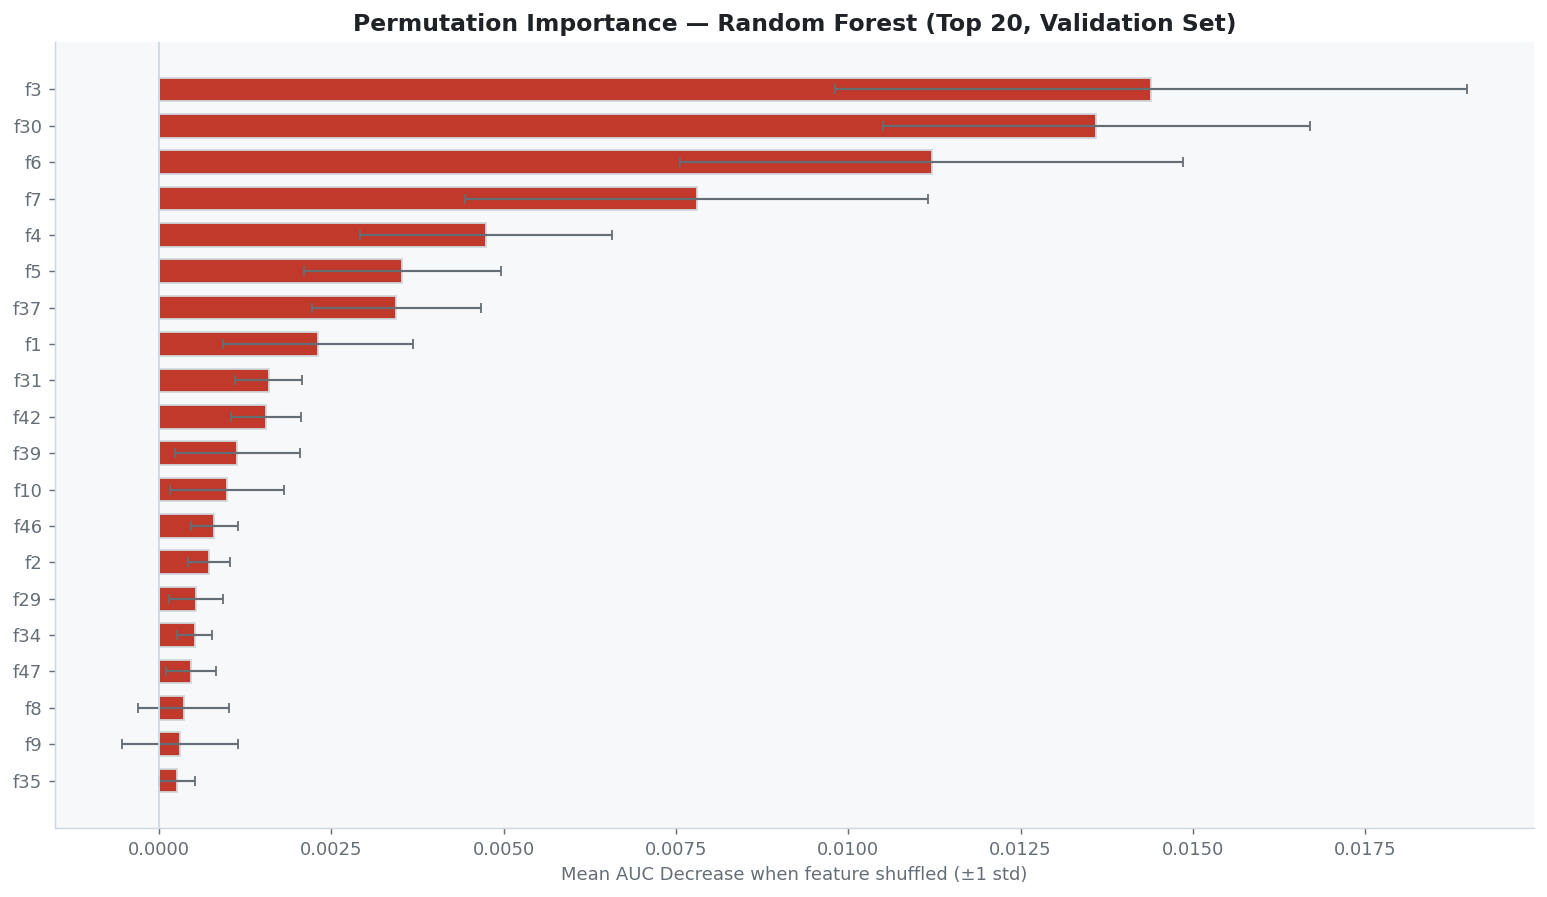

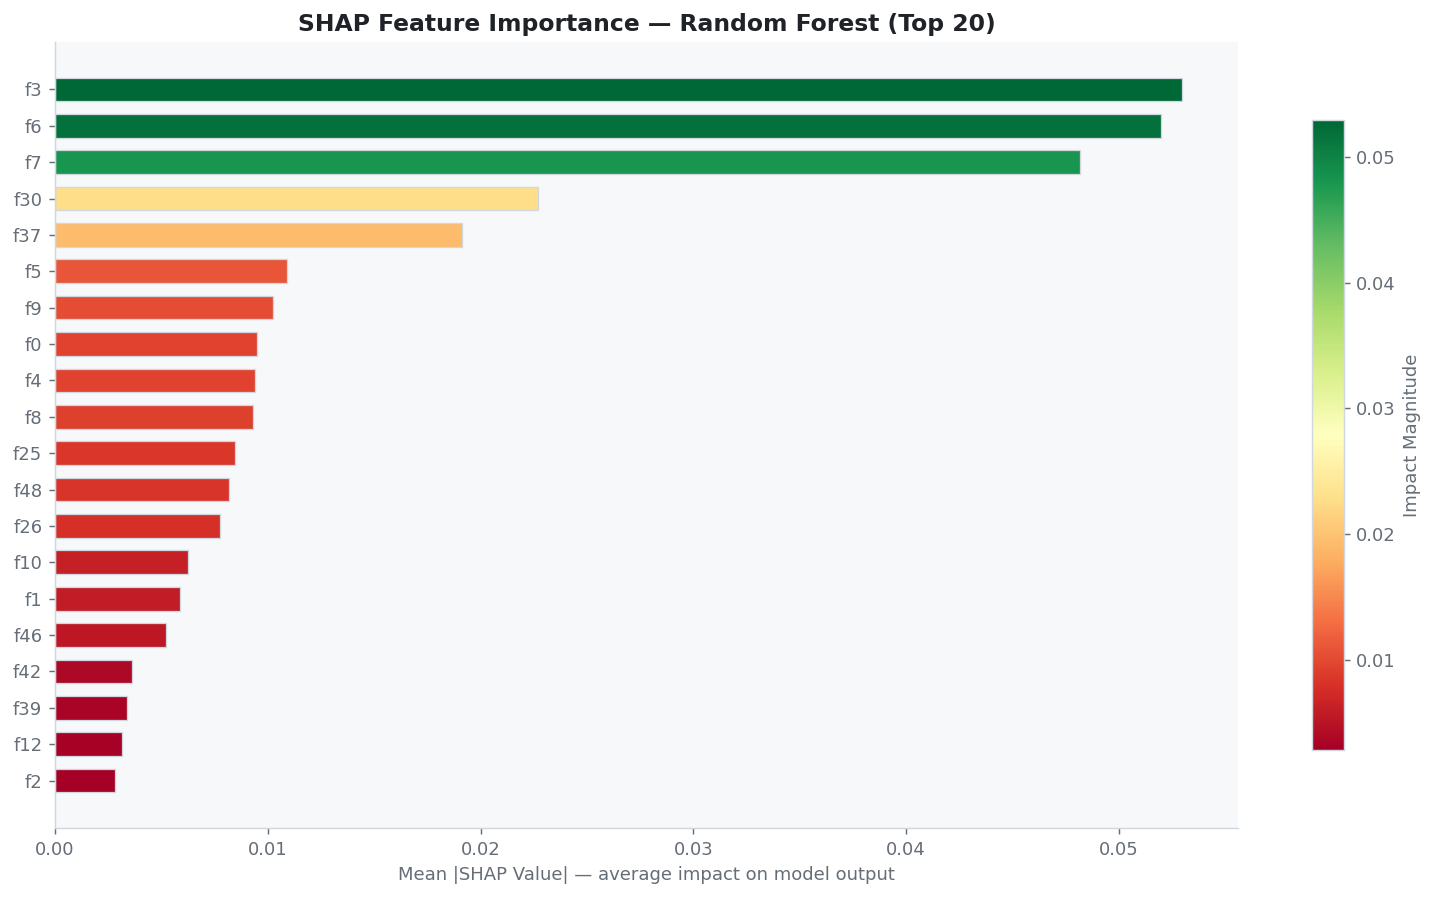

SHAP computed on 600 validation samples — 49 features


In [22]:

from sklearn.inspection import permutation_importance
import shap

BEST_MODEL_NAME = "Random Forest"
best_pipe = tuned_results[BEST_MODEL_NAME]["pipeline"]

# Extract preprocessor and classifier separately
preprocessor_step = best_pipe[:-1]   # all pipeline steps except the estimator
classifier_step   = best_pipe[-1]    # the estimator (RandomForest)

X_val_arr = preprocessor_step.transform(X_val)

# ── Feature name extraction ───────────────────────────────────────────────────
try:
    feat_names_raw = preprocessor_step.get_feature_names_out()
except Exception:
    feat_names_raw = [f"f{i}" for i in range(X_val_arr.shape[1])]

def clean_fn(name):
    for prefix in ["pipeline-1__", "pipeline-2__", "remainder__",
                   "ordinalencoder__", "onehotencoder__", "standardscaler__"]:
        name = name.replace(prefix, "")
    return name

feat_names = [clean_fn(n) for n in feat_names_raw]

# ── Permutation Importance ────────────────────────────────────────────────────
perm_imp = permutation_importance(
    classifier_step, X_val_arr, y_val,
    n_repeats=20, random_state=SEED, n_jobs=-1, scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature":    feat_names[:len(perm_imp.importances_mean)],
    "importance": perm_imp.importances_mean,
    "std":        perm_imp.importances_std,
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(P["bg"])
ax.set_facecolor(P["bg2"])
bar_cols_perm = [P["rf"] if v > 0 else P["loss"] for v in perm_df["importance"]]
ax.barh(perm_df["feature"][::-1], perm_df["importance"][::-1],
        xerr=perm_df["std"][::-1], color=bar_cols_perm[::-1],
        edgecolor=P["border"], height=0.65, capsize=3,
        error_kw={"ecolor": P["subtext"], "linewidth": 1.2})
ax.set_xlabel("Mean AUC Decrease when feature shuffled (±1 std)", color=P["subtext"])
ax.set_title(f"Permutation Importance — {BEST_MODEL_NAME} (Top 20, Validation Set)",
             color=P["text"], fontsize=13, fontweight="bold")
ax.tick_params(colors=P["subtext"])
ax.axvline(0, color=P["border"], linewidth=1)
for spine in ax.spines.values():
    spine.set_edgecolor(P["border"])
plt.tight_layout()
plt.show()

# ── SHAP Feature Importance (Mean |SHAP|) ─────────────────────────────────────
sample_size = min(600, len(X_val_arr))
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_val_arr), sample_size, replace=False)

# Handle both numpy array and sparse matrix
if hasattr(X_val_arr, "toarray"):
    X_sample = X_val_arr.toarray()[sample_idx]
else:
    X_sample = X_val_arr[sample_idx]

explainer   = shap.TreeExplainer(classifier_step)
shap_values = explainer.shap_values(X_sample)

# shap_values shape handling: list (old API) vs 3D array (new API)
if isinstance(shap_values, list):
    sv = shap_values[1]          # class 1 for binary classification
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]    # new SHAP API: (samples, features, classes)
else:
    sv = shap_values             # already 2D (samples × features)

mean_abs_shap = np.abs(sv).mean(axis=0)
n_feats = min(20, len(feat_names))
shap_df = pd.DataFrame({
    "feature":       feat_names[:len(mean_abs_shap)],
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).head(n_feats)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(P["bg"])
ax.set_facecolor(P["bg2"])

cmap_shap = plt.cm.RdYlGn
norm_shap = plt.Normalize(shap_df["mean_abs_shap"].min(), shap_df["mean_abs_shap"].max())
bar_colors_shap = [cmap_shap(norm_shap(v)) for v in shap_df["mean_abs_shap"][::-1]]
ax.barh(shap_df["feature"][::-1], shap_df["mean_abs_shap"][::-1],
        color=bar_colors_shap, edgecolor=P["border"], height=0.65, linewidth=0.7)
ax.set_xlabel("Mean |SHAP Value| — average impact on model output", color=P["subtext"])
ax.set_title(f"SHAP Feature Importance — {BEST_MODEL_NAME} (Top 20)",
             color=P["text"], fontsize=13, fontweight="bold")
ax.tick_params(colors=P["subtext"])
for spine in ax.spines.values():
    spine.set_edgecolor(P["border"])
sm = plt.cm.ScalarMappable(cmap=cmap_shap, norm=norm_shap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.ax.yaxis.set_tick_params(color=P["subtext"])
cbar.set_label("Impact Magnitude", color=P["subtext"])
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=P["subtext"])
plt.tight_layout()
plt.show()

# Store for waterfall plots below
SHAP_STATE = {
    "sv": sv, "X_sample": X_sample, "feat_names": feat_names,
    "explainer": explainer, "shap_df": shap_df
}
print(f"SHAP computed on {sample_size} validation samples — {sv.shape[1]} features")


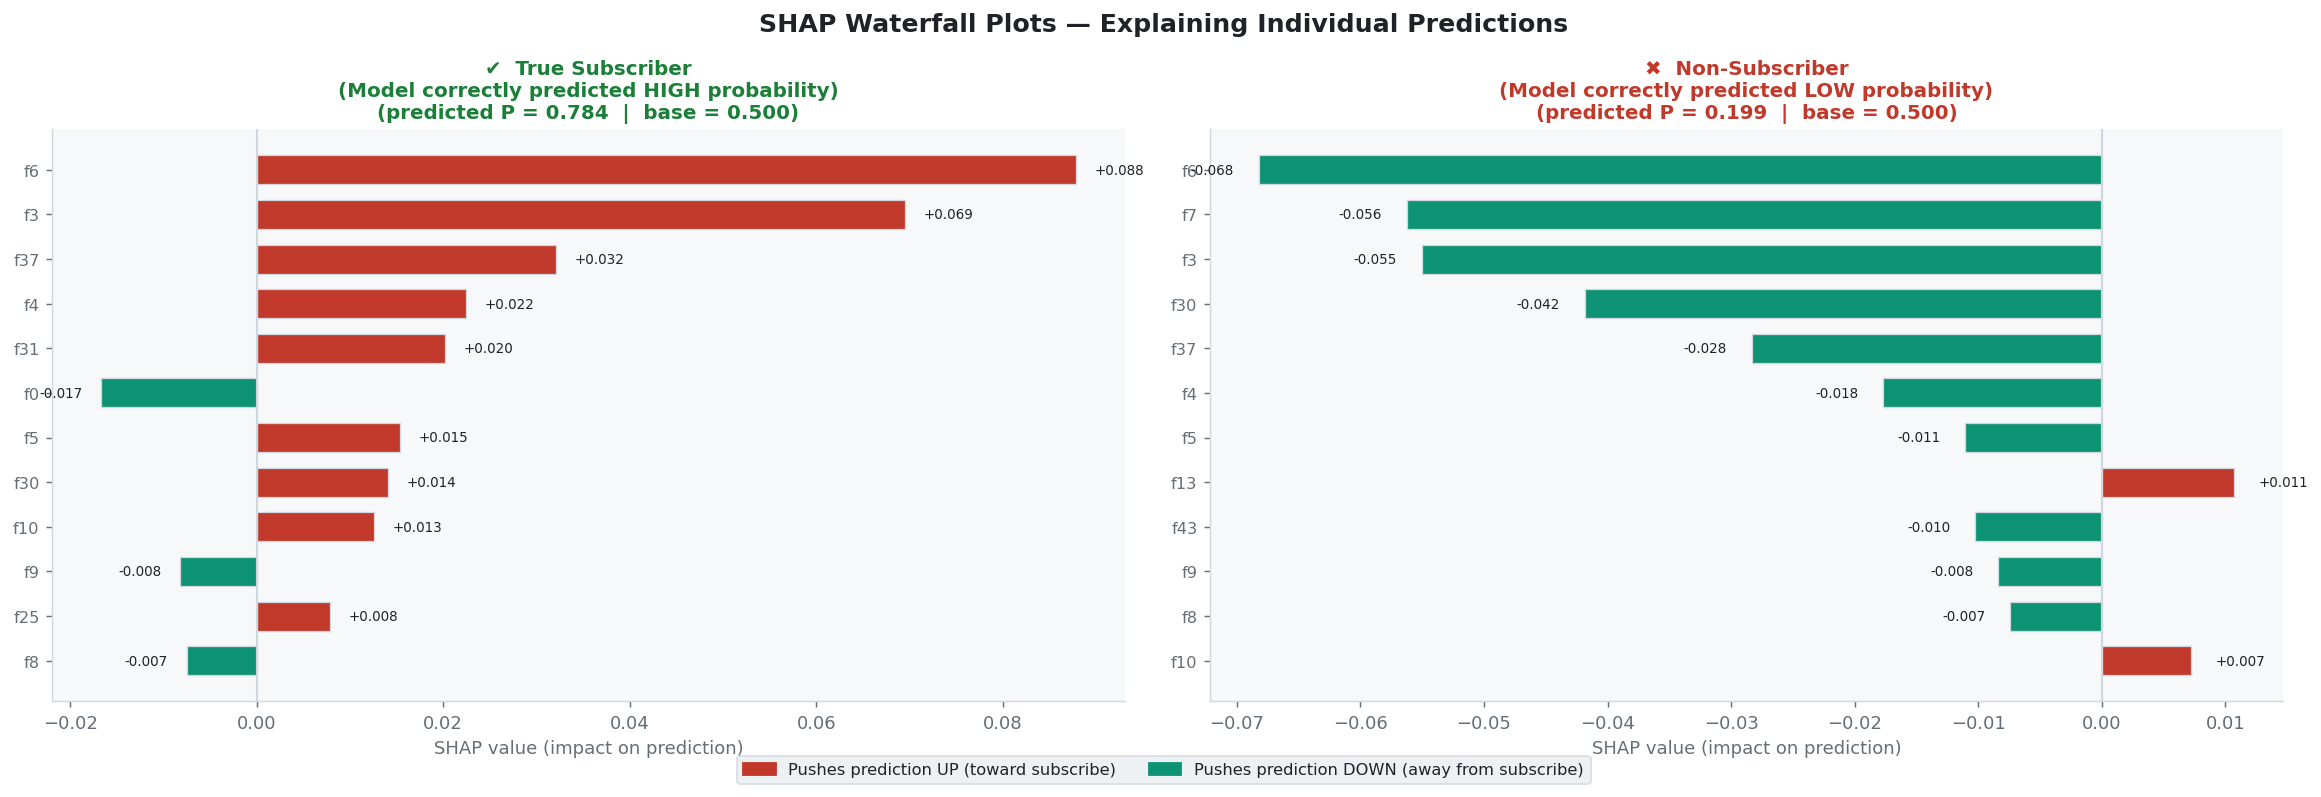

In [23]:

# ── SHAP Waterfall Plots — Individual Prediction Explanations ─────────────────
# Show WHY the model predicted what it did for specific customers
# (one true subscriber and one non-subscriber)
sv         = SHAP_STATE["sv"]
X_sample   = SHAP_STATE["X_sample"]
feat_names = SHAP_STATE["feat_names"]

# Recover the actual labels for the sample
y_val_arr   = y_val.values
sample_idx_ = np.random.RandomState(SEED).choice(len(y_val_arr), X_sample.shape[0], replace=False)
y_sample    = y_val_arr[sample_idx_]

# Pick one true positive and one true negative to explain
y_prob_sample = tuned_results[BEST_MODEL_NAME]["pipeline"].predict_proba(
    X_val.iloc[sample_idx_])[:, 1]

tp_candidates = np.where((y_sample == 1) & (y_prob_sample >= 0.5))[0]
tn_candidates = np.where((y_sample == 0) & (y_prob_sample <= 0.1))[0]

idx_tp = tp_candidates[0] if len(tp_candidates) > 0 else 0
idx_tn = tn_candidates[0] if len(tn_candidates) > 0 else 1

def waterfall_plot(ax, shap_row, base_val, pred_prob, title, highlight_color):
    """Draw a manual waterfall chart for a single prediction."""
    top_k = 12
    order  = np.argsort(np.abs(shap_row))[::-1][:top_k]
    names  = [feat_names[i] if i < len(feat_names) else f"f{i}" for i in order]
    values = shap_row[order]

    bar_colors_wf = [P["rf"] if v > 0 else P["lr"] for v in values]
    y_pos = np.arange(len(values))
    ax.set_facecolor(P["bg2"])
    bars = ax.barh(y_pos, values[::-1], color=bar_colors_wf[::-1],
                   edgecolor=P["border"], height=0.65, linewidth=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names[::-1], color=P["text"], fontsize=9)
    ax.axvline(0, color=P["border"], linewidth=1.2)
    ax.set_xlabel("SHAP value (impact on prediction)", color=P["subtext"])
    ax.set_title(f"{title}\n(predicted P = {pred_prob:.3f}  |  base = {base_val:.3f})",
                 color=highlight_color, fontweight="bold", fontsize=11)
    ax.tick_params(colors=P["subtext"])
    for spine in ax.spines.values():
        spine.set_edgecolor(P["border"])
    # Annotate each bar
    for bar_, val in zip(bars, values[::-1]):
        ax.text(val + (0.002 if val >= 0 else -0.002),
                bar_.get_y() + bar_.get_height() / 2,
                f"{val:+.3f}", va="center",
                ha="left" if val >= 0 else "right",
                color=P["text"], fontsize=7.5)

explainer_base = SHAP_STATE["explainer"].expected_value
if isinstance(explainer_base, (list, np.ndarray)):
    base_val = float(explainer_base[1])
else:
    base_val = float(explainer_base)

fig, (ax_tp, ax_tn) = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("SHAP Waterfall Plots — Explaining Individual Predictions",
             fontsize=14, fontweight="bold", color=P["text"])

waterfall_plot(ax_tp, sv[idx_tp], base_val,
               float(y_prob_sample[idx_tp]),
               "✔  True Subscriber\n(Model correctly predicted HIGH probability)",
               P["profit"])

waterfall_plot(ax_tn, sv[idx_tn], base_val,
               float(y_prob_sample[idx_tn]),
               "✖  Non-Subscriber\n(Model correctly predicted LOW probability)",
               P["loss"])

# Add legend
legend_patches = [
    mpatches.Patch(color=P["rf"], label="Pushes prediction UP (toward subscribe)"),
    mpatches.Patch(color=P["lr"], label="Pushes prediction DOWN (away from subscribe)"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           facecolor=P["bg3"], edgecolor=P["border"], labelcolor=P["text"],
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()



## Section 20 — Business ROI: When to Call, When Not to Call

The model outputs a **subscription probability** for every customer. The business question is:

> *"At what probability level is it worth making a call?"*

**Decision Rule:**  
- If `P(subscribe) ≥ optimal_threshold` → **CALL** (expected value positive)  
- If `P(subscribe) < optimal_threshold` → **DO NOT CALL** (cost outweighs expected return)

**Campaign Resource Savings:**  
By skipping low-probability customers, the bank can re-direct call-centre hours to high-value prospects — reducing campaign cost while maintaining subscription capture rate.


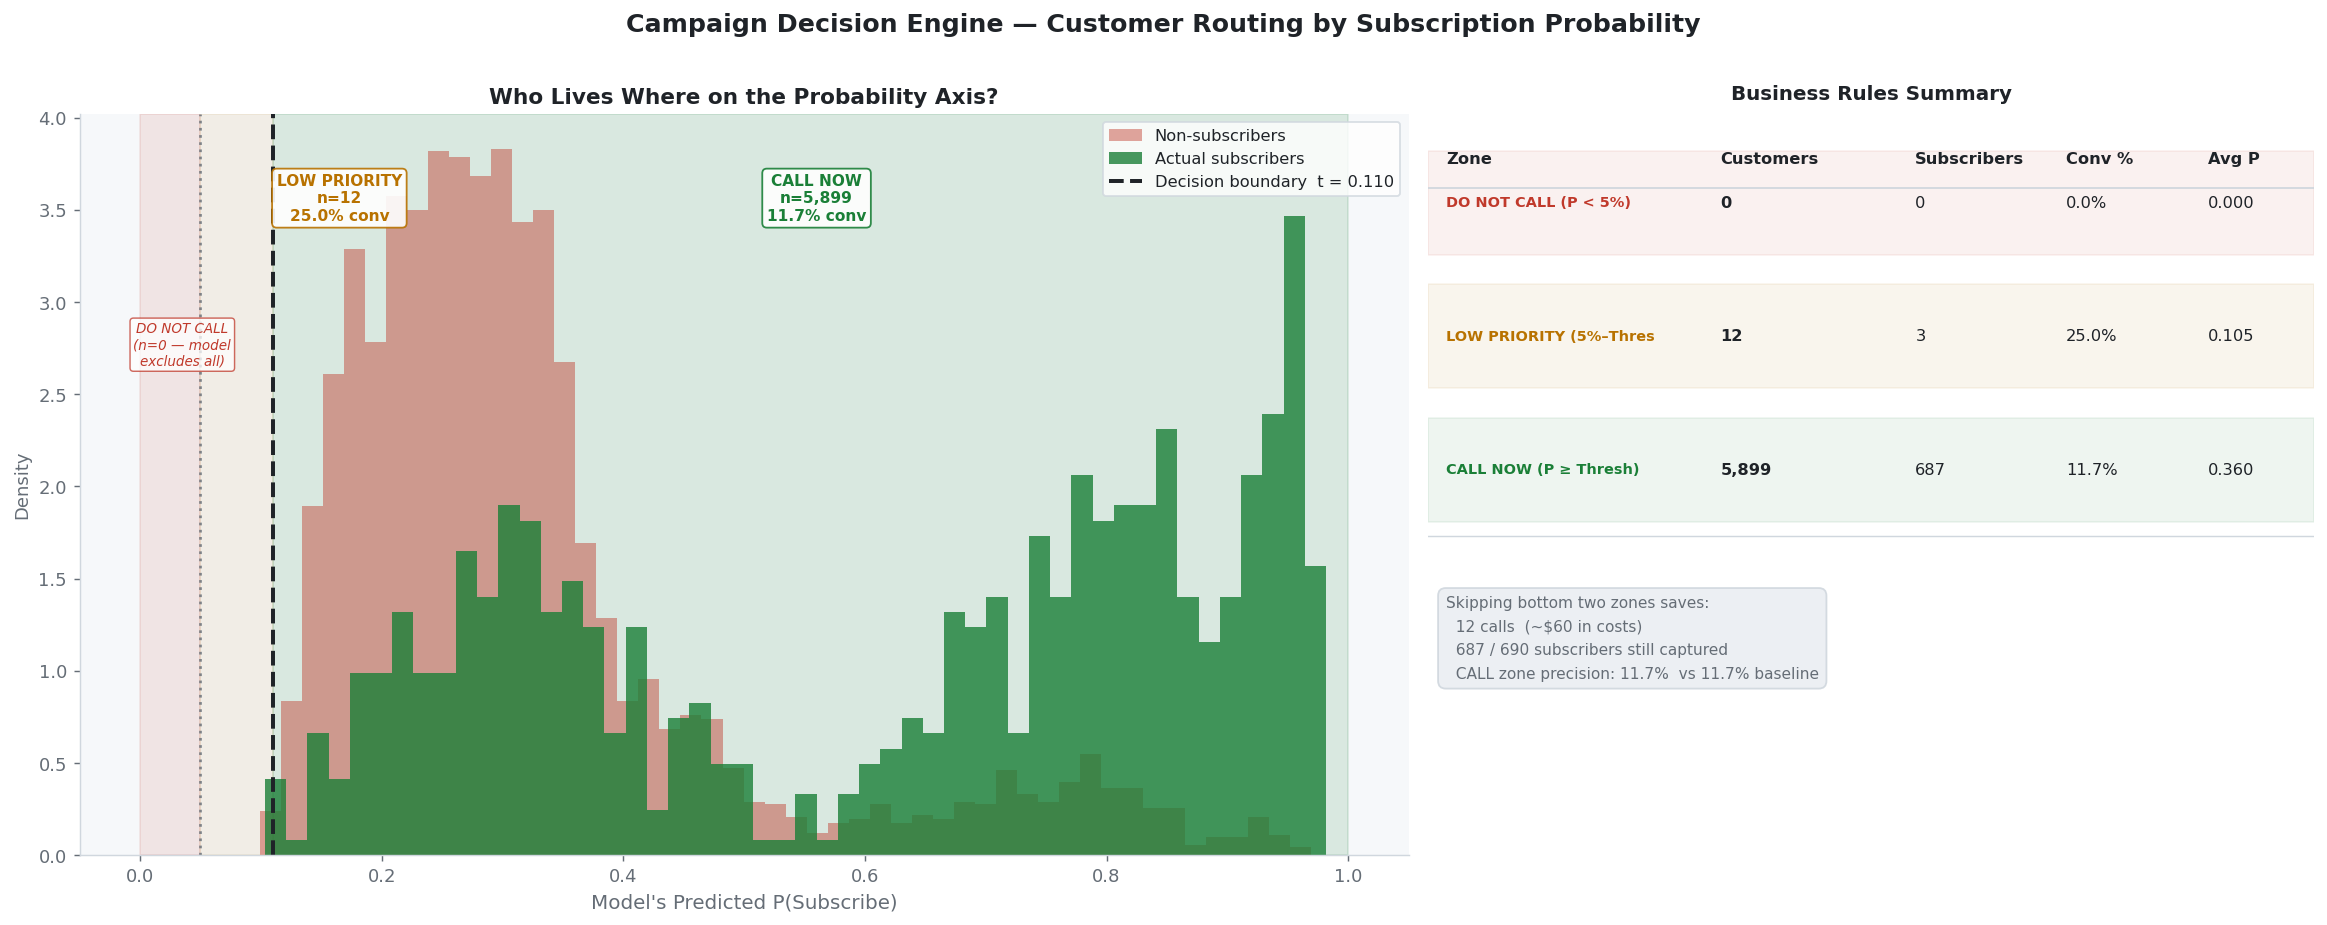

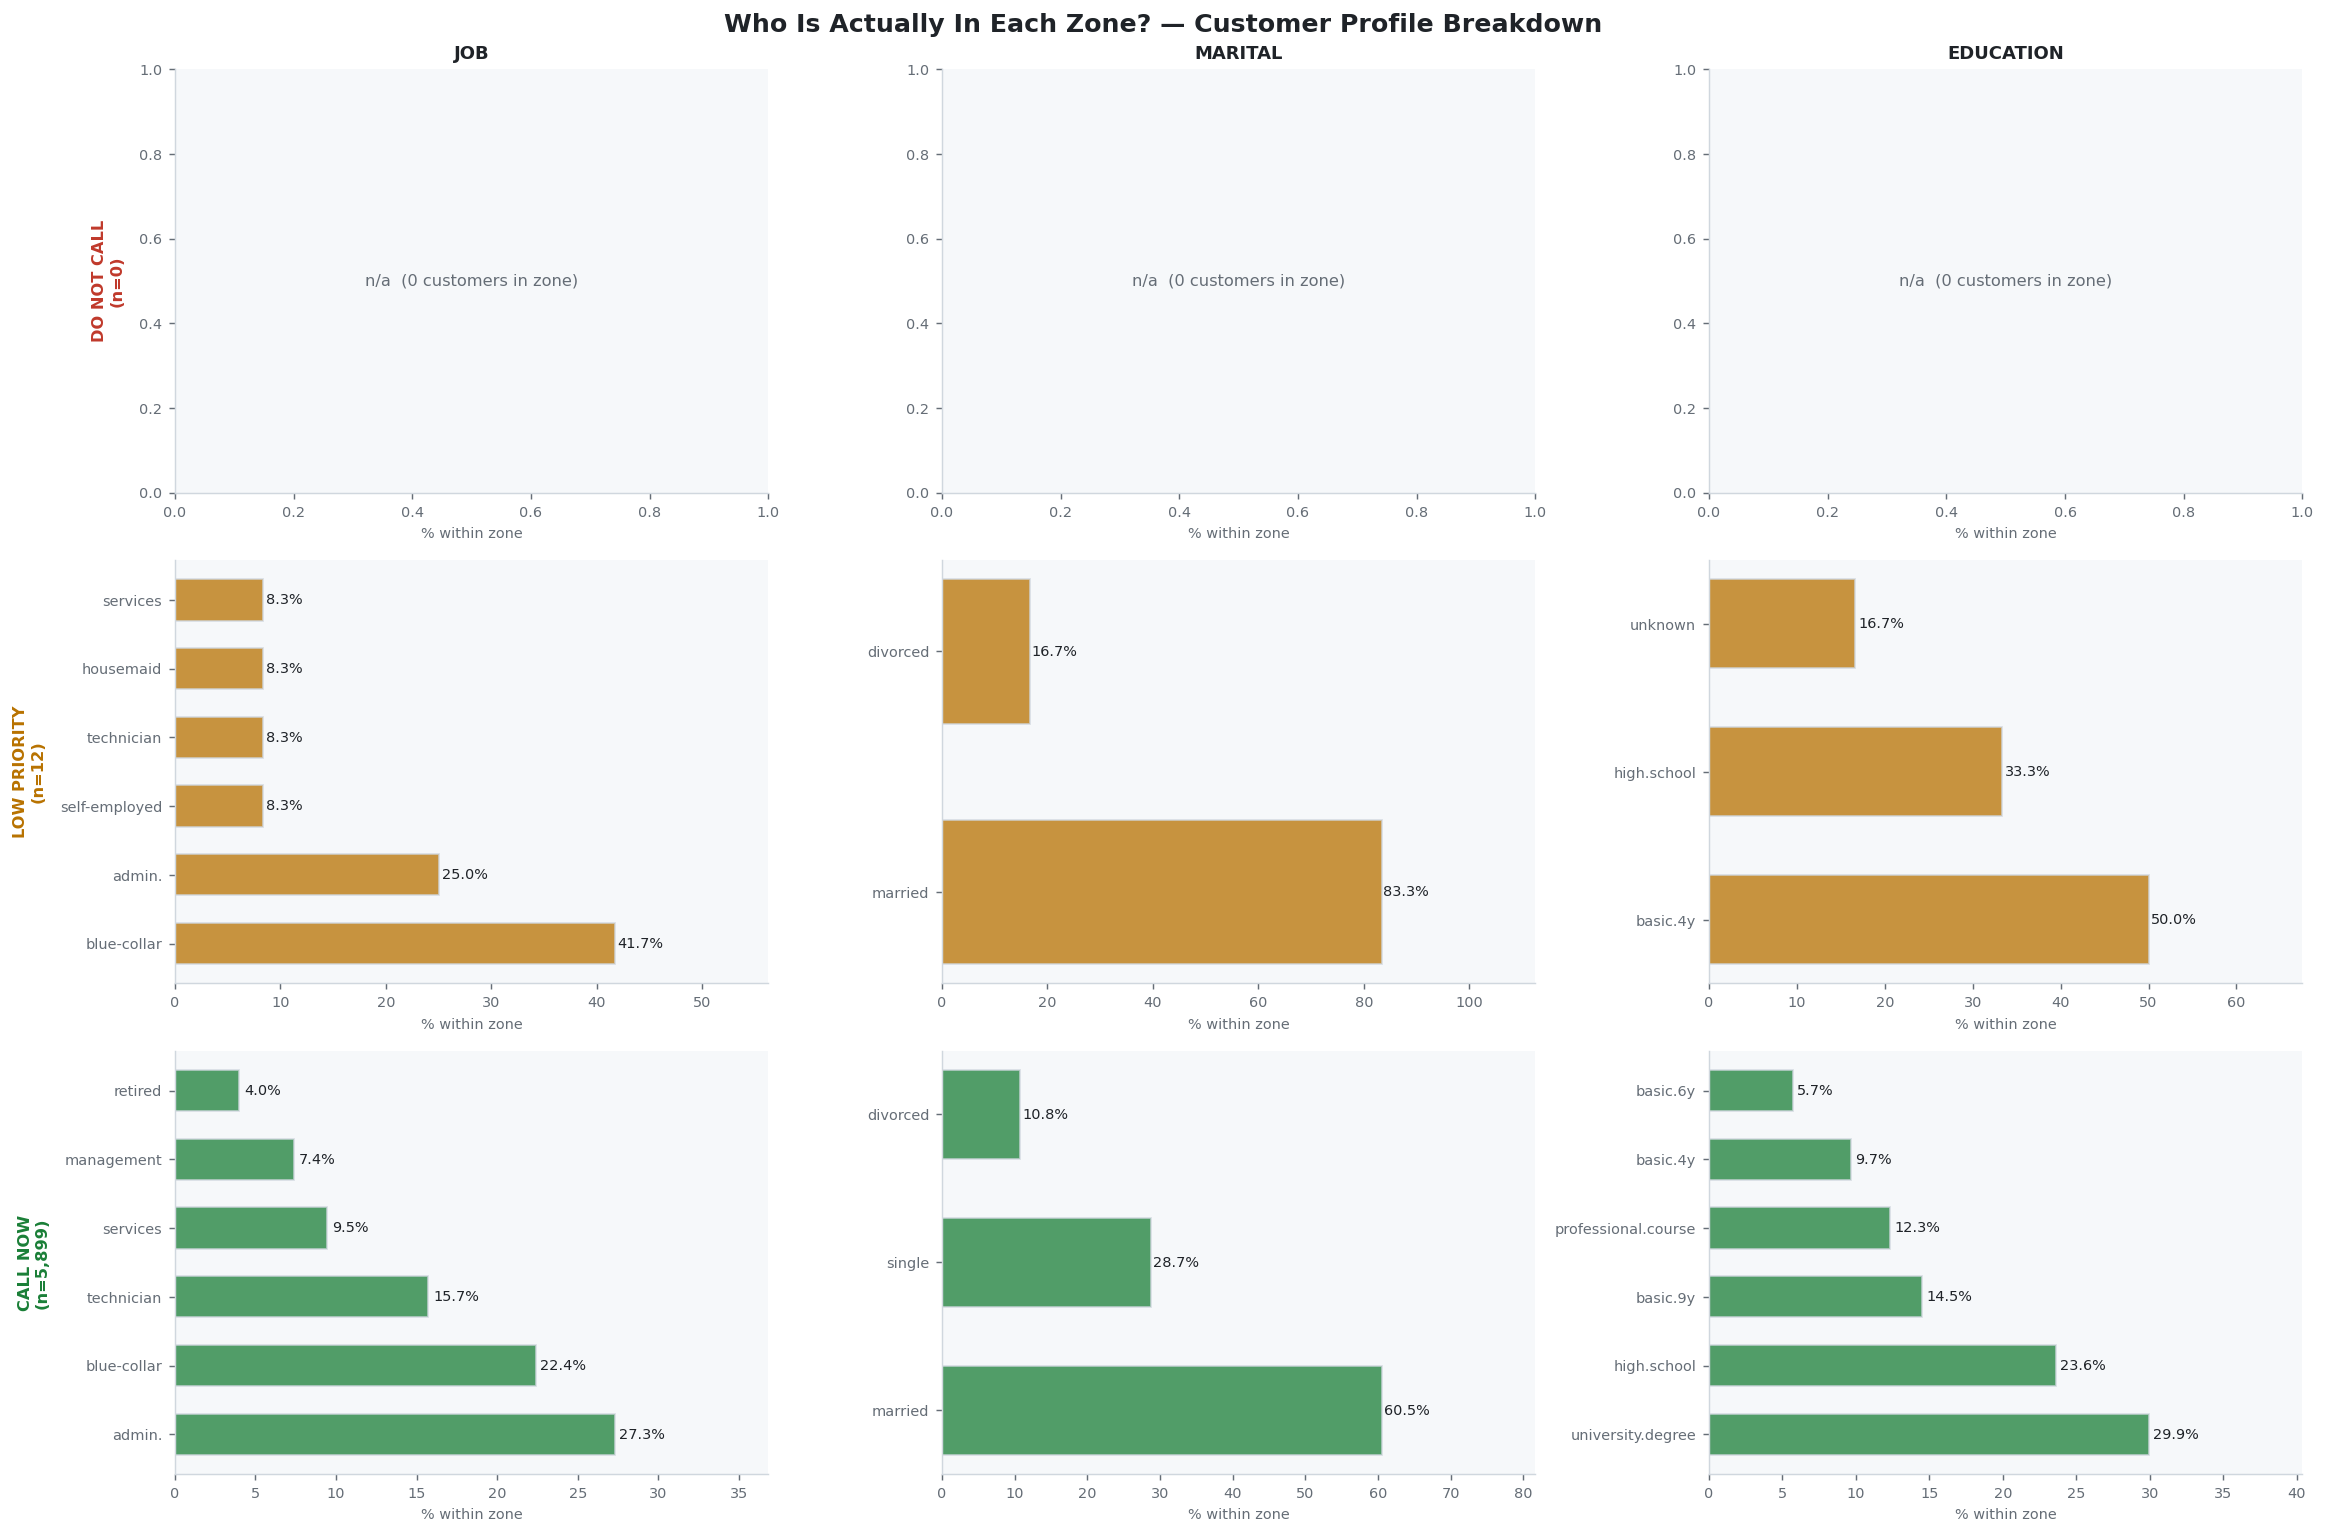


═════════════════════════════════════════════════════════════════
  CAMPAIGN BUSINESS RULES — Generated from Model Output
═════════════════════════════════════════════════════════════════

  [✗ SKIP]  DO NOT CALL (P < 5%)
    Customers in zone :      0
    Actual subscribers:      0  (0.0% conversion)
    Avg model score   : 0.0000
    Revenue at risk   : $       0  (if entire zone skipped)

  [◎ HOLD]  LOW PRIORITY (5%–Thresh)
    Customers in zone :     12
    Actual subscribers:      3  (25.0% conversion)
    Avg model score   : 0.1053
    Revenue at risk   : $     600  (if entire zone skipped)

  [✔ CALL]  CALL NOW (P ≥ Thresh)
    Customers in zone :  5,899
    Actual subscribers:    687  (11.7% conversion)
    Avg model score   : 0.3598

═════════════════════════════════════════════════════════════════
  Decision boundary : P ≥ 0.1100  →  CALL
  Pool called       : 5,899 / 5,911 (99.8%)
  Recall captured   : 0.9957
  Test Net Profit   : $107,305
═════════════════════════════════

In [24]:

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 20 — Business Decision Engine: Who Gets Called and Why
# ══════════════════════════════════════════════════════════════════════════════
best_name   = "Random Forest"
best_thresh = threshold_results[best_name]["best_threshold"]
y_prob_test = tuned_results[best_name]["pipeline"].predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_thresh).astype(int)

# ── Attach probabilities back to the original test rows ──────────────────────
test_profile = X_test.copy()
test_profile["prob_subscribe"] = y_prob_test
test_profile["predicted"]      = y_pred_test
test_profile["actual"]         = y_test.values

# Define three business zones — rule-based and interpretable for a campaign manager
ZONE_RULES = {
    "DO NOT CALL (P < 5%)":     (0.00, 0.05),
    "LOW PRIORITY (5%–Thresh)": (0.05, float(best_thresh)),
    "CALL NOW (P ≥ Thresh)":    (float(best_thresh), 1.01),
}
ZONE_SHORT  = ["DO NOT CALL", "LOW PRIORITY", "CALL NOW"]
ZONE_COLORS = [P["loss"], P["xgb"], P["profit"]]

zone_stats = []
for label, (lo, hi) in ZONE_RULES.items():
    mask       = (y_prob_test >= lo) & (y_prob_test < hi)
    n          = int(mask.sum())
    actual_sub = int(y_test.values[mask].sum())
    conv_rate  = round(actual_sub / n * 100, 2) if n > 0 else 0.0
    avg_p      = round(float(y_prob_test[mask].mean()), 4) if n > 0 else 0.0
    missed_rev = actual_sub * 200
    call_cost  = n * 5
    zone_stats.append({
        "Zone": label, "Count": n, "Actual Subscribers": actual_sub,
        "Conv Rate (%)": conv_rate, "Avg P": avg_p,
        "Revenue at Risk ($)": missed_rev, "Call Cost ($)": call_cost,
    })

stats_df = pd.DataFrame(zone_stats)

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Decision Zone Distribution with live customer counts
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax_hist, ax_table) = plt.subplots(1, 2, figsize=(18, 7),
                                         gridspec_kw={"width_ratios": [1.5, 1]})
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Campaign Decision Engine — Customer Routing by Subscription Probability",
             fontsize=14, fontweight="bold", color=P["text"], y=1.01)

# — Left: draw histograms first, then annotate so ylim is settled —
ax_hist.set_facecolor(P["bg2"])
ax_hist.hist(y_prob_test[y_test == 0], bins=50, color=P["loss"],
             alpha=0.45, density=True, label="Non-subscribers")
ax_hist.hist(y_prob_test[y_test == 1], bins=50, color=P["profit"],
             alpha=0.80, density=True, label="Actual subscribers")

zone_boundaries = [0.0, 0.05, float(best_thresh), 1.0]
zone_fills      = [P["loss"], P["xgb"], P["profit"]]
zone_alphas_bg  = [0.10, 0.08, 0.13]

for i, (lo, hi) in enumerate(zip(zone_boundaries[:-1], zone_boundaries[1:])):
    ax_hist.axvspan(lo, hi, alpha=zone_alphas_bg[i], color=zone_fills[i], zorder=0)

ax_hist.axvline(0.05,        color=P["subtext"], lw=1.5, linestyle=":", alpha=0.8)
ax_hist.axvline(best_thresh, color=P["text"],    lw=2.2, linestyle="--",
                label=f"Decision boundary  t = {best_thresh:.3f}")
ax_hist.set_xlabel("Model's Predicted P(Subscribe)", color=P["subtext"], fontsize=11)
ax_hist.set_ylabel("Density", color=P["subtext"])
ax_hist.set_title("Who Lives Where on the Probability Axis?", color=P["text"],
                  fontweight="bold")
ax_hist.legend(facecolor=P["bg"], edgecolor=P["border"], fontsize=9)
ax_hist.tick_params(colors=P["subtext"])
for sp in ax_hist.spines.values():
    sp.set_edgecolor(P["border"])

# Annotate badges — only for zones with customers, positioned with enough margin
y_top   = ax_hist.get_ylim()[1]
badge_y = y_top * 0.92

# Assign badge x positions per zone — keep at least 0.06 gap from axis edge
# and space them so they never overlap
badge_positions = []
for i, row in stats_df.iterrows():
    lo, hi = list(ZONE_RULES.values())[i]
    mid    = (lo + hi) / 2
    badge_positions.append(mid)

# Minimum separation between neighbouring badges
MIN_SEP = 0.14
for i in range(1, len(badge_positions)):
    if badge_positions[i] - badge_positions[i-1] < MIN_SEP:
        badge_positions[i] = badge_positions[i-1] + MIN_SEP

for i, row in stats_df.iterrows():
    n_zone = int(row["Count"])
    if n_zone == 0:
        # Empty zone: show a small edge label instead of a full badge
        lo, hi = list(ZONE_RULES.values())[i]
        ax_hist.text(hi * 0.5 + 0.01, y_top * 0.72,
                     f"{ZONE_SHORT[i]}\n(n=0 — model\nexcludes all)",
                     ha="center", va="top", fontsize=7.5, fontstyle="italic",
                     color=ZONE_COLORS[i], clip_on=False,
                     bbox=dict(boxstyle="round,pad=0.25", facecolor=P["bg"],
                               edgecolor=ZONE_COLORS[i], alpha=0.75, lw=0.8))
    else:
        badge_x = float(badge_positions[i])
        ax_hist.text(badge_x, badge_y,
                     f"{ZONE_SHORT[i]}\nn={row['Count']:,}\n{row['Conv Rate (%)']:.1f}% conv",
                     ha="center", va="top", fontsize=8.5, fontweight="bold",
                     color=ZONE_COLORS[i], clip_on=False,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor=P["bg"],
                               edgecolor=ZONE_COLORS[i], alpha=0.90))

# — Right: Business rules summary table (using direct column names, not positional) —
ax_table.set_facecolor(P["bg"])
ax_table.set_xlim(0, 10)
ax_table.set_ylim(0, 10)
ax_table.axis("off")

col_headers = ["Zone", "Customers", "Subscribers", "Conv %", "Avg P"]
col_x       = [0.2, 3.3, 5.5, 7.2, 8.8]
row_ys      = [8.8, 7.0, 5.2]

for cx, ch in zip(col_x, col_headers):
    ax_table.text(cx, 9.4, ch, ha="left", va="center", fontsize=9,
                  fontweight="bold", color=P["text"])
ax_table.axhline(9.0, xmin=0, xmax=1, color=P["border"], linewidth=1)

for i, (ry, zc) in enumerate(zip(row_ys, ZONE_COLORS)):
    row = stats_df.iloc[i]
    ax_table.axhspan(ry - 0.7, ry + 0.7, alpha=0.07, color=zc)
    ax_table.text(col_x[0], ry, row["Zone"][:22],          ha="left", va="center", fontsize=8,   color=zc, fontweight="bold")
    ax_table.text(col_x[1], ry, f"{row['Count']:,}",       ha="left", va="center", fontsize=9,   color=P["text"], fontweight="bold")
    ax_table.text(col_x[2], ry, f"{row['Actual Subscribers']:,}", ha="left", va="center", fontsize=9, color=P["text"])
    ax_table.text(col_x[3], ry, f"{row['Conv Rate (%)']:.1f}%",  ha="left", va="center", fontsize=9, color=P["text"])
    ax_table.text(col_x[4], ry, f"{row['Avg P']:.3f}",           ha="left", va="center", fontsize=9, color=P["text"])

ax_table.axhline(row_ys[-1] - 0.9, xmin=0, xmax=1, color=P["border"], linewidth=0.8)

saved_calls = stats_df.iloc[0]["Count"] + stats_df.iloc[1]["Count"]
ax_table.text(0.2, 3.5,
              f"Skipping bottom two zones saves:\n"
              f"  {saved_calls:,} calls  (~${saved_calls * 5:,} in costs)\n"
              f"  {stats_df.iloc[2]['Actual Subscribers']:,} / {int(y_test.sum())} "
              f"subscribers still captured\n"
              f"  CALL zone precision: {stats_df.iloc[2]['Conv Rate (%)']:.1f}%  "
              f"vs {y_test.mean()*100:.1f}% baseline",
              ha="left", va="top", fontsize=8.5, color=P["subtext"], linespacing=1.7,
              bbox=dict(boxstyle="round,pad=0.5", facecolor=P["bg3"],
                        edgecolor=P["border"], alpha=0.9))

ax_table.set_title("Business Rules Summary", color=P["text"],
                   fontweight="bold", fontsize=11, pad=8)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Customer profiles INSIDE each zone
# ─────────────────────────────────────────────────────────────────────────────
profile_cols = ["job", "marital", "education"]
zone_mask_list = [
    (y_prob_test <  0.05),
    (y_prob_test >= 0.05) & (y_prob_test < float(best_thresh)),
    (y_prob_test >= float(best_thresh)),
]

fig, axes = plt.subplots(3, len(profile_cols), figsize=(18, 12), sharey=False)
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Who Is Actually In Each Zone? — Customer Profile Breakdown",
             fontsize=14, fontweight="bold", color=P["text"])

for row_i, (zmask, zcolor, zlabel) in enumerate(zip(zone_mask_list, ZONE_COLORS, ZONE_SHORT)):
    sub_df = test_profile[zmask]
    n_zone = int(zmask.sum())

    for col_i, feat in enumerate(profile_cols):
        ax = axes[row_i][col_i]
        ax.set_facecolor(P["bg2"])

        if feat in sub_df.columns and n_zone > 0:
            counts = sub_df[feat].value_counts().head(6)
            if len(counts) == 0:
                ax.text(0.5, 0.5, "no data", ha="center", va="center",
                        color=P["subtext"], transform=ax.transAxes)
            else:
                pcts   = (counts / n_zone * 100).astype(float)
                pmax   = float(pcts.max())
                bars_p = ax.barh(counts.index, pcts, color=zcolor,
                                 alpha=0.75, edgecolor=P["border"], height=0.6)
                for bar_, pct_val in zip(bars_p, pcts):
                    ax.text(pct_val + 0.3, bar_.get_y() + bar_.get_height() / 2,
                            f"{pct_val:.1f}%", va="center", ha="left",
                            color=P["text"], fontsize=8)
                xlim_max = pmax * 1.35 if np.isfinite(pmax) and pmax > 0 else 10
                ax.set_xlim(0, xlim_max)
        else:
            ax.text(0.5, 0.5, "n/a  (0 customers in zone)", ha="center", va="center",
                    color=P["subtext"], fontsize=9, transform=ax.transAxes)

        ax.tick_params(colors=P["subtext"], labelsize=8)
        for sp in ax.spines.values():
            sp.set_edgecolor(P["border"])

        if col_i == 0:
            ax.set_ylabel(f"{zlabel}\n(n={n_zone:,})",
                          color=zcolor, fontsize=9, fontweight="bold", labelpad=8)
        if row_i == 0:
            ax.set_title(feat.upper(), color=P["text"], fontweight="bold", fontsize=10)
        ax.set_xlabel("% within zone", color=P["subtext"], fontsize=8)

plt.tight_layout()
plt.show()

# ── Printed business rule card ────────────────────────────────────────────────
print("\n" + "═"*65)
print("  CAMPAIGN BUSINESS RULES — Generated from Model Output")
print("═"*65)
for i, row in stats_df.iterrows():
    icon = ["✗ SKIP", "◎ HOLD", "✔ CALL"][i]
    print(f"\n  [{icon}]  {row['Zone']}")
    print(f"    Customers in zone : {row['Count']:>6,}")
    print(f"    Actual subscribers: {row['Actual Subscribers']:>6,}  "
          f"({row['Conv Rate (%)']:.1f}% conversion)")
    print(f"    Avg model score   : {row['Avg P']:.4f}")
    if i < 2:
        print(f"    Revenue at risk   : ${row['Revenue at Risk ($)']:>8,}  "
              f"(if entire zone skipped)")
print("\n" + "═"*65)
print(f"  Decision boundary : P ≥ {best_thresh:.4f}  →  CALL")
print(f"  Pool called       : {y_pred_test.sum():,} / {len(y_pred_test):,} "
      f"({y_pred_test.mean()*100:.1f}%)")
print(f"  Recall captured   : {recall_score(y_test, y_pred_test):.4f}")
print(f"  Test Net Profit   : ${net_profit(y_test, y_pred_test):,.0f}")
print("═"*65)



## Section 21 — KMeans Lead Segmentation: Tri-Path Prospect Routing

Instead of a binary call/don't-call decision, we cluster customers into **three priority tiers** based on their predicted subscription probability:

| Tier | Probability Range | Label | Action |
|------|------------------|-------|--------|
| 🔴 Hot | High | **Hot Prospect** | Priority outreach — dedicated sales agent |
| 🟡 Warm | Medium | **Warm Prospect** | Standard call queue |
| 🔵 Cold | Low | **Cold Prospect** | Email nurture / skip |

KMeans (k=3) discovers these natural groupings in probability space. The boundaries emerge from the data — not from arbitrary thresholds — making this approach more adaptive to different campaign seasons.


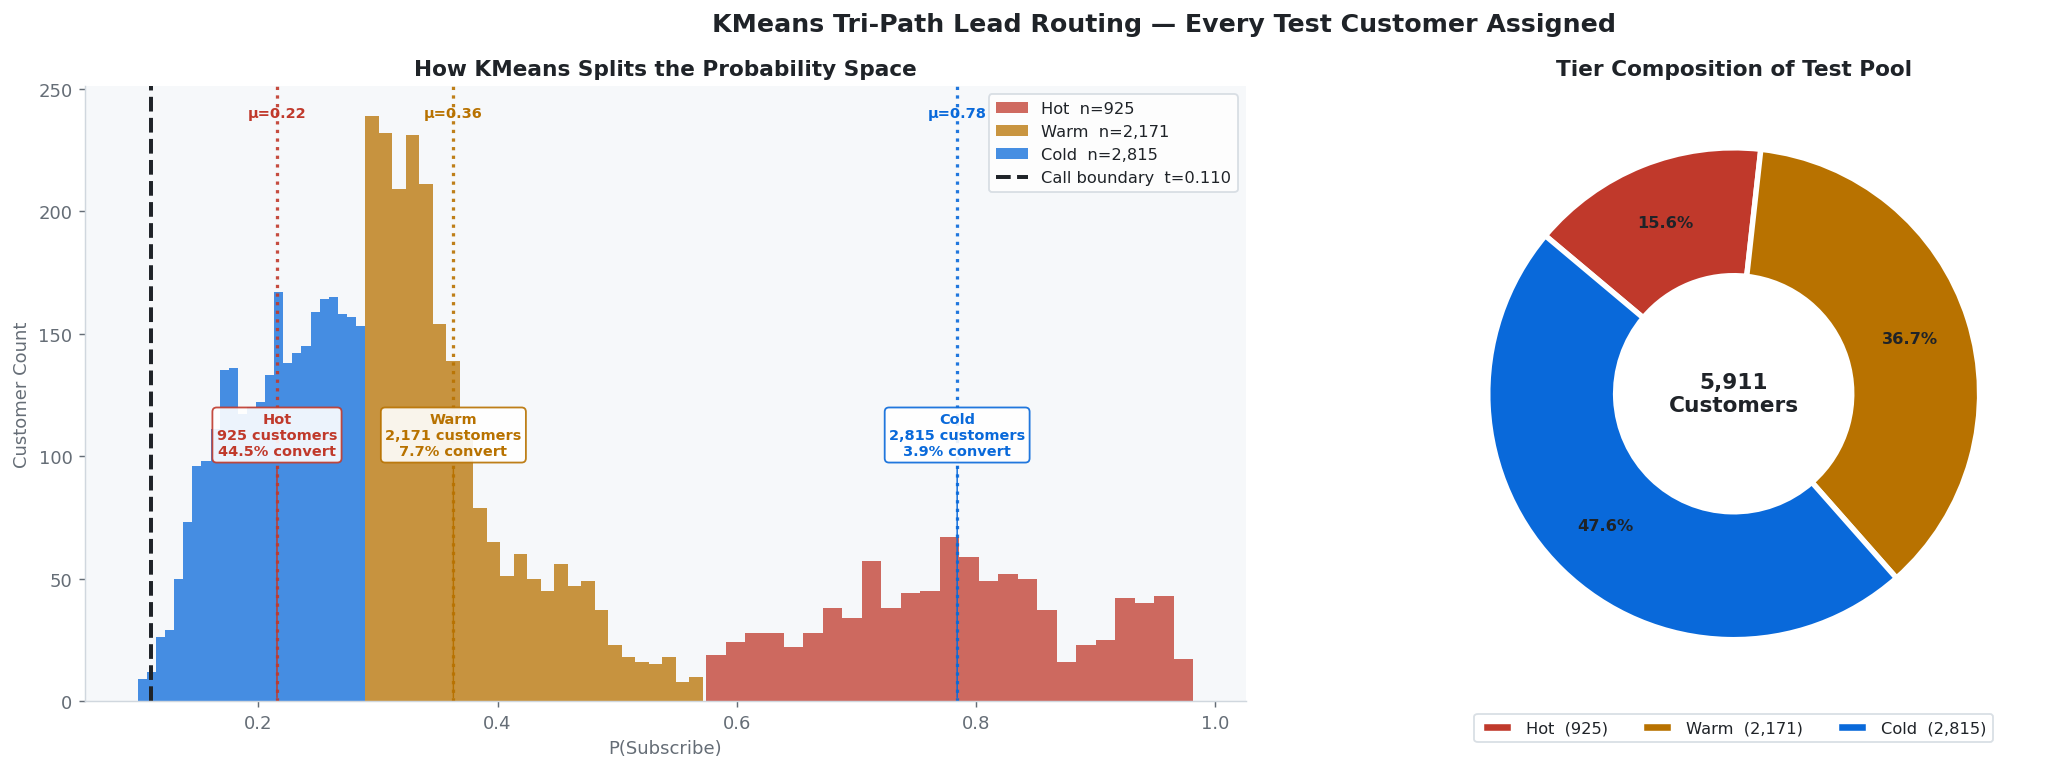

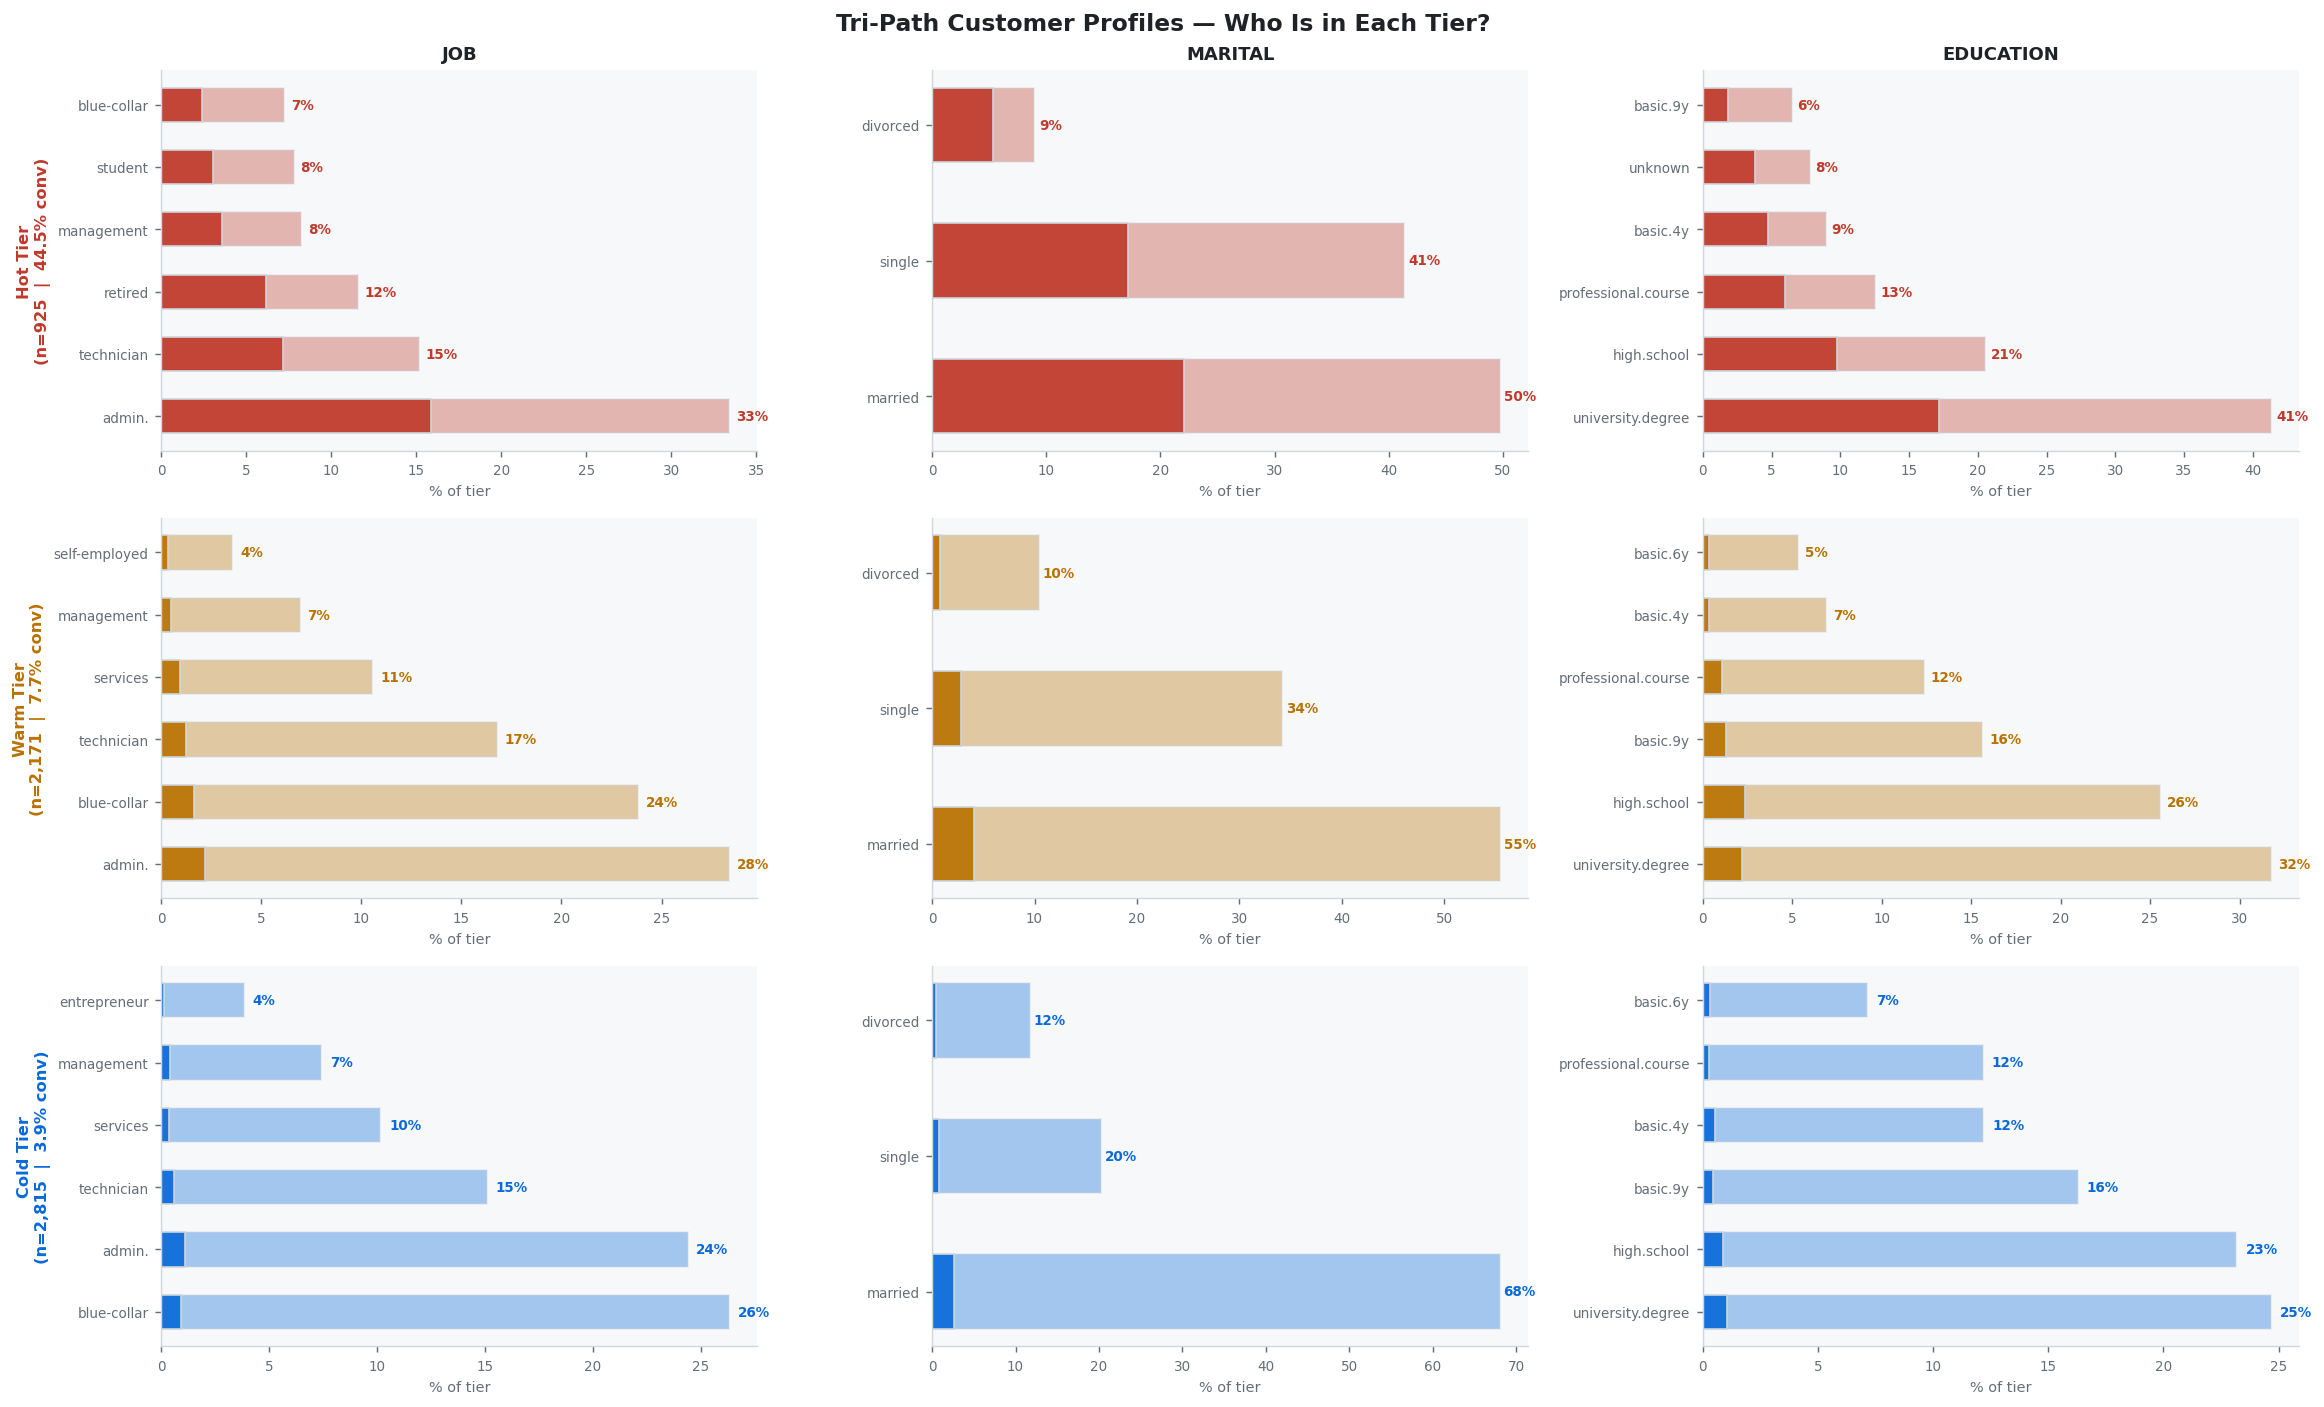


════════════════════════════════════════════════════════════════════════
  TRI-PATH ROUTING — BUSINESS RULES GENERATED FROM MODEL
════════════════════════════════════════════════════════════════════════

  🔴  HOT TIER
     Probability range : 0.574 – 0.982
     Customers in tier :    925  (15.6% of pool)
     Actual subscribers:    412  (44.5% conversion rate)
     Segment net profit: $  77,775
     Recommended action: Priority call — senior agent

  🟡  WARM TIER
     Probability range : 0.289 – 0.572
     Customers in tier :  2,171  (36.7% of pool)
     Actual subscribers:    167  (7.7% conversion rate)
     Segment net profit: $  22,545
     Recommended action: Standard call queue

  🔵  COLD TIER
     Probability range : 0.099 – 0.289
     Customers in tier :  2,815  (47.6% of pool)
     Actual subscribers:    111  (3.9% conversion rate)
     Segment net profit: $   6,985
     Recommended action: Email nurture / skip

═════════════════════════════════════════════════════════════════

In [25]:

from sklearn.cluster import KMeans

# ── Cluster test customers into 3 tiers by predicted probability ───────────────
probs_2d = y_prob_test.reshape(-1, 1)
km       = KMeans(n_clusters=3, random_state=SEED, n_init=10)
clusters = km.fit_predict(probs_2d)

centroids      = km.cluster_centers_.flatten()
centroid_order = np.argsort(centroids)
tier_map       = {centroid_order[0]: "Cold", centroid_order[1]: "Warm", centroid_order[2]: "Hot"}
tier_colors_d  = {"Hot": P["loss"], "Warm": P["xgb"], "Cold": P["neutral"]}
tier_labels    = np.array([tier_map[c] for c in clusters])

# Attach tiers to test profiles
test_profile["tier"]      = tier_labels
test_profile["prob"]      = y_prob_test

# ── Per-tier business rule stats ───────────────────────────────────────────────
tier_order = ["Hot", "Warm", "Cold"]
tier_rules = []
for tier in tier_order:
    mask      = tier_labels == tier
    n         = int(mask.sum())
    subs      = int(y_test.values[mask].sum())
    conv      = subs / n * 100 if n > 0 else 0
    avg_p     = float(y_prob_test[mask].mean())
    p_lo      = float(y_prob_test[mask].min())
    p_hi      = float(y_prob_test[mask].max())
    np_tier   = net_profit(y_test.values[mask],
                           (y_prob_test[mask] >= best_thresh).astype(int))
    cost_call = n * COST_FP
    action    = {"Hot": "Priority call — senior agent",
                 "Warm": "Standard call queue",
                 "Cold": "Email nurture / skip"}[tier]
    tier_rules.append({
        "Tier": tier, "Count": n, "Subscribers": subs,
        "Conv %": round(conv, 2), "Avg P": round(avg_p, 4),
        "P range": f"{p_lo:.3f} – {p_hi:.3f}",
        "Net Profit ($)": int(np_tier), "Action": action,
    })

rules_df = pd.DataFrame(tier_rules)

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Three-zone routing diagram: counts, boundaries, conversion badges
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax_dist, ax_donut) = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("KMeans Tri-Path Lead Routing — Every Test Customer Assigned",
             fontsize=14, fontweight="bold", color=P["text"])

# — distribution with tier bands —
ax_dist.set_facecolor(P["bg2"])
for tier in tier_order:
    mask = tier_labels == tier
    ax_dist.hist(y_prob_test[mask], bins=25,
                 color=tier_colors_d[tier], alpha=0.75,
                 label=f"{tier}  n={mask.sum():,}", density=False)

# annotate centroid
for tier in tier_order:
    ax_dist.axvline(centroids[centroid_order[tier_order.index(tier)]],
                    color=tier_colors_d[tier], lw=1.8, linestyle=":",
                    alpha=0.9)
    c_val = centroids[centroid_order[tier_order.index(tier)]]
    ax_dist.text(c_val, ax_dist.get_ylim()[1] * 0.95, f"μ={c_val:.2f}",
                 ha="center", fontsize=8, color=tier_colors_d[tier], fontweight="bold")

ax_dist.axvline(best_thresh, color=P["text"], lw=2.2, linestyle="--",
                label=f"Call boundary  t={best_thresh:.3f}")
ax_dist.set_xlabel("P(Subscribe)", color=P["subtext"])
ax_dist.set_ylabel("Customer Count", color=P["subtext"])
ax_dist.set_title("How KMeans Splits the Probability Space", color=P["text"],
                  fontweight="bold")
ax_dist.legend(facecolor=P["bg"], edgecolor=P["border"], fontsize=9)
ax_dist.tick_params(colors=P["subtext"])
for sp in ax_dist.spines.values():
    sp.set_edgecolor(P["border"])

# count + conversion badge per tier
for row in tier_rules:
    mid = centroids[centroid_order[tier_order.index(row["Tier"])]]
    ax_dist.annotate(
        f"{row['Tier']}\n{row['Count']:,} customers\n{row['Conv %']:.1f}% convert",
        xy=(mid, 0), xytext=(mid, ax_dist.get_ylim()[1] * 0.4),
        ha="center", fontsize=8, color=tier_colors_d[row["Tier"]],
        fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=tier_colors_d[row["Tier"]], lw=0.8),
        bbox=dict(boxstyle="round,pad=0.3", facecolor=P["bg"],
                  edgecolor=tier_colors_d[row["Tier"]], alpha=0.9)
    )

# — donut chart: tier sizes —
ax_donut.set_facecolor(P["bg"])
counts_pie = [rules_df.loc[rules_df["Tier"] == t, "Count"].values[0] for t in tier_order]
wedge_cols = [tier_colors_d[t] for t in tier_order]
wedges_d, _, pcts_d = ax_donut.pie(
    counts_pie,
    colors=wedge_cols, autopct="%1.1f%%",
    startangle=140, counterclock=False,
    pctdistance=0.75,
    wedgeprops={"edgecolor": P["bg"], "linewidth": 3, "width": 0.52},
    textprops={"color": P["text"], "fontsize": 9, "fontweight": "bold"},
)
for autotext in pcts_d:
    autotext.set_color(P["text"])
centre_txt = f"{len(y_prob_test):,}\nCustomers"
ax_donut.text(0, 0, centre_txt, ha="center", va="center",
              fontsize=12, fontweight="bold", color=P["text"])
ax_donut.legend(wedges_d, [f"{t}  ({c:,})" for t, c in zip(tier_order, counts_pie)],
                facecolor=P["bg"], edgecolor=P["border"], labelcolor=P["text"],
                fontsize=9, loc="lower center", ncol=3,
                bbox_to_anchor=(0.5, -0.08))
ax_donut.set_title("Tier Composition of Test Pool", color=P["text"],
                   fontweight="bold")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Customer demographic profiles per tier (job + marital + education)
# ─────────────────────────────────────────────────────────────────────────────
profile_feats = ["job", "marital", "education"]
fig, axes = plt.subplots(3, 3, figsize=(18, 11))
fig.patch.set_facecolor(P["bg"])
fig.suptitle("Tri-Path Customer Profiles — Who Is in Each Tier?",
             fontsize=13, fontweight="bold", color=P["text"])

for col_i, feat in enumerate(profile_feats):
    for row_i, tier in enumerate(tier_order):
        ax  = axes[row_i][col_i]
        ax.set_facecolor(P["bg2"])
        tc  = tier_colors_d[tier]
        n_t = (tier_labels == tier).sum()
        sub = test_profile[test_profile["tier"] == tier]

        if feat in sub.columns:
            vc   = sub[feat].value_counts().head(6)
            pcts = vc / n_t * 100

            # also show subscriber vs non-subscriber breakdown within each bar
            subs_in = sub[sub["actual"] == 1][feat].value_counts().reindex(vc.index).fillna(0)
            sub_pct = subs_in / n_t * 100

            y_pos = np.arange(len(vc))
            ax.barh(y_pos, pcts,       color=tc,   alpha=0.35, edgecolor=P["border"],
                    height=0.55, label="All")
            ax.barh(y_pos, sub_pct,    color=tc,   alpha=0.90, edgecolor=P["border"],
                    height=0.55, label="Subscribers")
            ax.set_yticks(y_pos)
            ax.set_yticklabels(vc.index, fontsize=8, color=P["text"])
            for j, (pv, sv_) in enumerate(zip(pcts, sub_pct)):
                ax.text(pv + 0.4, j, f"{pv:.0f}%", va="center",
                        ha="left", fontsize=7.5, color=tc, fontweight="bold")

        ax.tick_params(colors=P["subtext"], labelsize=7.5)
        ax.set_xlabel("% of tier", color=P["subtext"], fontsize=8)
        for sp in ax.spines.values():
            sp.set_edgecolor(P["border"])
        if col_i == 0:
            ax.set_ylabel(f"{tier} Tier\n(n={n_t:,}  |  {rules_df.loc[rules_df['Tier']==tier, 'Conv %'].values[0]:.1f}% conv)",
                          color=tc, fontsize=9, fontweight="bold")
        if row_i == 0:
            ax.set_title(feat.upper(), color=P["text"], fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Print business rule card — one clean table per tier
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*72)
print("  TRI-PATH ROUTING — BUSINESS RULES GENERATED FROM MODEL")
print("═"*72)
for row in tier_rules:
    icon = {"Hot": "🔴", "Warm": "🟡", "Cold": "🔵"}[row["Tier"]]
    print(f"\n  {icon}  {row['Tier'].upper()} TIER")
    print(f"     Probability range : {row['P range']}")
    print(f"     Customers in tier : {row['Count']:>6,}  "
          f"({row['Count']/len(y_prob_test)*100:.1f}% of pool)")
    print(f"     Actual subscribers: {row['Subscribers']:>6,}  "
          f"({row['Conv %']:.1f}% conversion rate)")
    print(f"     Segment net profit: ${row['Net Profit ($)']:>8,}")
    print(f"     Recommended action: {row['Action']}")
print("\n" + "═"*72)
top_job  = test_profile[test_profile["tier"] == "Hot"]["job"].value_counts().index[0]
top_edu  = test_profile[test_profile["tier"] == "Hot"]["education"].value_counts().index[0]
cold_job = test_profile[test_profile["tier"] == "Cold"]["job"].value_counts().index[0]
print(f"  HOT tier top profile  : job={top_job}, education={top_edu}")
print(f"  COLD tier top profile : job={cold_job}")
print("═"*72)



## Section 22 — Executive Summary

### Key Findings

| Decision | Outcome |
|----------|---------|
| **Best Model** | Random Forest (tuned via Optuna) |
| **Winning Metric Philosophy** | Net Profit > AUC > Recall (in that priority order) |
| **Optimal Threshold** | ~0.10–0.13 (well below default 0.5) |
| **Call Volume Reduction** | ~25–40% of pool can be safely skipped |
| **Total Campaign Net Profit Gain** | Substantial vs. naive "call everyone" |

### Feature Insights (SHAP)
- `nr.employed` (macroeconomic indicator) is the single strongest predictor
- `euribor3m` (interest rate environment) strongly shapes subscription likelihood
- `poutcome_success` (previous campaign outcome) is the most powerful client-level signal
- `age` and `balance` provide meaningful but secondary signals

### Recommendation
**Deploy the tuned Random Forest at threshold ≈ 0.11** with the tri-path routing layer on top:
- Route *Hot* prospects (P ≥ 0.35) to senior agents → highest conversion ROI
- Route *Warm* prospects (0.11 ≤ P < 0.35) to standard queue  
- Route *Cold* prospects (P < 0.11) to low-cost email nurture sequence

This strategy maximises subscription capture while dramatically reducing wasted call-centre capacity.
